# DATA PREPROCESSING

In this code we will fetch the missing datas about the stock like importing the Sectors and Industry of the stock they are trading, buy and sell time and date. Preprocess the data, perform Data Cleaning, perform Exploratory Data Analysis and at last will do Feature Engineering to find the hidden patterns and trends in the data.

Now we will import the necessary libaries.

In [ ]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime  
from datetime import time 
import yfinance as yf
import textwrap
import statsmodels

In [760]:
from pathlib import Path
import re

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PLOT_COUNTER = {"value": 0}

PLOT_FILENAME_MAP = {
    "Distribution of the Features": "Distribution of the Features",
    "Count Plot of Features": "Count Plot of Features",
    "Distribution of B and S Times (30 Mins)": "Distribution of B and S Times (30 Mins)",
    "Distribution of B and S Times (Months-Year)": "Distribution of B and S Times (Months-Year)",
    "Pair Plot of the Features": "Pair Plot of the Features",
    "Correlation Heatmap of the Features": "Correlation Heatmap of the Features",
    "Avg Realised PnL by Remarks": "Avg Realised PnL by Remarks",
    "Avg Realised PnL by B and S Times": "Avg Realised PnL by B and S Times",
    "Avg Realised PnL by Symbols": "Avg Realised PnL by Symbols",
    "Avg and Total Realised PnL by Sectors": "Avg and Total Realised PnL by Sectors",
    "Avg and Total Realised PnL by Industries": "Avg and Total Realised PnL by Industries",
    "Average Realised P&L by Buy Month": "Average Realised P&L by Buy Month",
    "Average Realised P&L by Buy Day of Week": "Average Realised P&L by Buy Day of Week",
    "Average Realised P&L by Sell Month": "Average Realised P&L by Sell Month",
    "Average Realised P&L by Sell Day of Week": "Average Realised P&L by Sell Day of Week",
    "Average Realised P&L by Buy Interval": "Average Realised P&L by Buy Interval",
    "Average Realised P&L by Sell Interval": "Average Realised P&L by Sell Interval",
    "Average Realised P&L by Buy Month-Year": "Average Realised P&L by Buy Month-Year",
    "Average Realised P&L by Sell Month-Year": "Average Realised P&L by Sell Month-Year",
    "Relationship between Buy Month and Sell Month": "Relationship between Buy Month and Sell Month",
    "Relationship between Buy Month and Sector": "Relationship between Buy Month and Sector",
    "Relationship between Sell Month and Sector": "Relationship between Sell Month and Sector",
    "Relationship between Remark and Sector": "Relationship between Remark and Sector",
    "Relationship between Remark and Industry": "Relationship between Remark and Industry",
    "Relationship between Buy Month and Remark": "Relationship between Buy Month and Remark",
    "Relationship between Sell Month and Remark": "Relationship between Sell Month and Remark",
    "Actual vs Predicted Model Comparison": "Actual vs Predicted Model Comparison",
    "Feature Importance - Gradient Boosting": "Feature Importance - Gradient Boosting",
    "SHAP Feature Importance": "SHAP Feature Importance",
    "SHAP Impact Distribution": "SHAP Impact Distribution",
    "SHAP Dependence Plots": "SHAP Dependence Plots",
    "SHAP Prediction Breakdown": "SHAP Prediction Breakdown",
}

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.facecolor": "#f8fafc",
    "axes.facecolor": "#ffffff",
    "axes.edgecolor": "#d9e2ec",
    "axes.labelcolor": "#243b53",
    "axes.titlecolor": "#102a43",
    "axes.titleweight": "bold",
    "grid.color": "#cbd5e1",
    "grid.alpha": 0.32,
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "savefig.facecolor": "#ffffff",
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def reset_plot_counter(start=0, clean_existing=False):
    PLOT_COUNTER["value"] = start
    if clean_existing:
        for old_file in FIGURES_DIR.glob('[0-9][0-9]_*.png'):
            old_file.unlink(missing_ok=True)


def _clean_plot_title(title, max_length=120):
    clean = re.sub(r'[<>:"/\|?*]+', '', str(title)).strip()
    clean = re.sub(r'\s+', ' ', clean)
    return clean[:max_length] or "Plot"


def save_plot(title, fig=None, close=False):
    fig = fig or plt.gcf()
    PLOT_COUNTER["value"] += 1
    file_title = PLOT_FILENAME_MAP.get(title, _clean_plot_title(title))
    file_path = FIGURES_DIR / f"{PLOT_COUNTER['value']:02d}_{file_title}.png"
    fig.savefig(file_path, facecolor="white", bbox_inches="tight", dpi=300)
    print(f"Saved plot: {file_path}")
    if close:
        plt.close(fig)
    return file_path


def polish_axes(ax, rotate_x=0, rotate_y=0):
    ax.tick_params(axis="x", rotation=rotate_x)
    ax.tick_params(axis="y", rotation=rotate_y)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)


reset_plot_counter(clean_existing=True)


Now we will load the Dataset to Preprocess.

In [761]:
def load_clean_excel(file_path, start_keywords=['Stock name'], end_keywords=['Unrealised trades', 'Disclaimer']):
    # Preview file to find header and footer
    preview = pd.read_excel(file_path, header=None)
    
    # Find where the actual table starts
    start_mask = preview.apply(lambda row: row.astype(str).str.contains('|'.join(start_keywords), case=False, na=False)).any(axis=1)
    start_index = start_mask[start_mask].index.min()
    
    # Find where table ends
    end_mask = preview.apply(lambda row: row.astype(str).str.contains('|'.join(end_keywords), case=False, na=False)).any(axis=1)
    end_index = end_mask[end_mask].index.min() if end_mask.any() else len(preview)
    
    print(f"{file_path}")
    print(f"Data starts at row {start_index}, ends before row {end_index}")
    
    # Read only the relevant data rows
    df = pd.read_excel(file_path, header=start_index, nrows=end_index - start_index - 1)
    
    # Clean column names
    df.columns = (df.columns
                  .astype(str)
                  .str.strip()
                  .str.replace('\u00A0', ' ', regex=True)
                  .str.replace('\s+', ' ', regex=True))
    
    # Drop empty rows/columns
    df.dropna(how='all', inplace=True)
    df.dropna(axis=1, how='all', inplace=True)
    
    print(f" Clean Data Loaded — Shape: {df.shape}\n")
    return df

# Step 1: File Paths
# ---- Harsh ----
pnl_path = "Stocks_PnL_3788142010_01-08-2021_02-04-2026_report.xlsx"
order_path = "Stocks_Order_History_3788142010_2021-08-01_2026-04-02.xlsx"

# Step 2: Load both files dynamically
pnl = load_clean_excel(pnl_path)
order_history = load_clean_excel(order_path)

# Step 3: Verify loaded datasets
print("PnL Columns:", pnl.columns.tolist())
print("Order History Columns:", order_history.columns.tolist())

# Optional — display samples
print("\nPnL Preview:")
print(pnl.head(3))

print("\nOrder History Preview:")
print(order_history.head(3))


Stocks_PnL_3788142010_01-08-2021_02-04-2026_report.xlsx
Data starts at row 25, ends before row 253
 Clean Data Loaded — Shape: (226, 11)

Stocks_Order_History_3788142010_2021-08-01_2026-04-02.xlsx
Data starts at row 5, ends before row 407
 Clean Data Loaded — Shape: (401, 10)

PnL Columns: ['Stock name', 'ISIN', 'Quantity', 'Buy date', 'Buy price', 'Buy value', 'Sell date', 'Sell price', 'Sell value', 'Realised P&L', 'Remark']
Order History Columns: ['Stock name', 'Symbol', 'ISIN', 'Type', 'Quantity', 'Value', 'Exchange', 'Exchange Order Id', 'Execution date and time', 'Order status']

PnL Preview:
                  Stock name          ISIN  Quantity    Buy date  Buy price  \
0  ONE 97 COMMUNICATIONS LTD  INE982J01020         1  25-11-2021    1833.55   
1        INDIAN OIL CORP LTD  INE242A01010        10  30-05-2022     114.40   
2             COAL INDIA LTD  INE522F01014         1  02-06-2022     195.50   

   Buy value   Sell date  Sell price  Sell value  Realised P&L          Remar

c:\Users\kejri\.conda\envs\ML_venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\kejri\.conda\envs\ML_venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\kejri\.conda\envs\ML_venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\kejri\.conda\envs\ML_venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Now let's find some information about the data

In [762]:
pnl.info()
pnl.shape
pnl.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Stock name    226 non-null    object 
 1   ISIN          226 non-null    object 
 2   Quantity      226 non-null    int64  
 3   Buy date      226 non-null    object 
 4   Buy price     226 non-null    float64
 5   Buy value     226 non-null    float64
 6   Sell date     226 non-null    object 
 7   Sell price    226 non-null    float64
 8   Sell value    226 non-null    float64
 9   Realised P&L  226 non-null    float64
 10  Remark        155 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 19.5+ KB


,Quantity,Buy price,Buy value,Sell price,Sell value,Realised P&L
count,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000
mean,13.517699,872.998761,6493.935664,875.259646,6675.499558,181.563894
std,41.579933,896.049754,6800.594830,866.833666,6971.263749,1057.544001
min,1.000000,0.000000,0.000000,27.640000,72.600000,-2329.400000
25%,4.000000,195.750000,1447.140000,193.835000,1431.125000,-44.250000
50%,9.000000,643.975000,4212.750000,648.780000,4405.700000,-0.630000
75%,10.000000,1399.225000,9745.375000,1414.367500,10049.812500,51.475000
max,600.000000,5466.000000,32465.000000,5085.250000,32439.000000,10800.000000


similarly for the Order's history

In [763]:
order_history.info()
order_history.shape
order_history.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Stock name               401 non-null    object 
 1   Symbol                   401 non-null    object 
 2   ISIN                     401 non-null    object 
 3   Type                     401 non-null    object 
 4   Quantity                 401 non-null    int64  
 5   Value                    401 non-null    float64
 6   Exchange                 401 non-null    object 
 7   Exchange Order Id        401 non-null    int64  
 8   Execution date and time  401 non-null    object 
 9   Order status             401 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 31.5+ KB


,Quantity,Value,Exchange Order Id
count,401.000000,401.000000,4.010000e+02
mean,15.274314,7423.167431,4.414023e+16
std,44.440011,7523.814707,2.695581e+17
min,1.000000,0.700000,8.247315e+06
25%,4.000000,1699.800000,1.000000e+15
50%,10.000000,5004.450000,1.100000e+15
75%,13.000000,11813.400000,1.200000e+15
max,600.000000,44490.000000,1.763016e+18


Now Let's see how the data looks 

In [764]:
pnl.head()
pnl.sample(5)

,Stock name,ISIN,Quantity,Buy date,Buy price,Buy value,Sell date,Sell price,Sell value,Realised P&L,Remark
32,OIL AND NATURAL GAS CORP.,INE213A01029,5,06-07-2022,121.00,605.0,18-05-2023,167.30,836.50,231.50,NaN
101,ICICI SECURITIES LIMITED,INE763G01038,10,22-11-2023,679.97,6799.7,22-11-2023,674.92,6749.20,-50.50,Intraday trade
126,INDUSIND BANK LIMITED,INE095A01012,15,09-02-2024,1483.00,22245.0,09-02-2024,1475.05,22125.75,-119.25,Intraday trade
177,RELIANCE INDUSTRIES LTD,INE002A01018,10,26-04-2024,2917.25,29172.5,26-04-2024,2912.50,29125.00,-47.50,Intraday trade
24,STEEL AUTHORITY OF INDIA,INE114A01011,5,21-06-2022,69.20,346.0,05-08-2022,77.55,387.75,41.75,NaN


Similarly for the Order history

In [765]:
order_history.head()
order_history.sample(5)

,Stock name,Symbol,ISIN,Type,Quantity,Value,Exchange,Exchange Order Id,Execution date and time,Order status
237,RELIANCE INDUSTRIES LTD,RELIANCE,INE002A01018,BUY,10,29630.0,NSE,1300000011233513,27-02-2024 10:19 AM,Executed
281,RELIANCE INDUSTRIES LTD,RELIANCE,INE002A01018,SELL,4,11805.2,NSE,1300000023988090,22-04-2024 12:11 PM,Executed
91,COAL INDIA LTD,COALINDIA,INE522F01014,SELL,15,3225.0,NSE,1000000014618417,08-08-2022 01:54 PM,Executed
371,NTPC LTD,NTPC,INE733E01010,BUY,5,2148.5,NSE,1200000020276414,23-09-2024 10:42 AM,Executed
279,RELIANCE INDUSTRIES LTD,RELIANCE,INE002A01018,SELL,2,5866.8,NSE,1300000031915508,19-04-2024 12:45 PM,Executed


Let's check for the missing values and the duplicated values

In [766]:
pnl.isnull().sum()

Stock name       0
ISIN             0
Quantity         0
Buy date         0
Buy price        0
Buy value        0
Sell date        0
Sell price       0
Sell value       0
Realised P&L     0
Remark          71
dtype: int64

In [767]:
pnl.duplicated().sum()

np.int64(1)

Similarly for the order history

In [768]:
order_history.isnull().sum()

Stock name                 0
Symbol                     0
ISIN                       0
Type                       0
Quantity                   0
Value                      0
Exchange                   0
Exchange Order Id          0
Execution date and time    0
Order status               0
dtype: int64

In [769]:
order_history.duplicated().sum()

np.int64(0)

# Data Fetching

Now lets fetch the execution date and time for both the buy and sell orders from the order history to the pnl to do the further preprocesses and find the time-based analysis. 

In [770]:
# Ensure datetime column exists and is clean
order_history.columns = order_history.columns.str.strip().str.replace('\u00A0', ' ', regex=True)
order_history['Execution date and time'] = pd.to_datetime(order_history['Execution date and time'], errors='coerce')

# Split date and time safely
order_history['Execution Date'] = order_history['Execution date and time'].dt.date
order_history['Execution Time'] = order_history['Execution date and time'].dt.time

# ---------- Step 3: Clean and convert buy/sell dates safely ----------
pnl['Buy date'] = pd.to_datetime(pnl['Buy date'], errors='coerce').dt.date
pnl['Sell date'] = pd.to_datetime(pnl['Sell date'], errors='coerce').dt.date

# Drop any rows where dates failed to parse
pnl = pnl.dropna(subset=['Buy date', 'Sell date'])

# ---------- Step 4: Define market hours helper ----------
def is_market_time(dt):
    if pd.notna(dt):
        time = dt.time()
        return (time >= pd.Timestamp('09:15:00').time()) and (time <= pd.Timestamp('15:30:00').time())
    return False

# ---------- Step 5: Function to get times from order history ----------
def get_times_from_order_history(pnl_row, order_df):
    stock_name = pnl_row['Stock name']
    isin = pnl_row['ISIN']
    buy_date = pnl_row['Buy date']
    sell_date = pnl_row['Sell date']
    
    stock_orders = order_df[
        (order_df['Stock name'] == stock_name) &
        (order_df['ISIN'] == isin)
    ].copy()
    
    # Case 1: Intraday (same date)
    if buy_date == sell_date:
        buy_order = stock_orders[
            (stock_orders['Execution date and time'].dt.date == buy_date) &
            (stock_orders['Type'].str.upper() == 'BUY') &
            (stock_orders['Execution date and time'].apply(is_market_time))
        ].sort_values('Execution date and time').head(1)
        
        sell_order = stock_orders[
            (stock_orders['Execution date and time'].dt.date == sell_date) &
            (stock_orders['Type'].str.upper() == 'SELL') &
            (stock_orders['Execution date and time'].apply(is_market_time))
        ].sort_values('Execution date and time').tail(1)
    
    # Case 2: Delivery
    else:
        buy_order = stock_orders[
            (stock_orders['Execution date and time'].dt.date == buy_date) &
            (stock_orders['Type'].str.upper() == 'BUY') &
            (stock_orders['Execution date and time'].apply(is_market_time))
        ].sort_values('Execution date and time').head(1)
        
        sell_order = stock_orders[
            (stock_orders['Execution date and time'].dt.date == sell_date) &
            (stock_orders['Type'].str.upper() == 'SELL') &
            (stock_orders['Execution date and time'].apply(is_market_time))
        ].sort_values('Execution date and time').tail(1)
    
    # Extract times or set defaults
    buy_time = buy_order['Execution date and time'].iloc[0].time() if not buy_order.empty else pd.Timestamp('09:15:00').time()
    sell_time = sell_order['Execution date and time'].iloc[0].time() if not sell_order.empty else pd.Timestamp('15:30:00').time()
    
    return buy_time, sell_time

# ---------- Step 6: Apply function ----------
pnl[['Buy Time', 'Sell Time']] = pnl.apply(
    lambda row: pd.Series(get_times_from_order_history(row, order_history)), axis=1
)

print("Buy/Sell times added successfully!")
print(pnl[['Stock name', 'Buy date', 'Buy Time', 'Sell date', 'Sell Time']].head(20))


C:\Users\kejri\AppData\Local\Temp\ipykernel_23256\1051223471.py:3: UserWarning: Parsing dates in %d-%m-%Y %I:%M %p format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  order_history['Execution date and time'] = pd.to_datetime(order_history['Execution date and time'], errors='coerce')
C:\Users\kejri\AppData\Local\Temp\ipykernel_23256\1051223471.py:10: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pnl['Buy date'] = pd.to_datetime(pnl['Buy date'], errors='coerce').dt.date
C:\Users\kejri\AppData\Local\Temp\ipykernel_23256\1051223471.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pnl['Sell date'] = pd.to_datetime(pnl['Sell date'], errors='coerce').dt.date


Buy/Sell times added successfully!
                   Stock name    Buy date  Buy Time   Sell date Sell Time
0   ONE 97 COMMUNICATIONS LTD  2021-11-25  09:23:00  2021-11-25  09:27:00
1         INDIAN OIL CORP LTD  2022-05-30  10:29:00  2023-05-18  11:48:00
2              COAL INDIA LTD  2022-06-02  09:34:00  2022-08-08  13:54:00
3             ETERNAL LIMITED  2022-06-03  13:12:00  2022-06-03  13:07:00
4              COAL INDIA LTD  2022-06-03  10:32:00  2022-08-08  13:54:00
5       INDUSIND BANK LIMITED  2022-06-08  10:13:00  2022-08-05  15:23:00
6              COAL INDIA LTD  2022-06-09  15:11:00  2022-06-09  10:24:00
7       INDUSIND BANK LIMITED  2022-06-14  10:34:00  2022-06-14  10:41:00
8       INDUSIND BANK LIMITED  2022-06-14  10:34:00  2022-06-14  10:41:00
9              COAL INDIA LTD  2022-06-14  09:17:00  2022-06-14  10:51:00
10             COAL INDIA LTD  2022-06-14  09:17:00  2022-06-14  10:51:00
11             COAL INDIA LTD  2022-06-14  09:17:00  2022-06-14  10:51:00
12 

Similarly, now let's fetch the sectors and industry for each of the trades to find the sector-based and industry-based trends and patterns in the user trade history 

In [771]:
# Create symbol mapping from order history (Symbol to Stock name)
symbol_to_name = dict(zip(order_history['Symbol'], order_history['Stock name']))
name_to_symbol = {v: k for k, v in symbol_to_name.items()}

# Get unique symbols from order history
unique_symbols = order_history['Symbol'].unique()

# Fetch sector data
sector_data = {}
for symbol in unique_symbols:
    try:
        ticker = yf.Ticker(f"{symbol}.NS")
        info = ticker.info
        sector_data[symbol] = (
            info.get('sector', 'Unknown'),
            info.get('industry', 'Unknown')
        )
    except Exception as e:
        print(f"Error fetching {symbol}: {str(e)}")
        sector_data[symbol] = ('Unknown', 'Unknown')

# Add to order history
order_history['Sector'] = order_history['Symbol'].map(lambda x: sector_data.get(x, ('Unknown', 'Unknown'))[0])
order_history['Industry'] = order_history['Symbol'].map(lambda x: sector_data.get(x, ('Unknown', 'Unknown'))[1])

# Add to PnL - first extract symbol from stock name
pnl['Symbol'] = pnl['Stock name'].map(name_to_symbol)
pnl['Sector'] = pnl['Symbol'].map(lambda x: sector_data.get(x, ('Unknown', 'Unknown'))[0])
pnl['Industry'] = pnl['Symbol'].map(lambda x: sector_data.get(x, ('Unknown', 'Unknown'))[1])

print("Sector and Industry data added successfully!")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ISEC.NS"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: STANCAP$.NS"}}}


Sector and Industry data added successfully!


Since we imported the necessary Timing and Sectorial datas for the trades, now we will be moving towards the Data Cleaning part and afterwards we will apply some EDA techniques to find some hidden patterns.  

# Data Cleaning

In [772]:
#Let's check the information of the datasets again
pnl.info()
pnl.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Stock name    226 non-null    object 
 1   ISIN          226 non-null    object 
 2   Quantity      226 non-null    int64  
 3   Buy date      226 non-null    object 
 4   Buy price     226 non-null    float64
 5   Buy value     226 non-null    float64
 6   Sell date     226 non-null    object 
 7   Sell price    226 non-null    float64
 8   Sell value    226 non-null    float64
 9   Realised P&L  226 non-null    float64
 10  Remark        155 non-null    object 
 11  Buy Time      226 non-null    object 
 12  Sell Time     226 non-null    object 
 13  Symbol        226 non-null    object 
 14  Sector        226 non-null    object 
 15  Industry      226 non-null    object 
dtypes: float64(5), int64(1), object(10)
memory usage: 28.4+ KB


(226, 16)

Since Remarks have so many missing values, lets fill them

In [773]:
pnl['Remark'].value_counts()

Remark
Intraday trade                  144
New shares credit from IPO        9
New shares credit from Bonus      2
Name: count, dtype: int64

In [774]:
pnl['Remark'] = pnl['Remark'].fillna('Delivery Trade')
pnl['Remark'].value_counts()

Remark
Intraday trade                  144
Delivery Trade                   71
New shares credit from IPO        9
New shares credit from Bonus      2
Name: count, dtype: int64

Since we have duplicate values, let's deal with them

In [775]:
pnl = pnl.drop_duplicates()
pnl.duplicated().sum()
pnl.shape

(225, 16)

Let's handle the missing Sector and Industry names.

In [776]:
pnl['Sector'].to_list()
pnl['Sector'] = pnl['Sector'].replace(['Unknown', ''], 'Others')

In [777]:
pnl['Industry'].to_list()
pnl['Industry'] = pnl['Industry'].replace(['Unknown', ''], 'Others')

Lets remove the Stocks from the IPO and Bonus 

In [778]:
pnl = pnl[~pnl['Remark'].isin([
    "New shares credit from IPO",
    "New shares credit from Bonus"])]

# Exploratory Data Analysis

In [779]:
pnl.info()
pnl.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 224
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Stock name    214 non-null    object 
 1   ISIN          214 non-null    object 
 2   Quantity      214 non-null    int64  
 3   Buy date      214 non-null    object 
 4   Buy price     214 non-null    float64
 5   Buy value     214 non-null    float64
 6   Sell date     214 non-null    object 
 7   Sell price    214 non-null    float64
 8   Sell value    214 non-null    float64
 9   Realised P&L  214 non-null    float64
 10  Remark        214 non-null    object 
 11  Buy Time      214 non-null    object 
 12  Sell Time     214 non-null    object 
 13  Symbol        214 non-null    object 
 14  Sector        214 non-null    object 
 15  Industry      214 non-null    object 
dtypes: float64(5), int64(1), object(10)
memory usage: 28.4+ KB


,Quantity,Buy price,Buy value,Sell price,Sell value,Realised P&L
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,9.313084,908.894252,6305.336262,900.747944,6325.703505,20.367243
std,10.245352,905.347000,6782.497484,876.330921,6761.420878,392.429722
min,1.000000,25.750000,72.450000,27.640000,72.600000,-2329.400000
25%,4.000000,201.350000,1447.140000,200.262500,1422.212500,-49.750000
50%,7.500000,651.305000,4168.290000,658.250000,4083.600000,-2.275000
75%,10.000000,1410.362500,9161.425000,1416.787500,9535.575000,29.250000
max,98.000000,5466.000000,32465.000000,5085.250000,32439.000000,2970.000000


Before Proceedings we will find the Buy Hour, Buy Month, Buy Year, and similarly will find for the Selling.

In [780]:
pnl['Buy date'] = pd.to_datetime(pnl['Buy date'])
pnl['Sell date'] = pd.to_datetime(pnl['Sell date'])

pnl['Buy Year'] = pnl['Buy date'].dt.year.astype('int64')
pnl['Buy Month'] = pnl['Buy date'].dt.strftime('%b').astype('object')
pnl['Buy Day'] = pnl['Buy date'].dt.day.astype('int64')
pnl['Buy Day of Week'] = pnl['Buy date'].dt.strftime('%A').astype('object')

pnl['Sell Year'] = pnl['Sell date'].dt.year.astype('int64')
pnl['Sell Month'] = pnl['Sell date'].dt.strftime('%b').astype('object')
pnl['Sell Day'] = pnl['Sell date'].dt.day.astype('int64')
pnl['Sell Day of Week'] = pnl['Sell date'].dt.strftime('%A').astype('object')

if 'Buy Time' in pnl.columns:
    pnl['Buy Time'] = pd.to_datetime(pnl['Buy Time'], format='%H:%M:%S', errors='coerce')
    pnl['Buy Hour'] = pnl['Buy Time'].dt.hour.astype('int64')
    
    pnl['Buy Interval'] = pnl['Buy Time'].apply(lambda x: 
        f"{x.hour:02d}:{(x.minute // 30) * 30:02d}-{x.hour if (x.minute // 30) * 30 + 30 < 60 else x.hour + 1:02d}:{(x.minute // 30) * 30 + 30 if (x.minute // 30) * 30 + 30 < 60 else 0:02d}"
        if pd.notna(x) else None
    )
    
    pnl['Buy Time'] = pnl['Buy Time'].dt.time

if 'Sell Time' in pnl.columns:
    pnl['Sell Time'] = pd.to_datetime(pnl['Sell Time'], format='%H:%M:%S', errors='coerce')
    pnl['Sell Hour'] = pnl['Sell Time'].dt.hour.astype('int64')
    
    pnl['Sell Interval'] = pnl['Sell Time'].apply(lambda x: 
        f"{x.hour:02d}:{(x.minute // 30) * 30:02d}-{x.hour if (x.minute // 30) * 30 + 30 < 60 else x.hour + 1:02d}:{(x.minute // 30) * 30 + 30 if (x.minute // 30) * 30 + 30 < 60 else 0:02d}"
        if pd.notna(x) else None
    )
    
    pnl['Sell Time'] = pnl['Sell Time'].dt.time

if 'Buy Interval' in pnl.columns:
    pnl['Buy Interval'] = pnl['Buy Interval'].replace('15:30-16:00', '15:00-15:30')
    pnl['Buy Interval'] = pnl['Buy Interval'].fillna('09:00-10:00')
    pnl['Buy Interval'] = pnl['Buy Interval'].astype('object')

if 'Sell Interval' in pnl.columns:
    pnl['Sell Interval'] = pnl['Sell Interval'].replace('15:30-16:00', '15:00-15:30')
    pnl['Sell Interval'] = pnl['Sell Interval'].fillna('15:00-15:30')
    pnl['Sell Interval'] = pnl['Sell Interval'].astype('object')

pnl['Buy date'] = pd.to_datetime(pnl['Buy date']).dt.date
pnl['Sell date'] = pd.to_datetime(pnl['Sell date']).dt.date

# Convert Buy Time and Sell Time to numerical format while preserving all information
# Convert to minutes from market open (09:00:00)
pnl['Buy Time Minutes'] = pd.to_datetime(pnl['Buy Time'], format='%H:%M:%S').apply(
    lambda x: (x.hour * 60 + x.minute) if pd.notna(x) else None
).astype('float64')

pnl['Sell Time Minutes'] = pd.to_datetime(pnl['Sell Time'], format='%H:%M:%S').apply(
    lambda x: (x.hour * 60 + x.minute) if pd.notna(x) else None
).astype('float64')

# Convert Buy Hour and Sell Hour to decimal format (preserves minutes)
pnl['Buy Hour Decimal'] = pd.to_datetime(pnl['Buy Time'], format='%H:%M:%S').apply(
    lambda x: (x.hour + x.minute/60) if pd.notna(x) else None
).astype('float64')

pnl['Sell Hour Decimal'] = pd.to_datetime(pnl['Sell Time'], format='%H:%M:%S').apply(
    lambda x: (x.hour + x.minute/60) if pd.notna(x) else None
).astype('float64')

# Verify
print(pnl[['Buy Time', 'Buy Hour', 'Buy Hour Decimal', 'Buy Interval']].head(10))

# Verify conversion
print("Buy Time format conversions:")
print(pnl[['Buy Time', 'Buy Time Minutes']].head())
print("\nSell Time format conversions:")
print(pnl[['Sell Time', 'Sell Time Minutes']].head())

print("="*80)
print("DATA QUALITY CHECK")
print("="*80)
print("\nMISSING VALUES:")
print("-"*80)
missing_data = pnl.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values found!")

print("\n" + "="*80)
print("DUPLICATE ROWS:")
print("-"*80)
duplicates = pnl.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nDuplicate row indices:")
    print(pnl[pnl.duplicated(keep=False)].index.tolist())

print("\n" + "="*80)
print("DATA TYPES:")
print("-"*80)
print(pnl.dtypes)

   Buy Time  Buy Hour  Buy Hour Decimal Buy Interval
0  09:23:00         9          9.383333  09:00-09:30
1  10:29:00        10         10.483333  10:00-10:30
2  09:34:00         9          9.566667  09:30-10:00
3  13:12:00        13         13.200000  13:00-13:30
4  10:32:00        10         10.533333  10:30-11:00
5  10:13:00        10         10.216667  10:00-10:30
6  15:11:00        15         15.183333  15:00-15:30
7  10:34:00        10         10.566667  10:30-11:00
8  10:34:00        10         10.566667  10:30-11:00
9  09:17:00         9          9.283333  09:00-09:30
Buy Time format conversions:
   Buy Time  Buy Time Minutes
0  09:23:00             563.0
1  10:29:00             629.0
2  09:34:00             574.0
3  13:12:00             792.0
4  10:32:00             632.0

Sell Time format conversions:
  Sell Time  Sell Time Minutes
0  09:27:00              567.0
1  11:48:00              708.0
2  13:54:00              834.0
3  13:07:00              787.0
4  13:54:00           

In [781]:
pnl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 224
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Stock name         214 non-null    object 
 1   ISIN               214 non-null    object 
 2   Quantity           214 non-null    int64  
 3   Buy date           214 non-null    object 
 4   Buy price          214 non-null    float64
 5   Buy value          214 non-null    float64
 6   Sell date          214 non-null    object 
 7   Sell price         214 non-null    float64
 8   Sell value         214 non-null    float64
 9   Realised P&L       214 non-null    float64
 10  Remark             214 non-null    object 
 11  Buy Time           214 non-null    object 
 12  Sell Time          214 non-null    object 
 13  Symbol             214 non-null    object 
 14  Sector             214 non-null    object 
 15  Industry           214 non-null    object 
 16  Buy Year           214 non-null

1. Univariate Analysis

Let's do the Univariate Analysis for the numerical features

Saved plot: Figures\01_Distribution of the Features.png


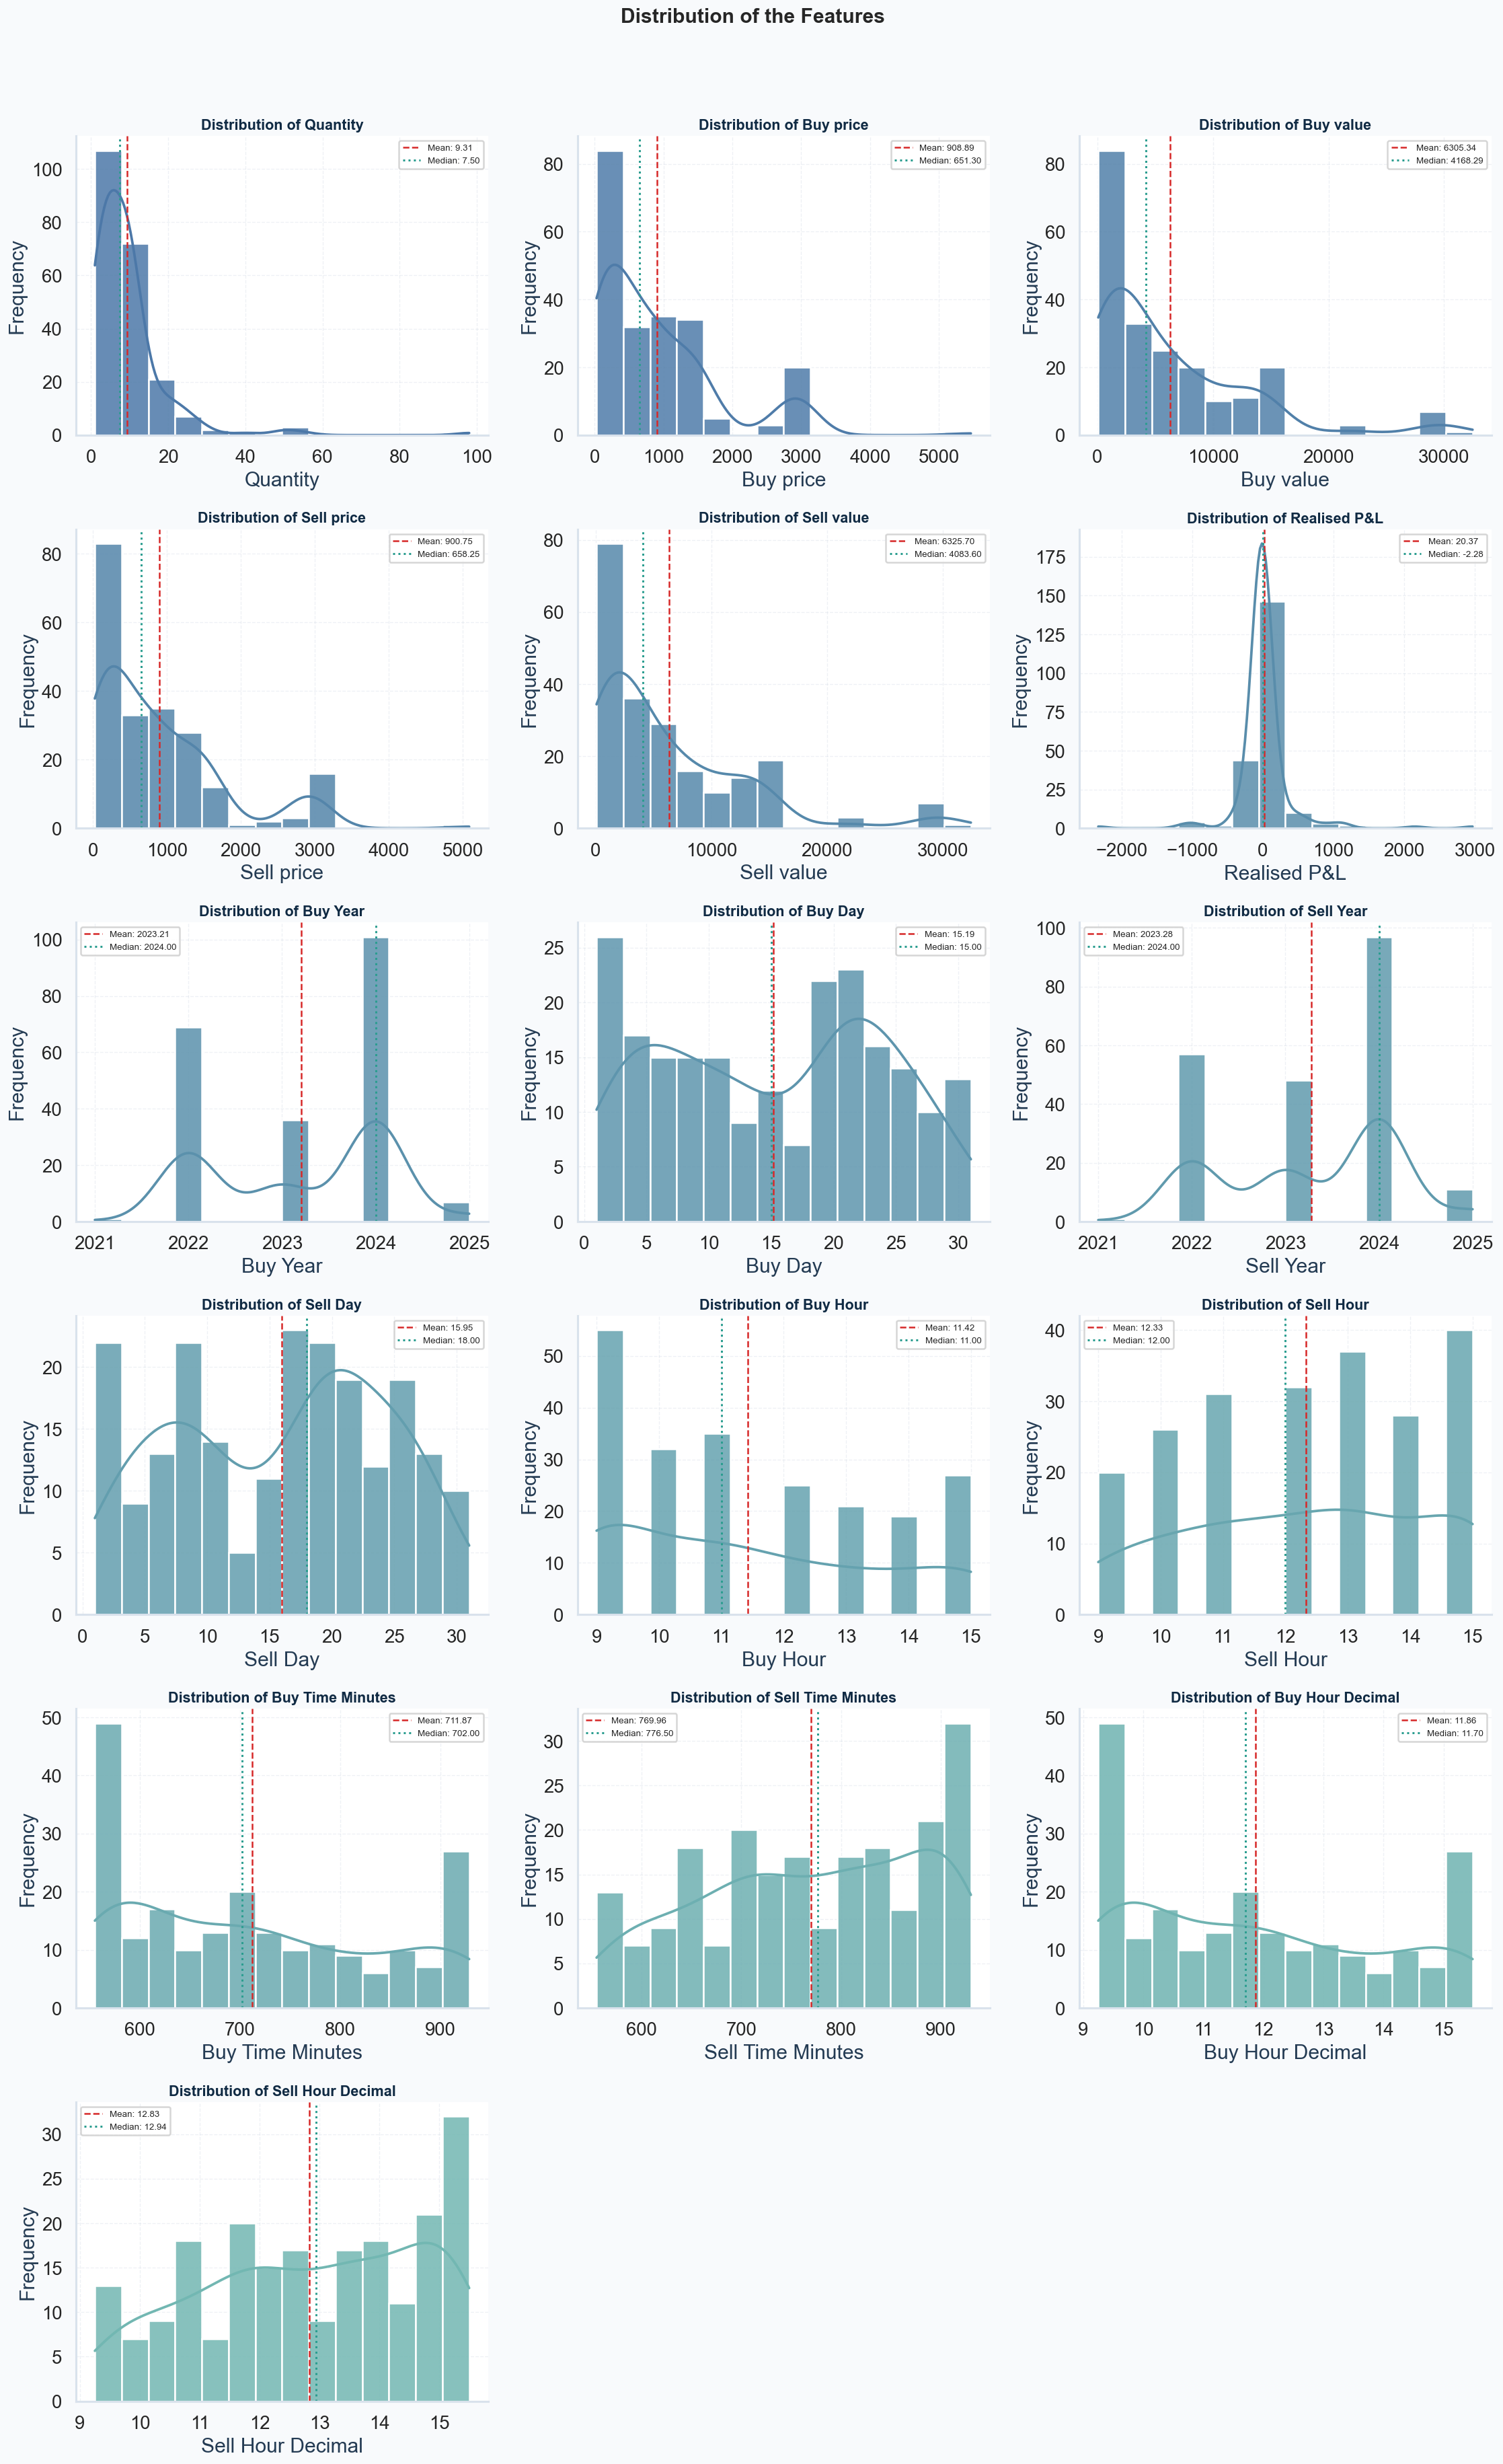

In [782]:
# Select numeric columns
numerical_cols = pnl.select_dtypes(include=['int64', 'float64']).columns

# Dynamically set rows and columns for subplot grid
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
palette = sns.color_palette("blend:#4c78a8,#72b7b2", n_colors=len(numerical_cols))

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(19, 5 * n_rows))
axes = axes.flatten()

# Plot each numeric column
for i, col in enumerate(numerical_cols):
    series = pnl[col].dropna()
    bins = min(30, max(10, int(np.sqrt(len(series)))))
    sns.histplot(series, kde=True, bins=bins, ax=axes[i], color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(series.mean(), color='#d62828', linestyle='--', linewidth=1.5, label=f"Mean: {series.mean():.2f}")
    axes[i].axvline(series.median(), color='#2a9d8f', linestyle=':', linewidth=1.8, label=f"Median: {series.median():.2f}")
    axes[i].set_title(f"Distribution of {col}", fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8)
    polish_axes(axes[i])

# Remove any unused axes (in case of fewer numeric columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of the Features", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot("Distribution of the Features", fig)
plt.show()


These plots tells us that there are too much skewness in the numerical cols. Also explaining that there are too much correlation between the Numerical cols

Now, let's do the Univariate Analysis for the Categorical features

In [783]:
# Merging the Industry rows appearing less than 4 times
uncommon_industry = pnl['Industry'].value_counts() 
pnl['Industry'] = pnl['Industry'].replace(uncommon_industry[uncommon_industry < 4].index, 'Others')

In [784]:
# Merging the Symbols rows appearing less than 5 times
uncommon_Symbols = pnl['Symbol'].value_counts() 
pnl['Symbol'] = pnl['Symbol'].replace(uncommon_Symbols[uncommon_Symbols < 4].index, 'Others')

Saved plot: Figures\02_Count Plot of Features.png


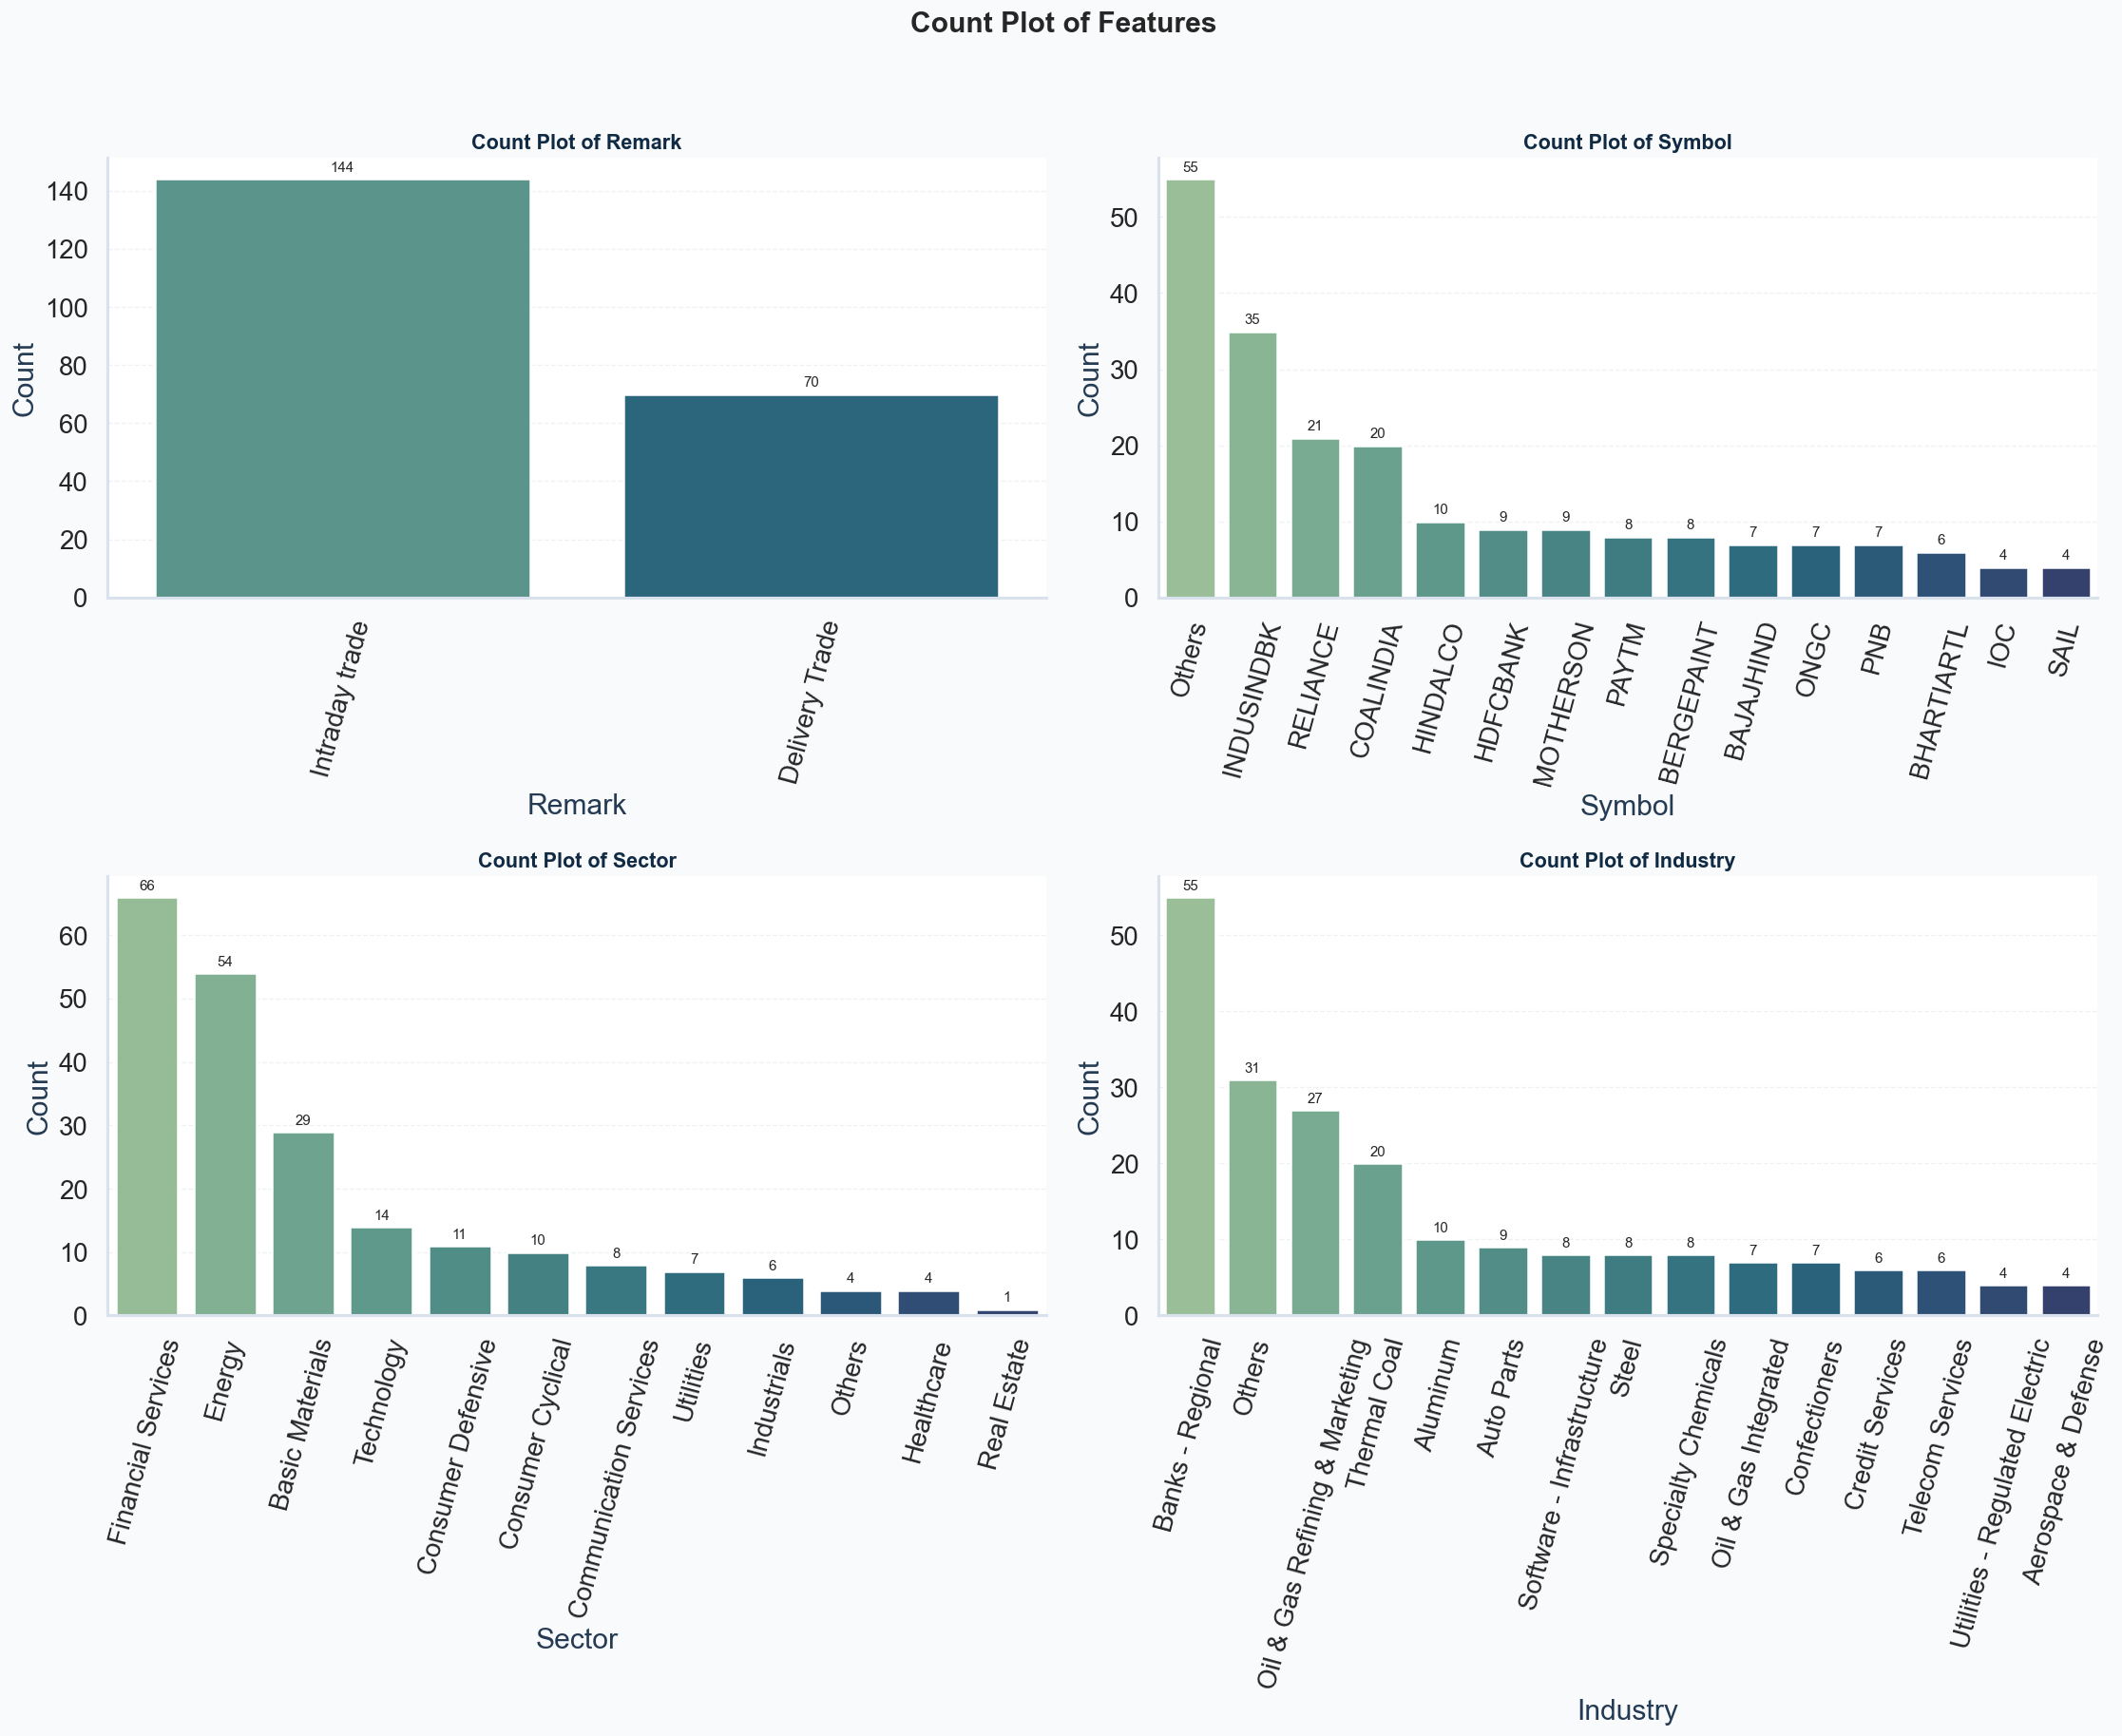

In [785]:
categorical_cols = ['Remark', 'Symbol', 'Sector', 'Industry']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(19, 15))
axes = axes.flatten()

# Plot each categorical column
for i, col in enumerate(categorical_cols):
    value_counts = pnl[col].fillna('Missing').value_counts().head(15)
    colors = sns.color_palette("crest", n_colors=len(value_counts))
    sns.barplot(x=value_counts.index, y=value_counts.values, hue=value_counts.index,
                palette=colors, legend=False, dodge=False, ax=axes[i])
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.0f', padding=3, fontsize=9)
    axes[i].set_title(f"Count Plot of {col}", fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    polish_axes(axes[i], rotate_x=75)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Count Plot of Features", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot("Count Plot of Features", fig)
plt.show()


First plot tells us that the user has traded mostly intraday then swing trades, also got lucky to get some IPO's allotment and got bonus shares for some of the holdings he had. 
Second plot tells us that user had traded different stocks while he had traded IndusInd Bank stock the most number of times. Third and Fourth plot tells us that the user had traded the stocks which comes from the different types of sectors and industry but his most traded were Financial Services and Regional Banks.

Let's plot the graph for the rest of the categorical features

Saved plot: Figures\03_Distribution of B and S Times (30 Mins).png


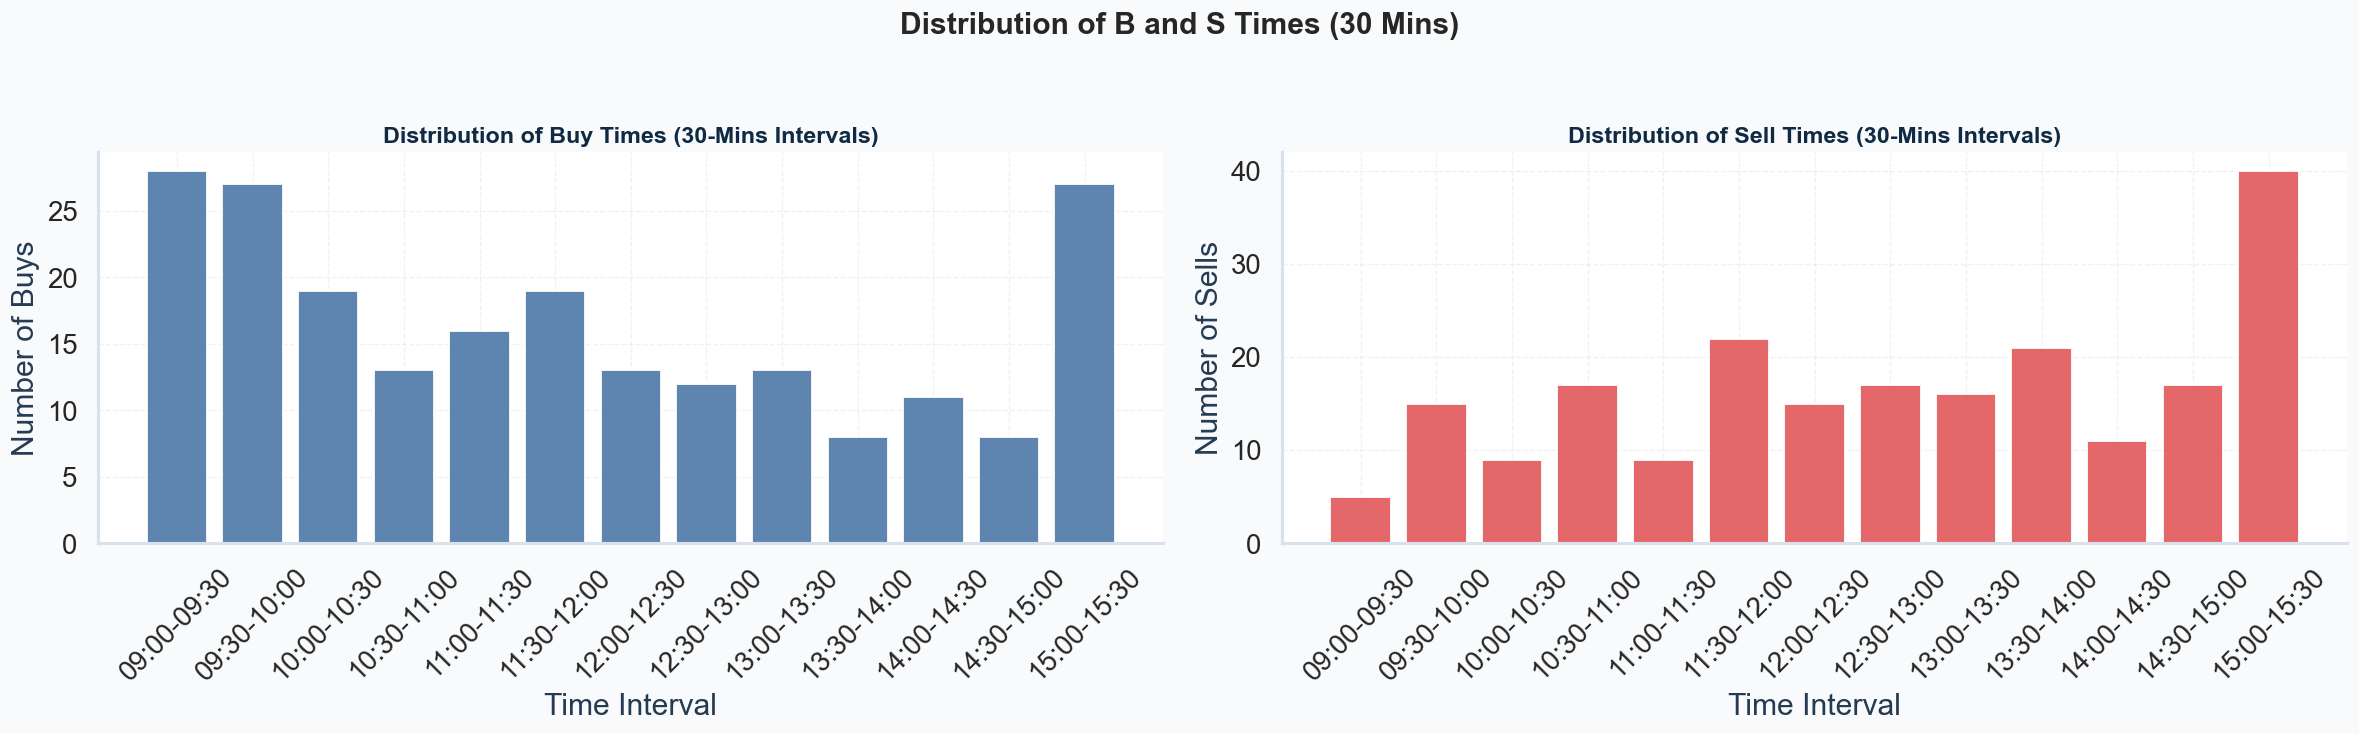

In [786]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

time_plot_config = [
    ('Buy Interval', 'Distribution of Buy Times (30-Mins Intervals)', 'Number of Buys', '#4c78a8'),
    ('Sell Interval', 'Distribution of Sell Times (30-Mins Intervals)', 'Number of Sells', '#e15759')
]

for ax, (col, title, ylabel, color) in zip(axes, time_plot_config):
    plot_data = pnl[col].value_counts().sort_index()
    bars = ax.bar(plot_data.index, plot_data.values, color=color, edgecolor='white', linewidth=1.2, alpha=0.9)
    if len(plot_data) <= 12:
        ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Interval')
    ax.set_ylabel(ylabel)
    polish_axes(ax, rotate_x=45)

fig.suptitle("Distribution of B and S Times (30 Mins)", fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
save_plot("Distribution of B and S Times (30 Mins)", fig)
plt.show()


Saved plot: Figures\04_Distribution of B and S Times (Months-Year).png


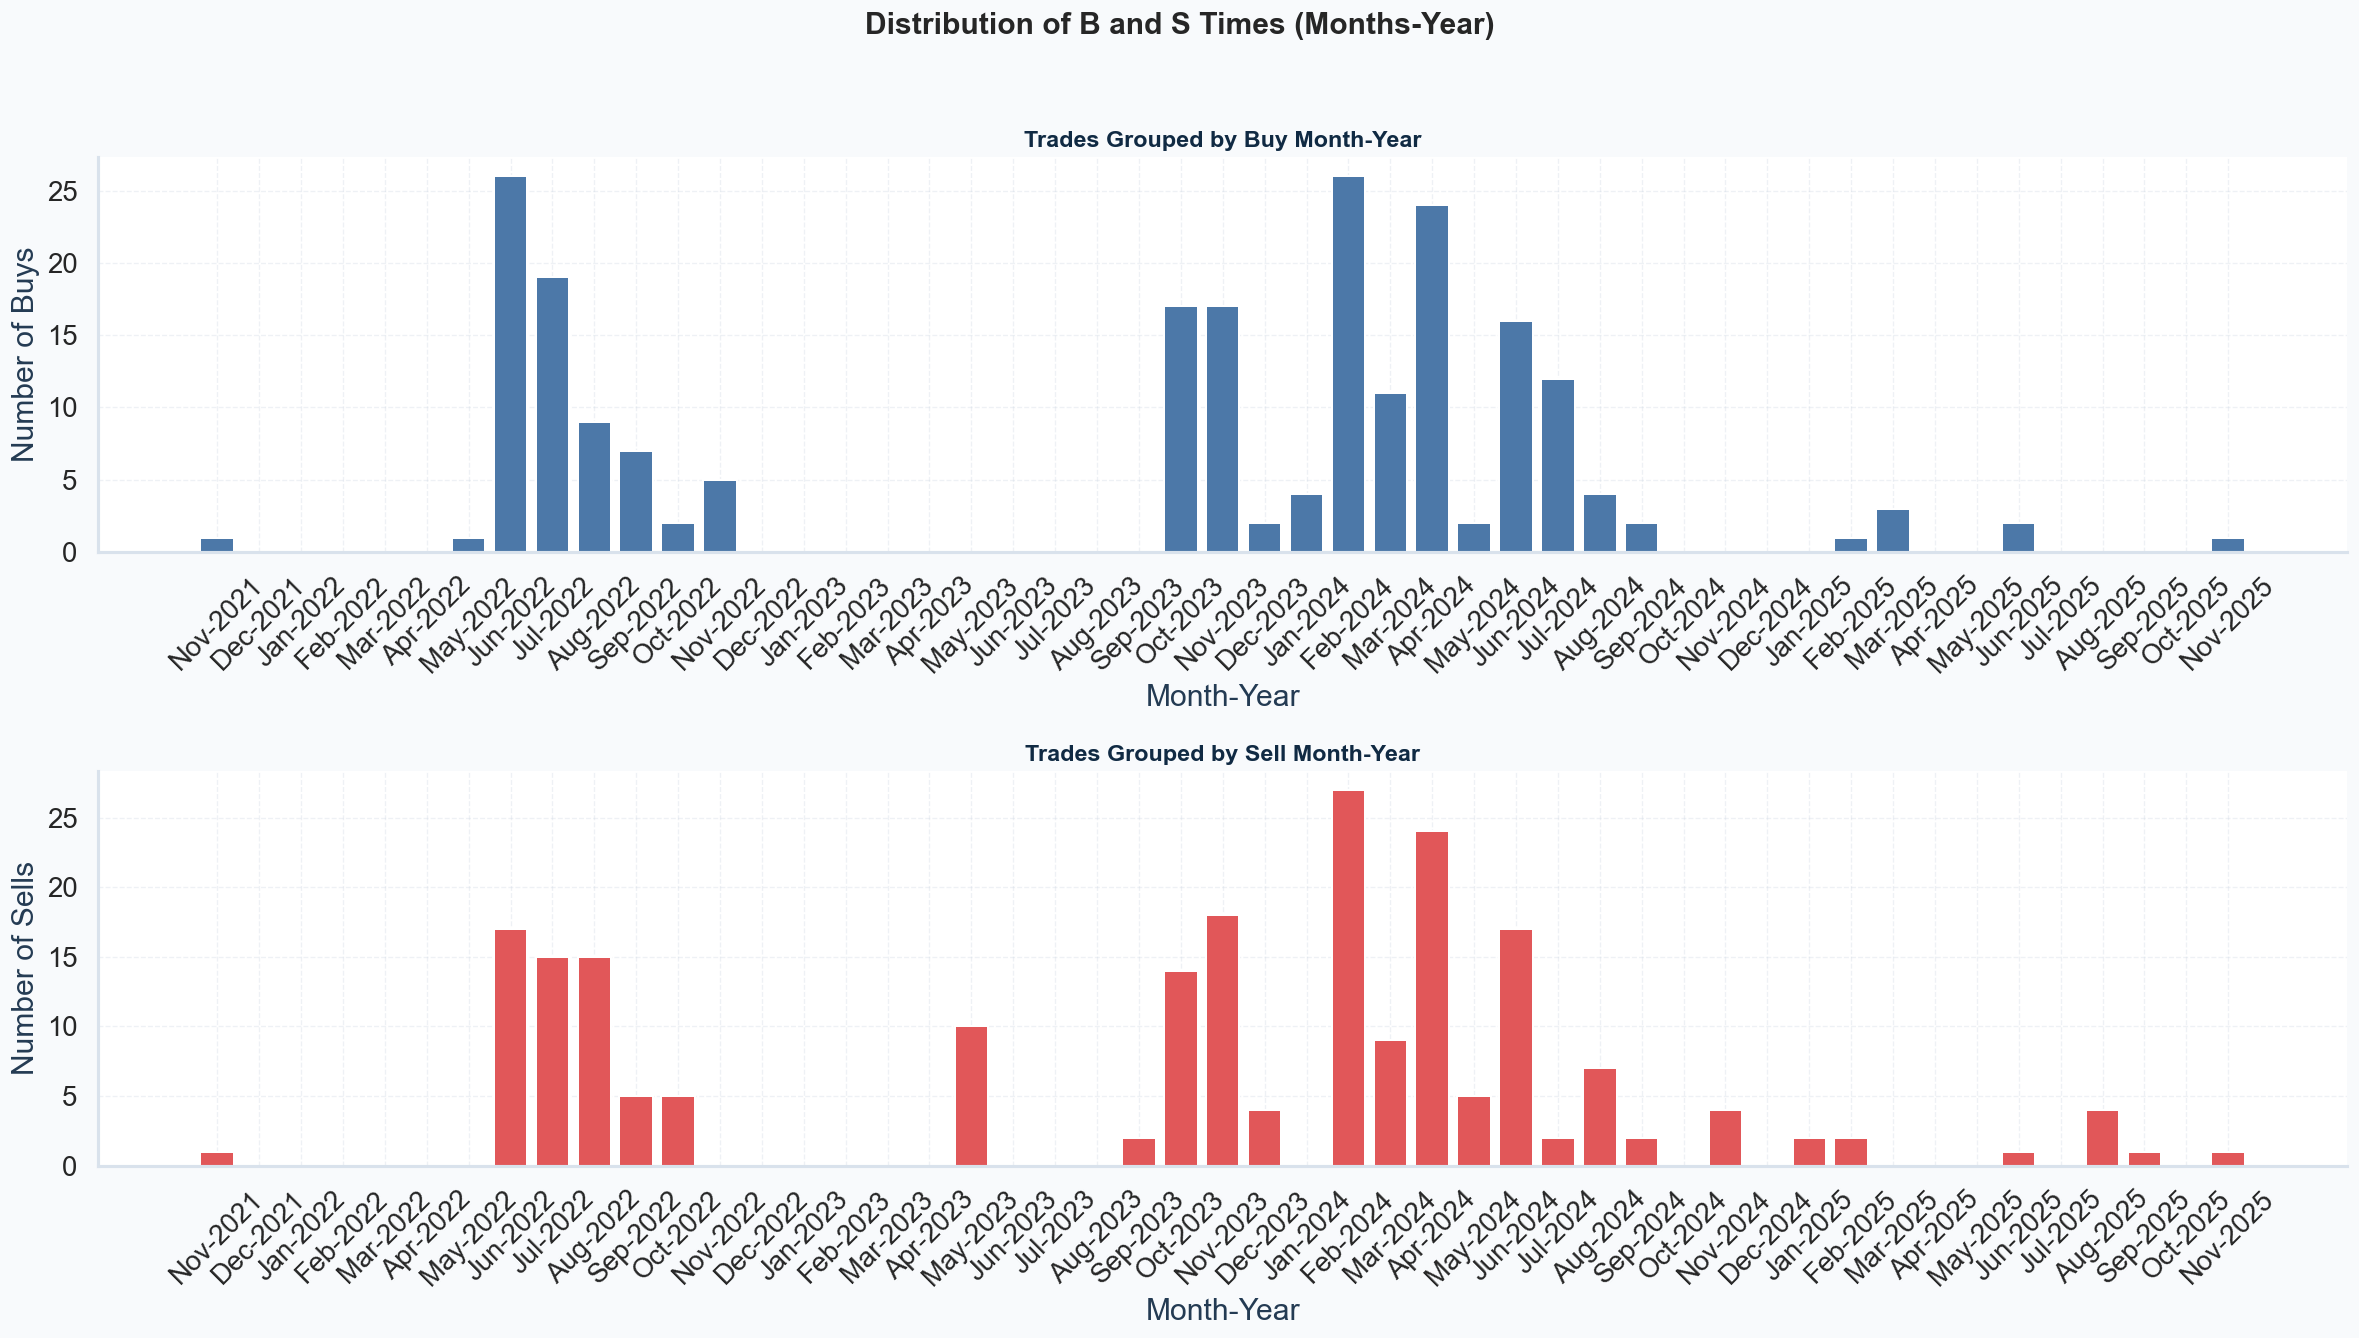

In [787]:
fig, axes = plt.subplots(2, 1, figsize=(20, 11), sharey=False)

# Buy Month-Year trades with all months filled
axes[0].set_title("Trades Grouped by Buy Month-Year", fontsize=14, fontweight='bold')
pnl['Buy Month-Year'] = pnl['Buy Month'] + '-' + pnl['Buy Year'].astype(str)
min_date = pd.to_datetime(pnl['Buy Month-Year'], format='%b-%Y').min()
max_date = pd.to_datetime(pnl['Buy Month-Year'], format='%b-%Y').max()
all_months_buy = pd.date_range(start=min_date, end=max_date, freq='MS').strftime('%b-%Y')
buy_month_year_data = pnl['Buy Month-Year'].value_counts().reindex(all_months_buy, fill_value=0)
bars_buy = axes[0].bar(buy_month_year_data.index, buy_month_year_data.values, color='#4c78a8', edgecolor='white', linewidth=1.2)
axes[0].set_xlabel("Month-Year")
axes[0].set_ylabel("Number of Buys")
polish_axes(axes[0], rotate_x=45)

# Sell Month-Year trades with all months filled
axes[1].set_title("Trades Grouped by Sell Month-Year", fontsize=14, fontweight='bold')
pnl['Sell Month-Year'] = pnl['Sell Month'] + '-' + pnl['Sell Year'].astype(str)
min_date = pd.to_datetime(pnl['Sell Month-Year'], format='%b-%Y').min()
max_date = pd.to_datetime(pnl['Sell Month-Year'], format='%b-%Y').max()
all_months_sell = pd.date_range(start=min_date, end=max_date, freq='MS').strftime('%b-%Y')
sell_month_year_data = pnl['Sell Month-Year'].value_counts().reindex(all_months_sell, fill_value=0)
bars_sell = axes[1].bar(sell_month_year_data.index, sell_month_year_data.values, color='#e15759', edgecolor='white', linewidth=1.2)
axes[1].set_xlabel("Month-Year")
axes[1].set_ylabel("Number of Sells")
polish_axes(axes[1], rotate_x=45)

fig.suptitle("Distribution of B and S Times (Months-Year)", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot("Distribution of B and S Times (Months-Year)", fig)
plt.show()


These Plots tells us that the user had buy the most number of the stocks in the first hour of the day and sell stocks in the last hour of the day while also says that the user was trading from the Nov,21 but were mostly active between the June,22 to Sept,22 and Oct,23 to July,24 telling that he is not focused properly or gets unactive after huge losses and also he had taken some gaps between the months were he was completely unactive.

2. Bivariate Analysis

Now, let's do the bivariate analysis. Starting with the plots between the Numerical vs Numerical features

Saved plot: Figures\05_Pair Plot of the Features.png


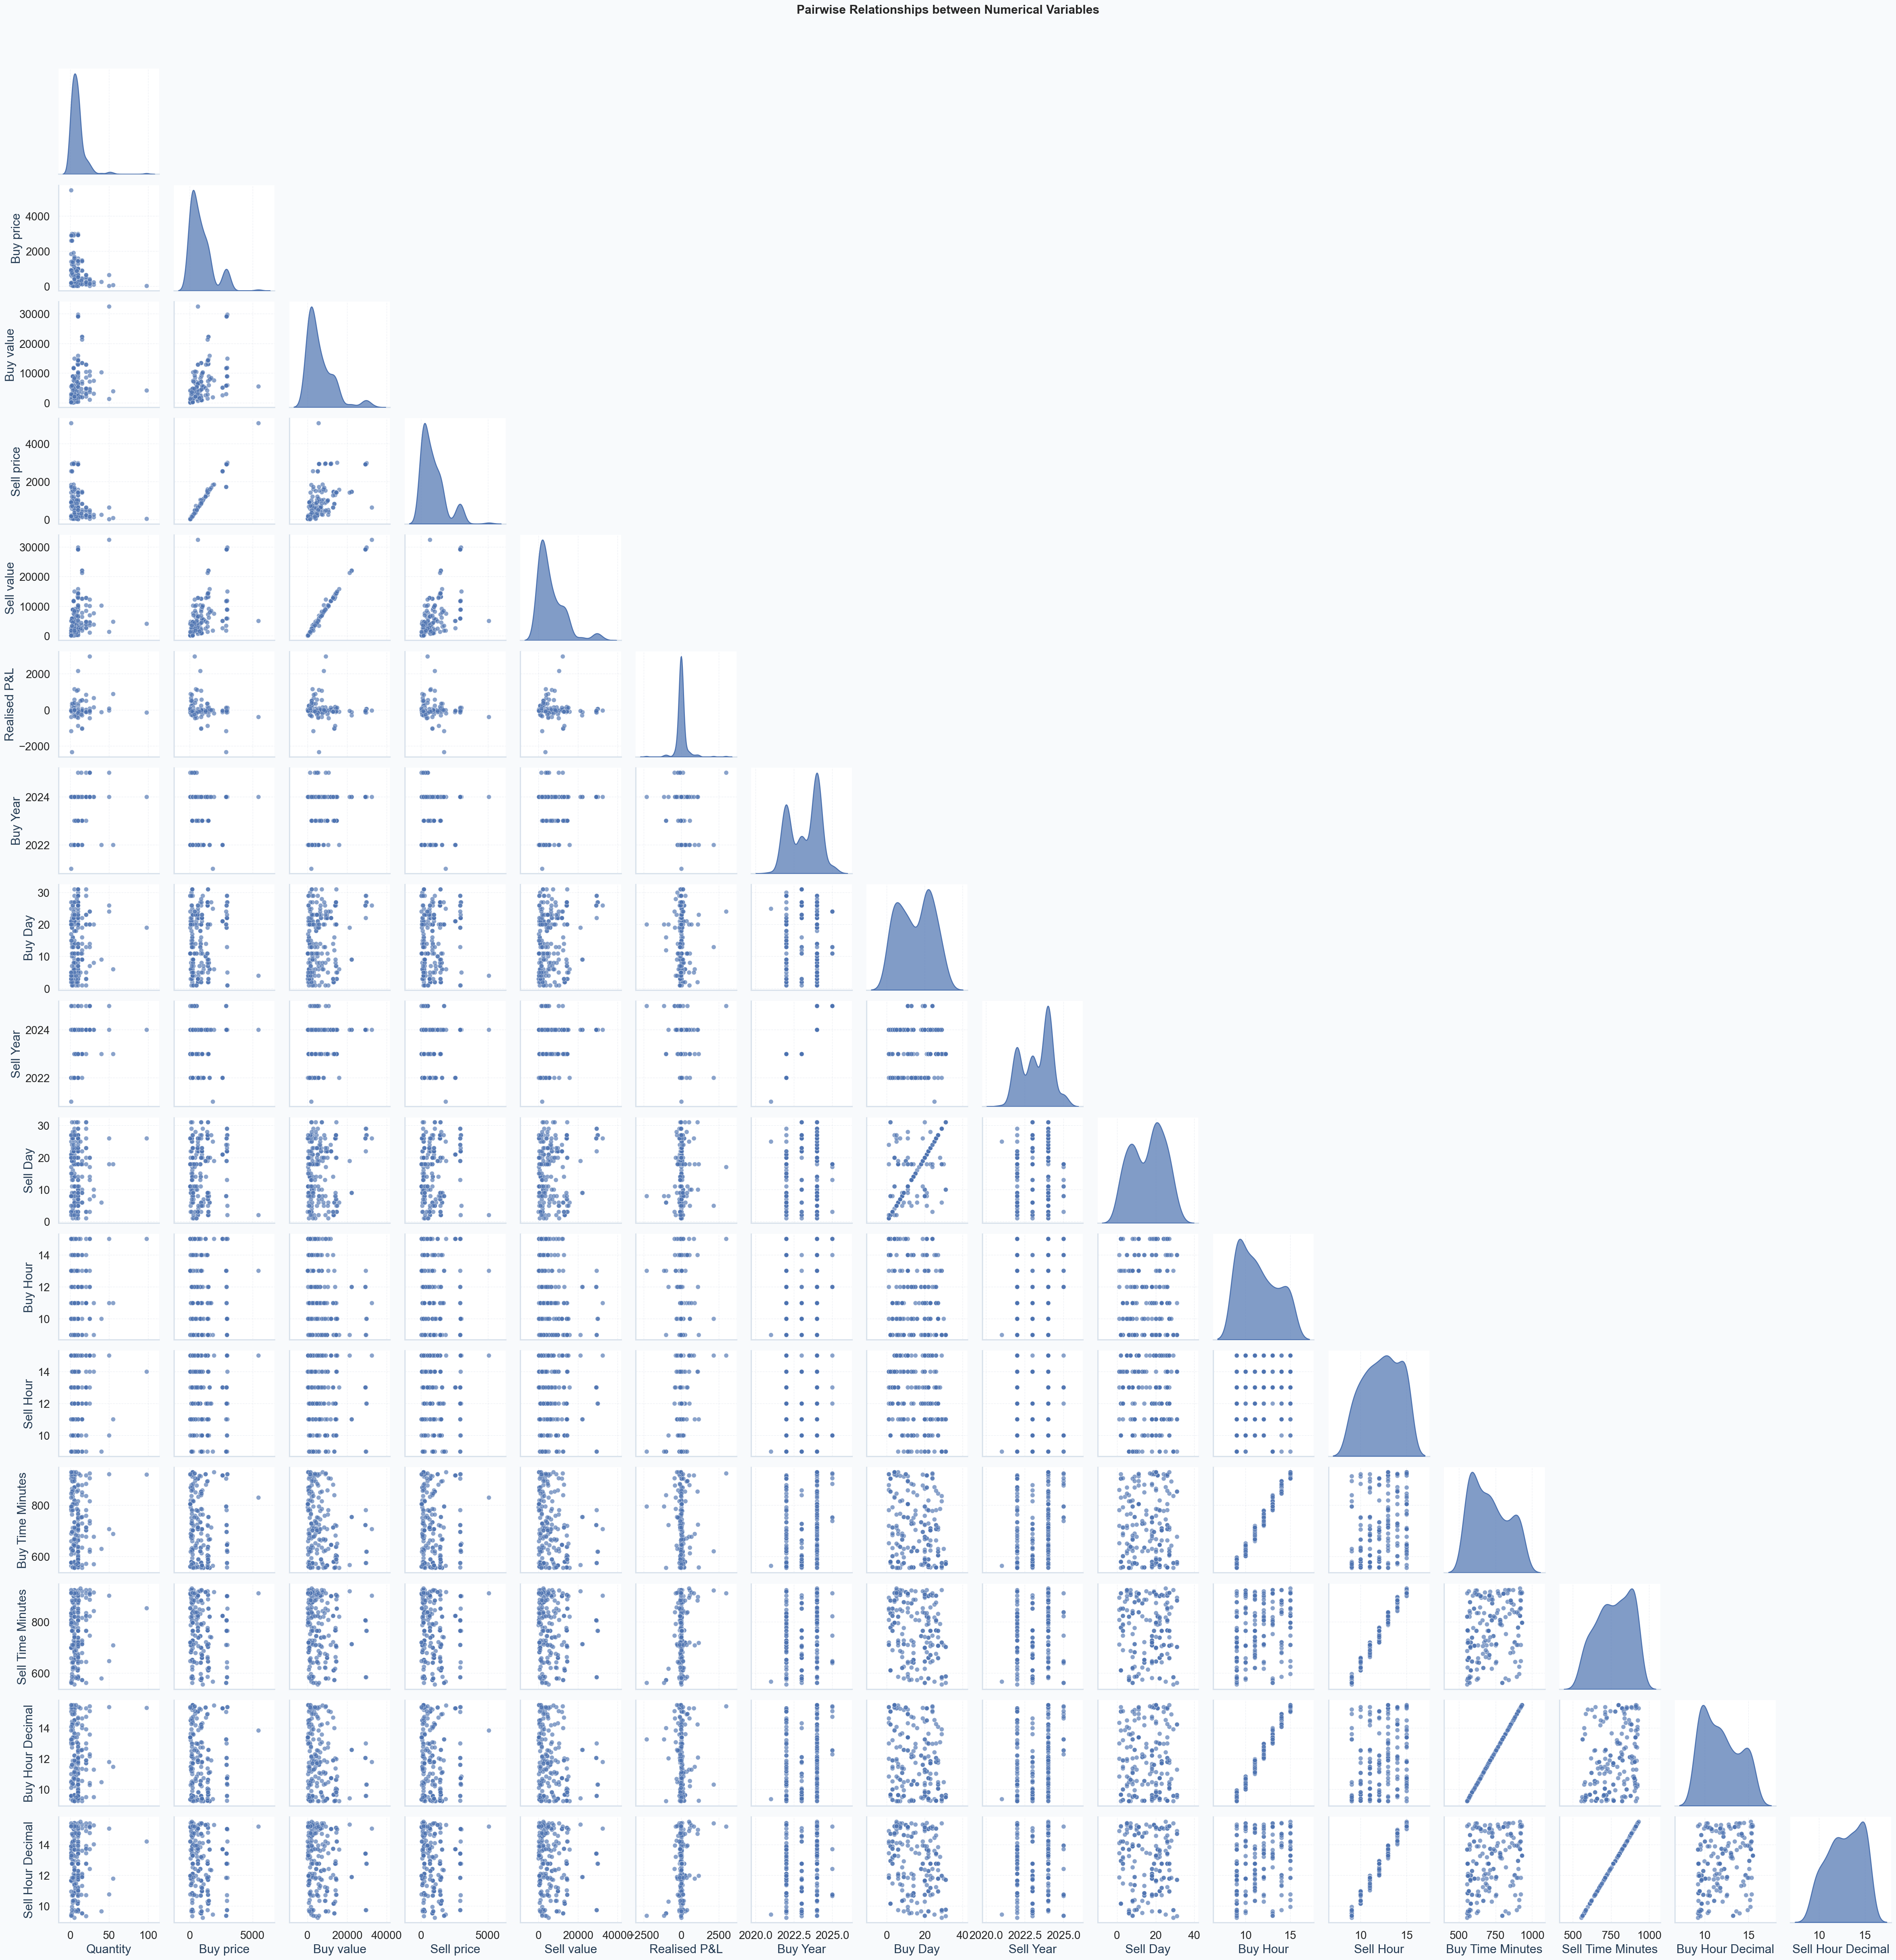

In [788]:
# Pairplot for all numerical features
pair_grid = sns.pairplot(
    pnl[numerical_cols],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.65, 's': 45, 'edgecolor': 'white', 'linewidth': 0.4},
    diag_kws={'fill': True, 'alpha': 0.7}
)
pair_grid.fig.suptitle("Pairwise Relationships between Numerical Variables", y=1.02, fontsize=18, fontweight='bold')
save_plot("Pair Plot of the Features", pair_grid.fig)
plt.show()

Saved plot: Figures\06_Correlation Heatmap of the Features.png


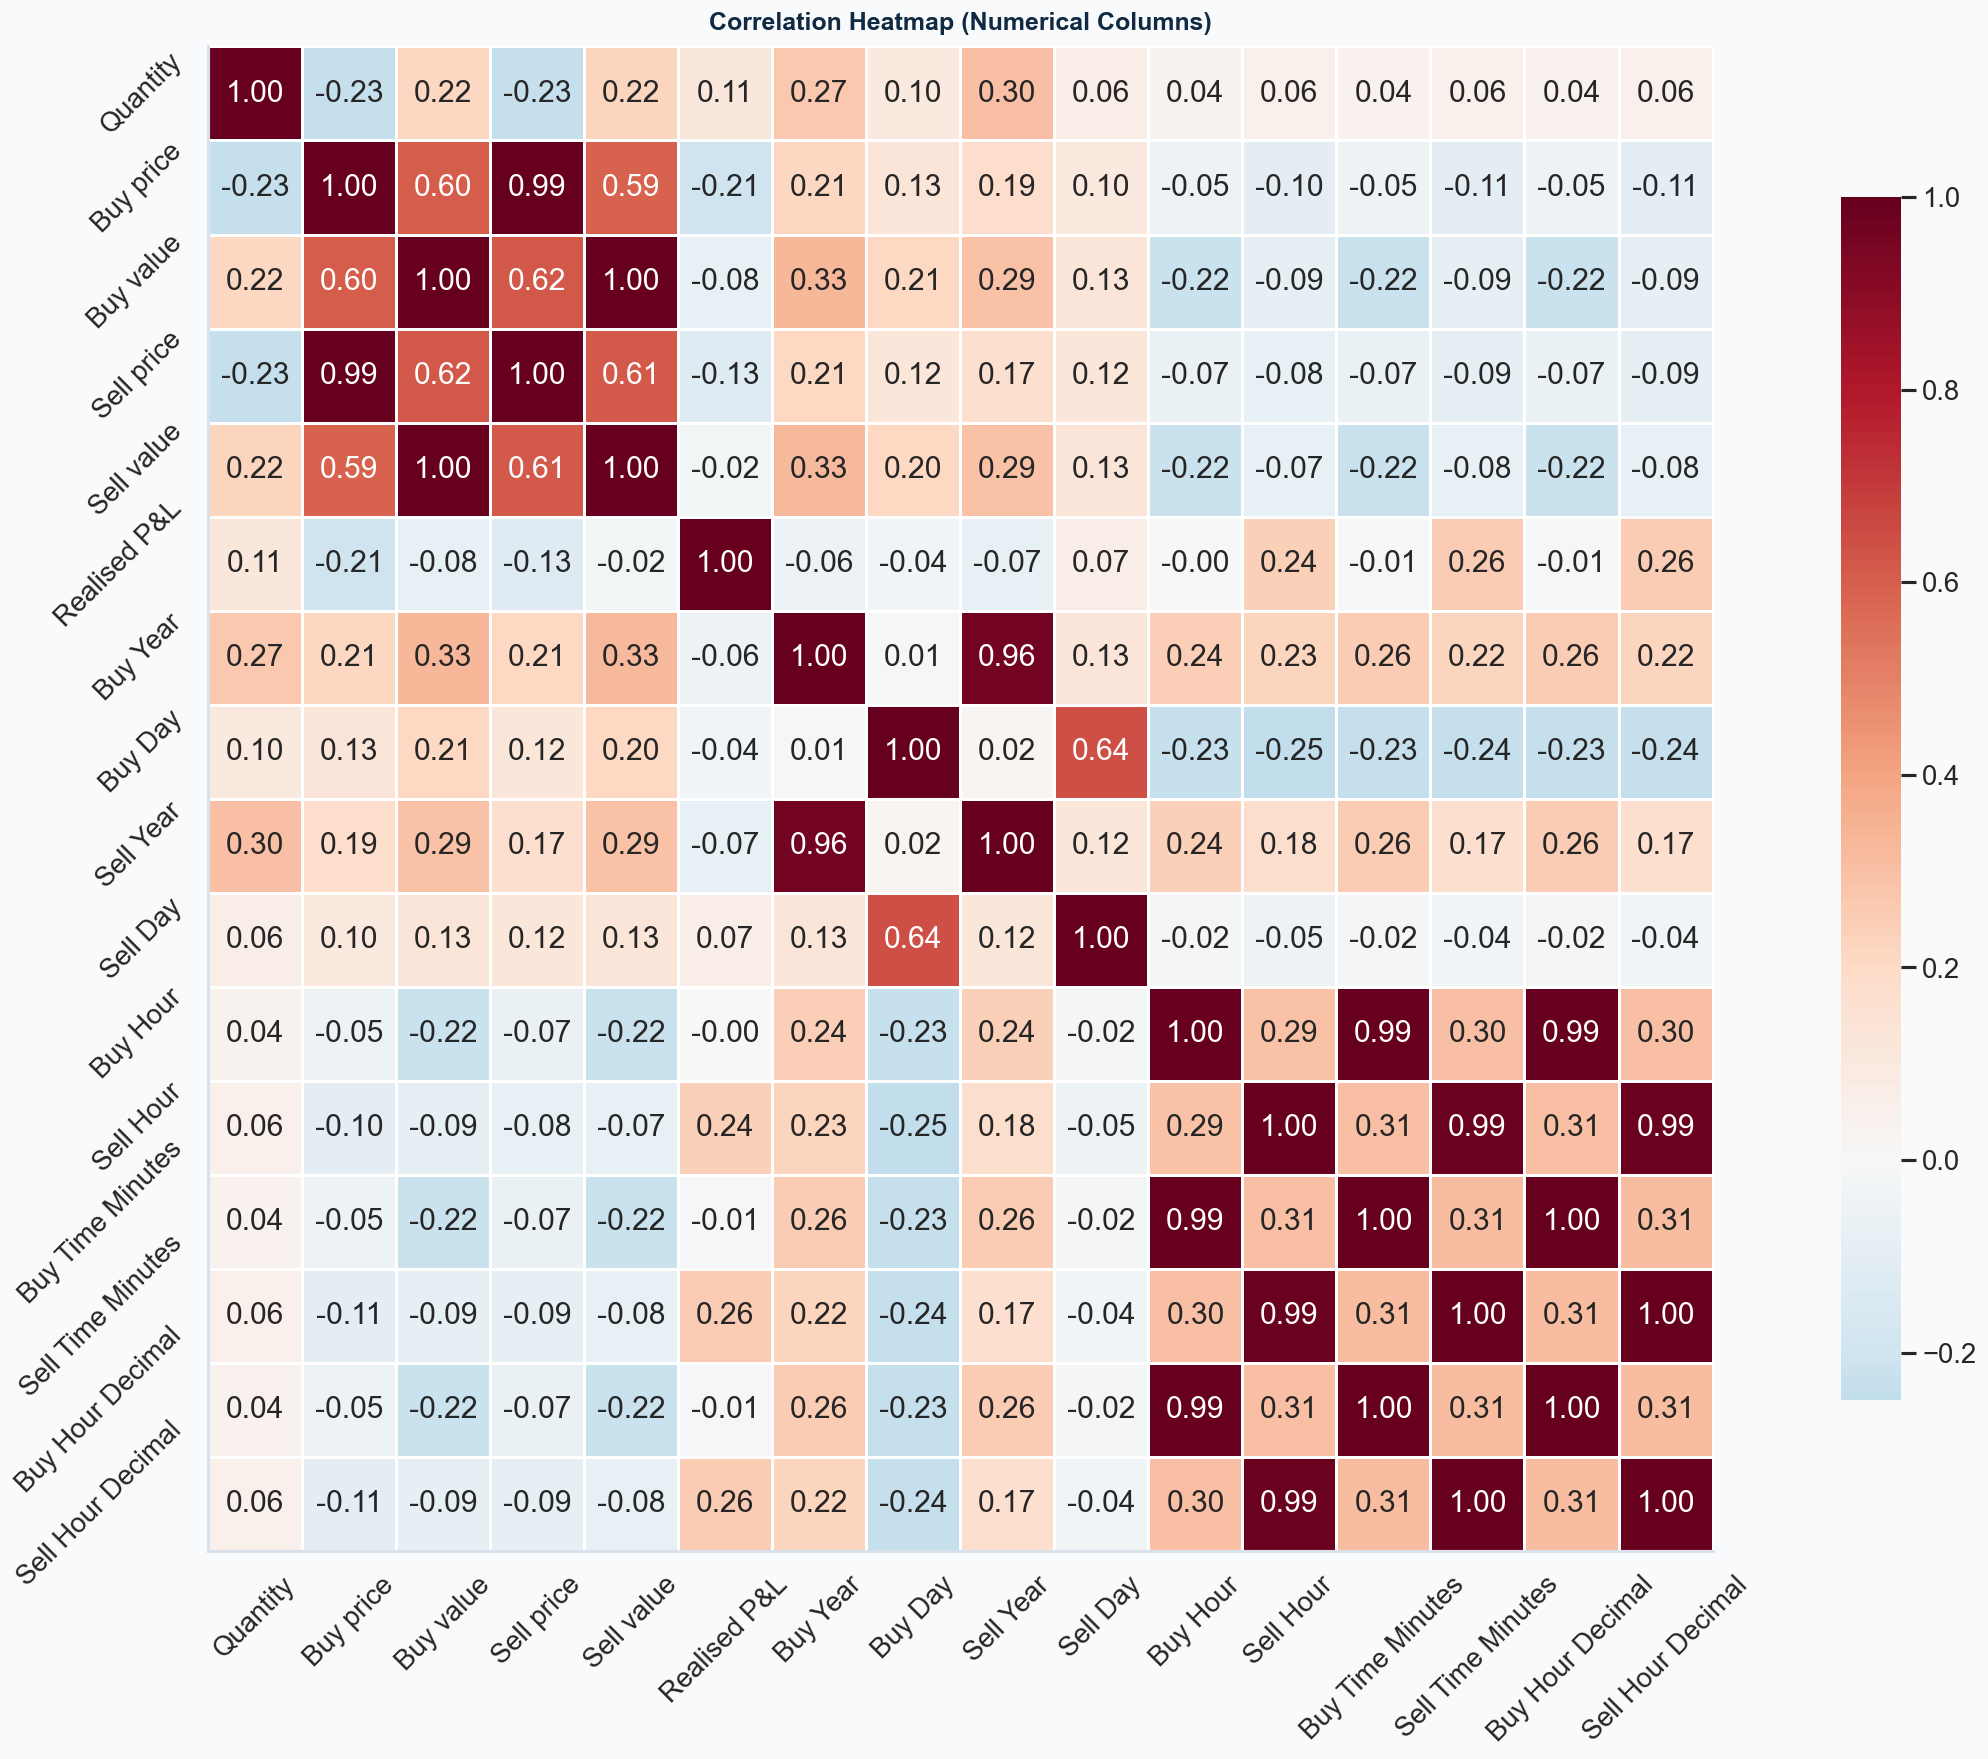

In [789]:
# Correlation Heatmap
corr_matrix = pnl[numerical_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(22, 15))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.8, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title("Correlation Heatmap (Numerical Columns)", fontsize=15, fontweight='bold', pad=10)
polish_axes(ax, rotate_x=45, rotate_y = 45)
plt.tight_layout()
save_plot("Correlation Heatmap of the Features", fig)
plt.show()

---------Plots between Numerical vs Categorical features

Saved plot: Figures\07_Avg Realised PnL by Remarks.png


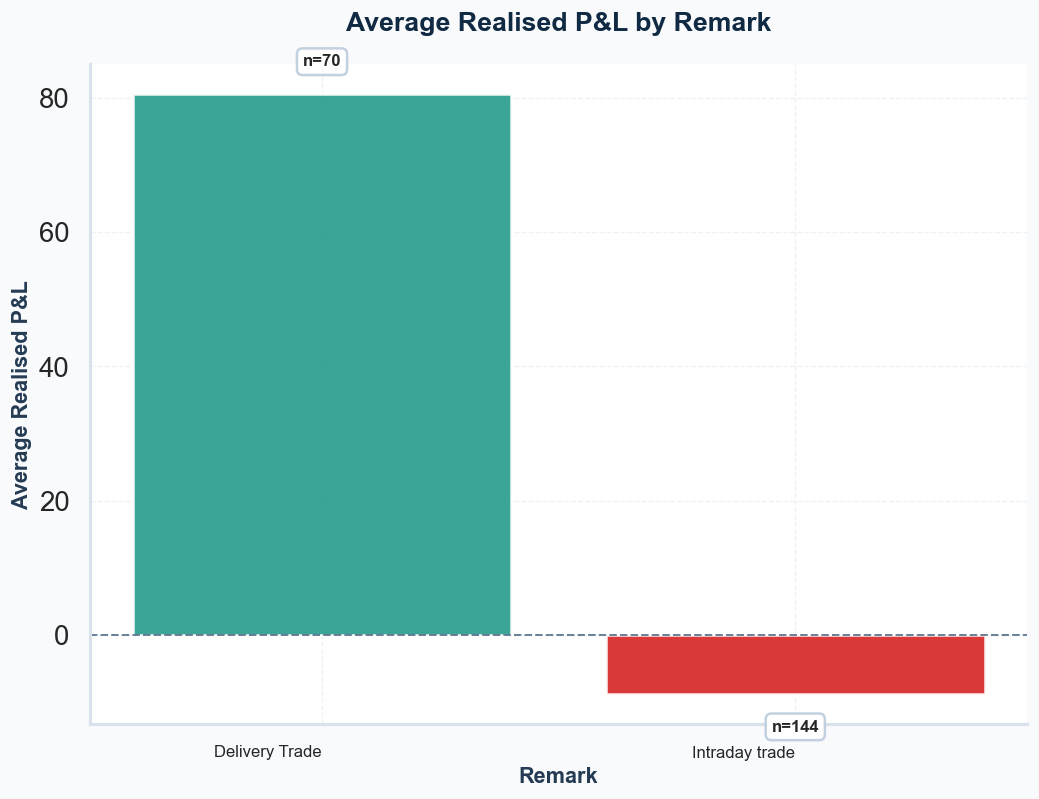

Saved plot: Figures\08_Avg Realised PnL by B and S Times.png


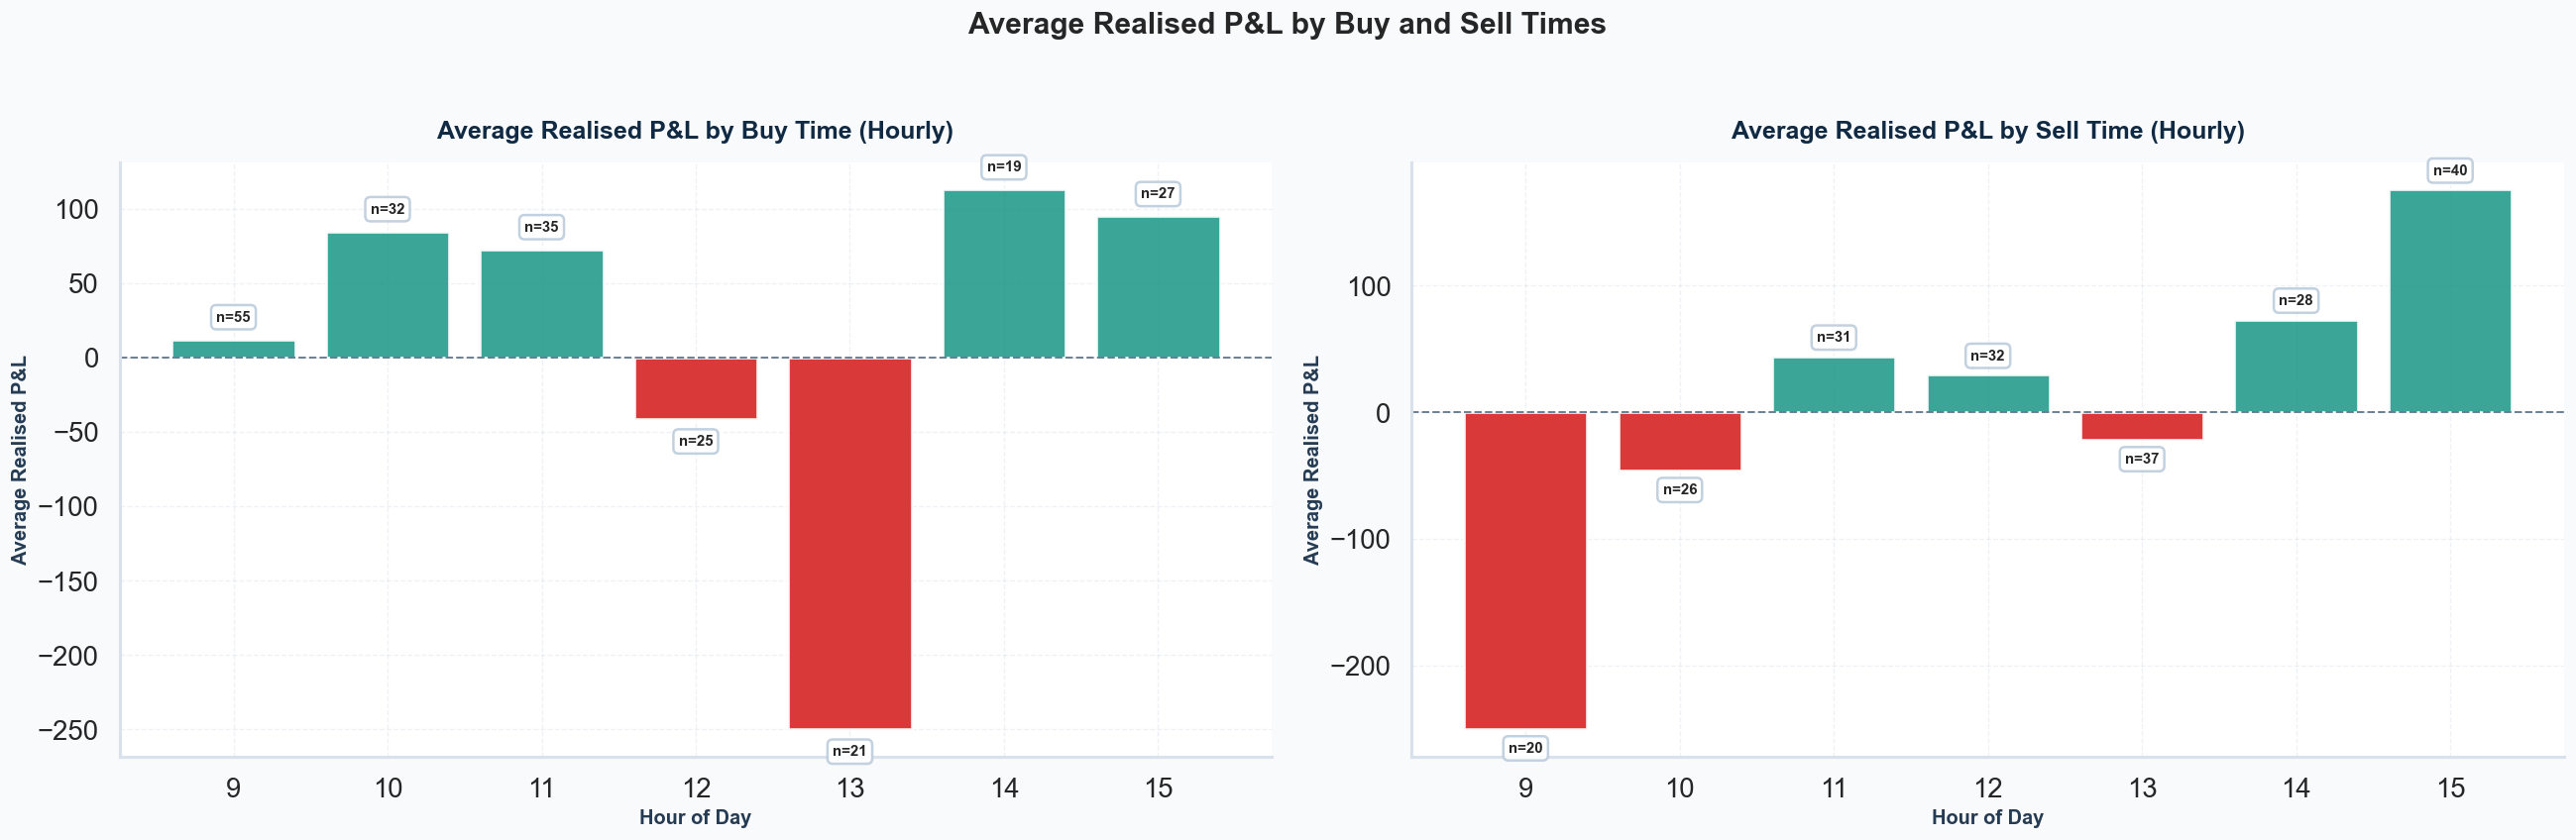

Saved plot: Figures\09_Avg Realised PnL by Symbols.png


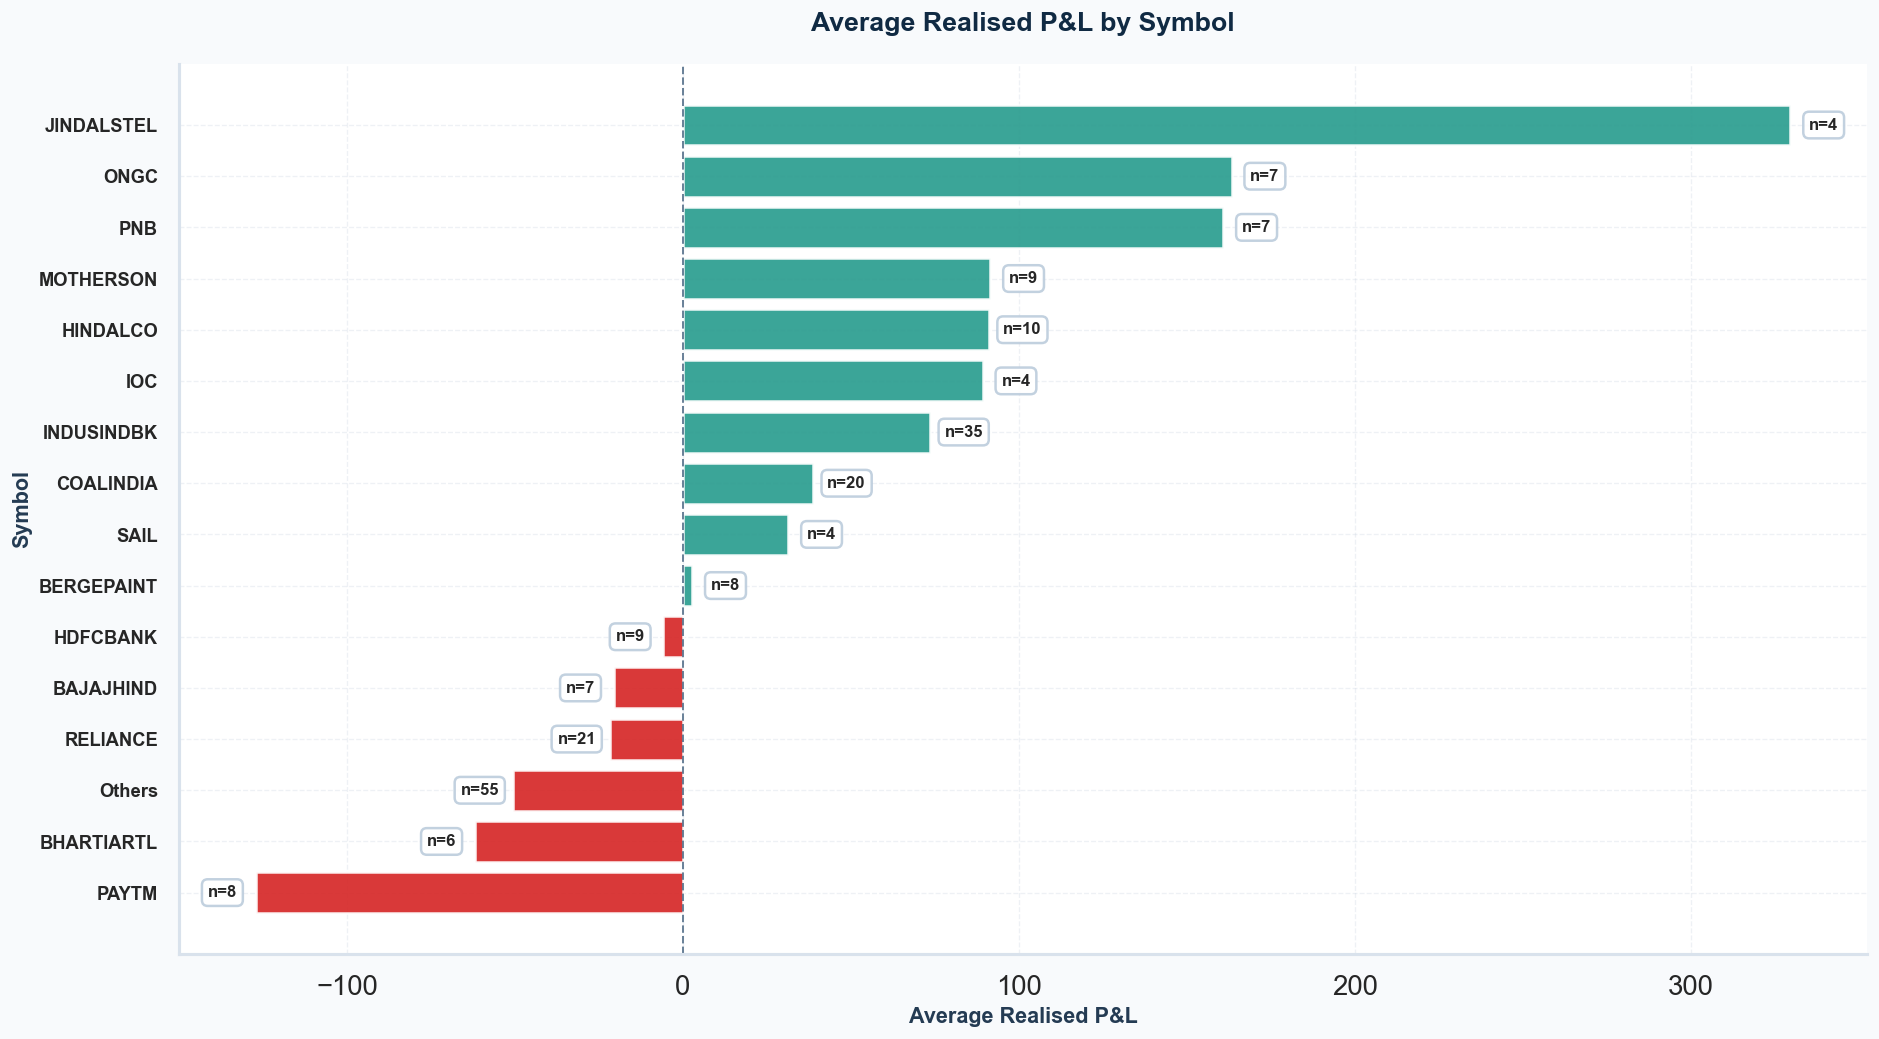

Saved plot: Figures\10_Avg and Total Realised PnL by Sectors.png


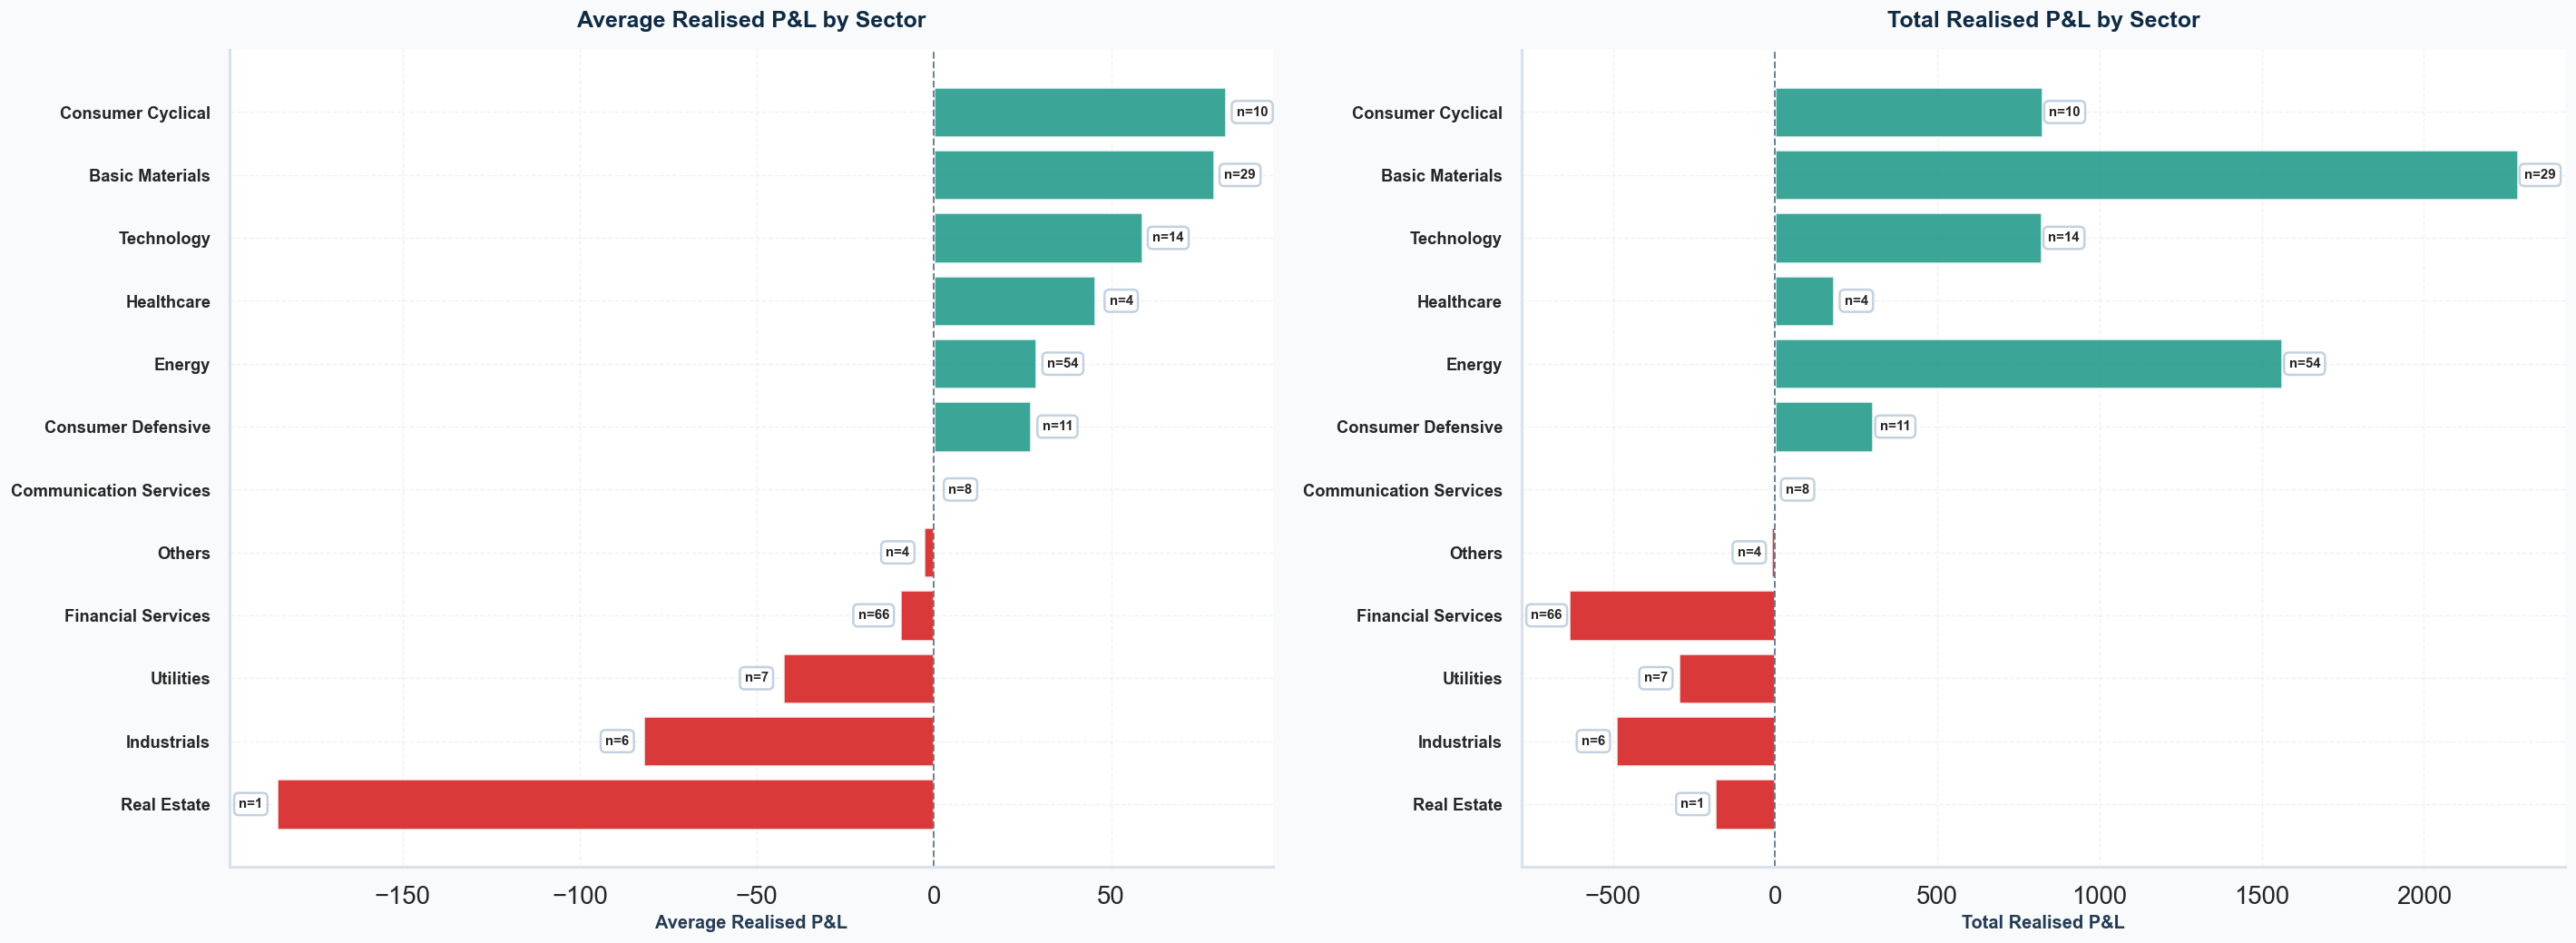

Saved plot: Figures\11_Avg and Total Realised PnL by Industries.png


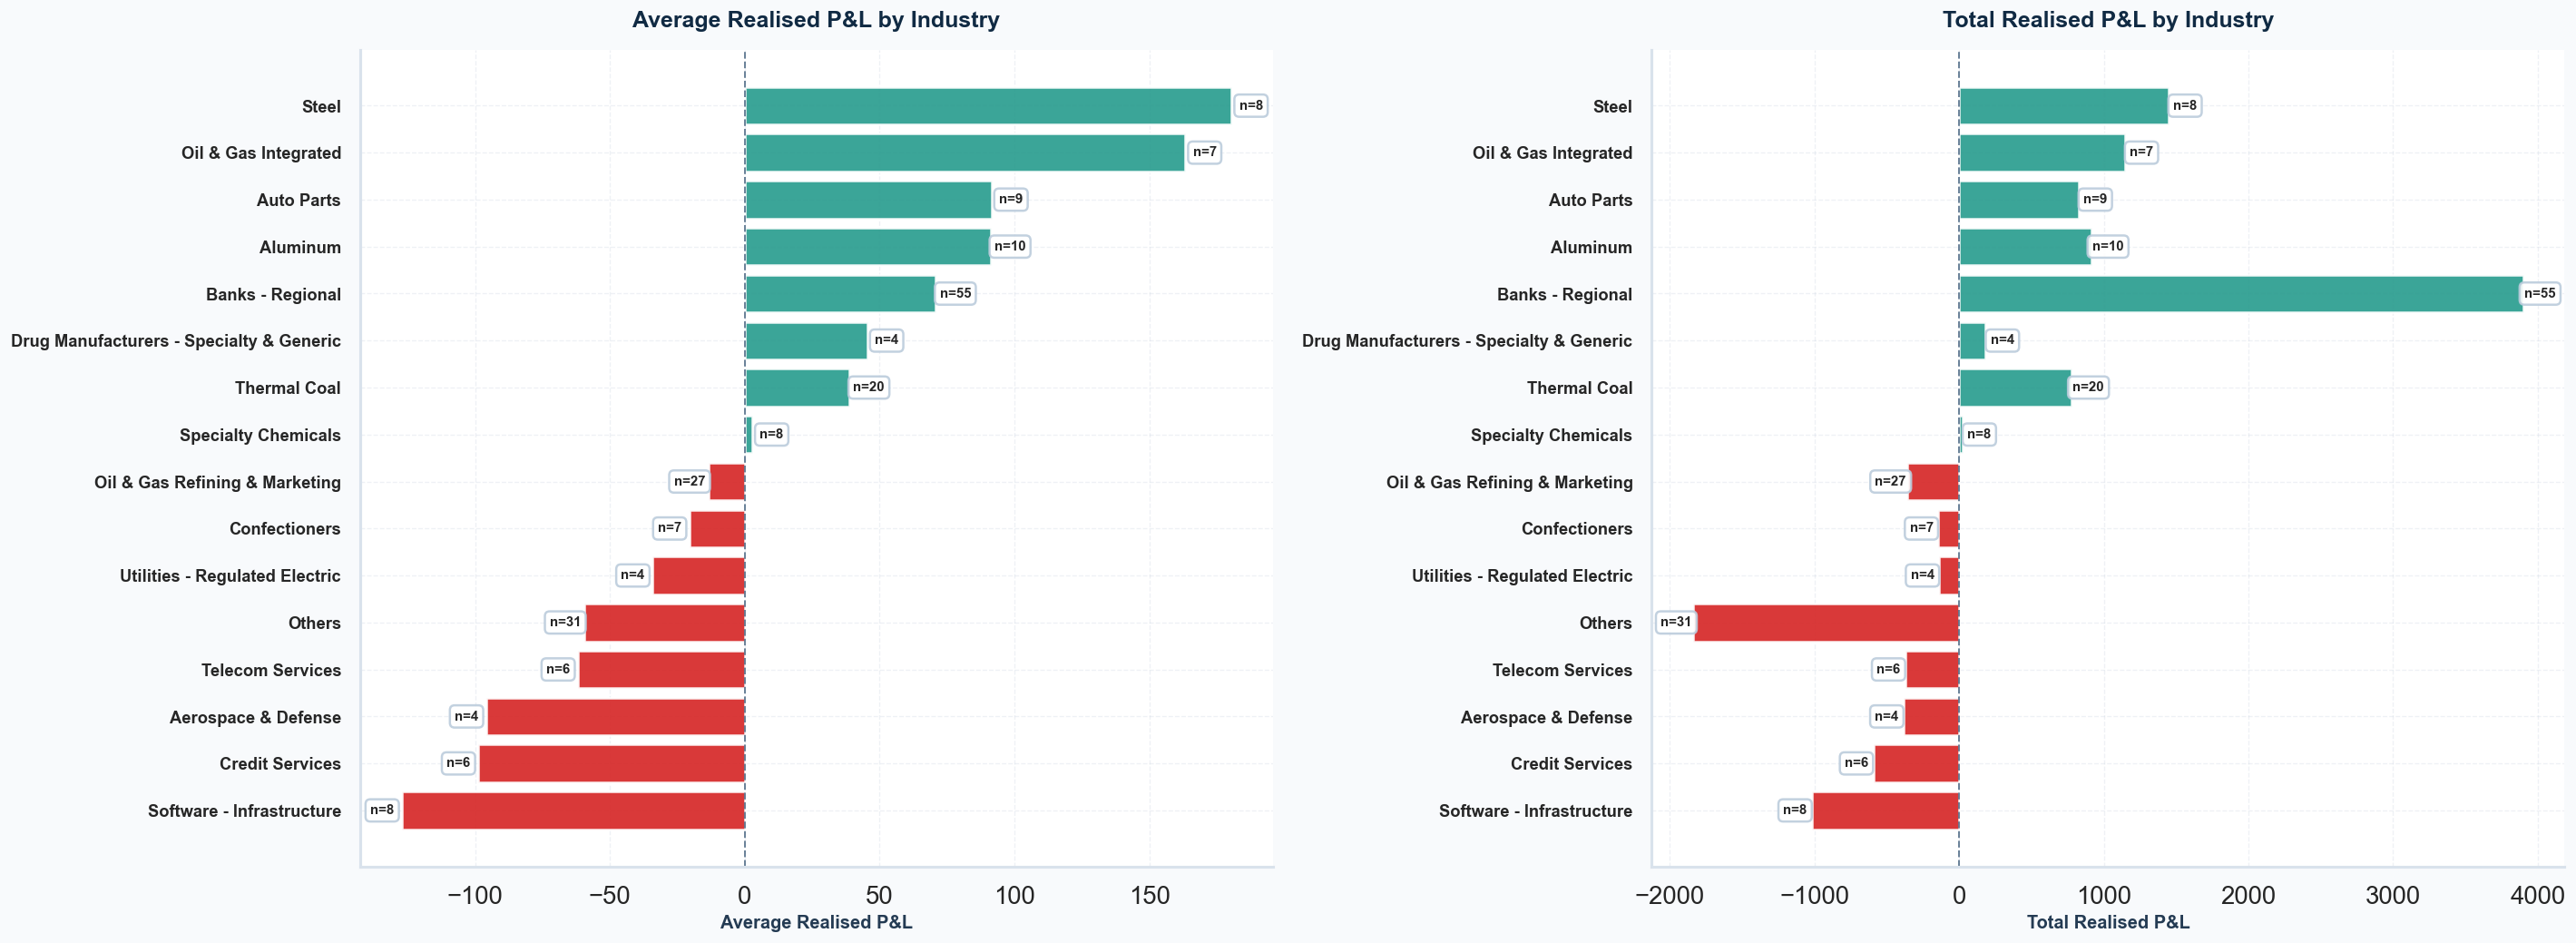

Saved plot: Figures\12_Average Realised P&L by Buy Month.png


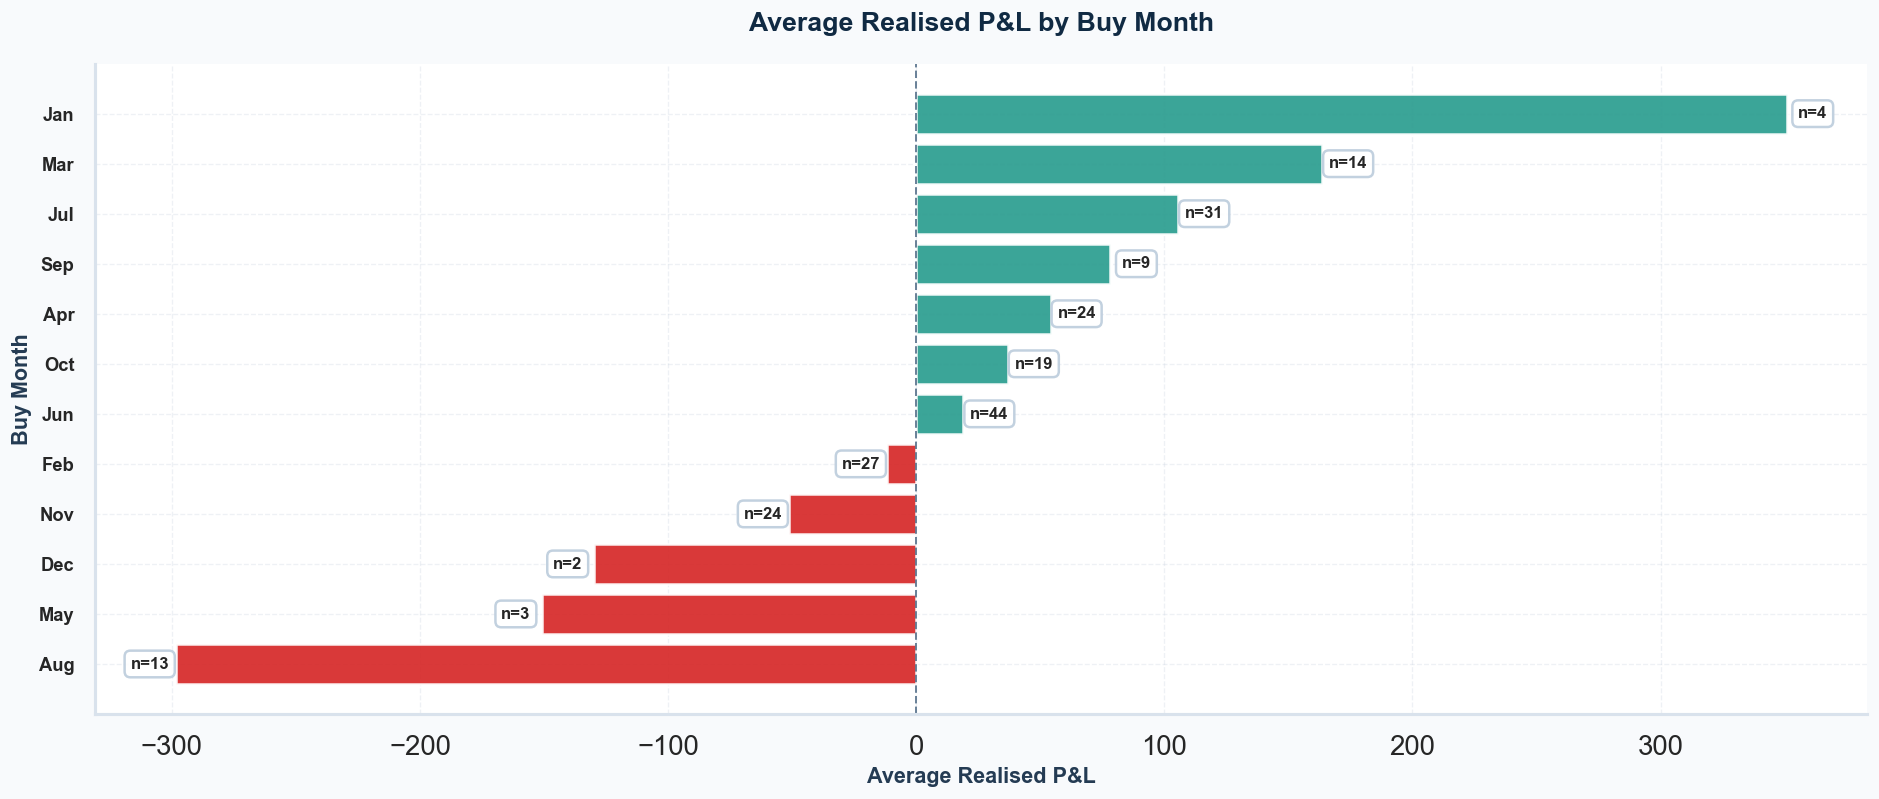

Saved plot: Figures\13_Average Realised P&L by Buy Day of Week.png


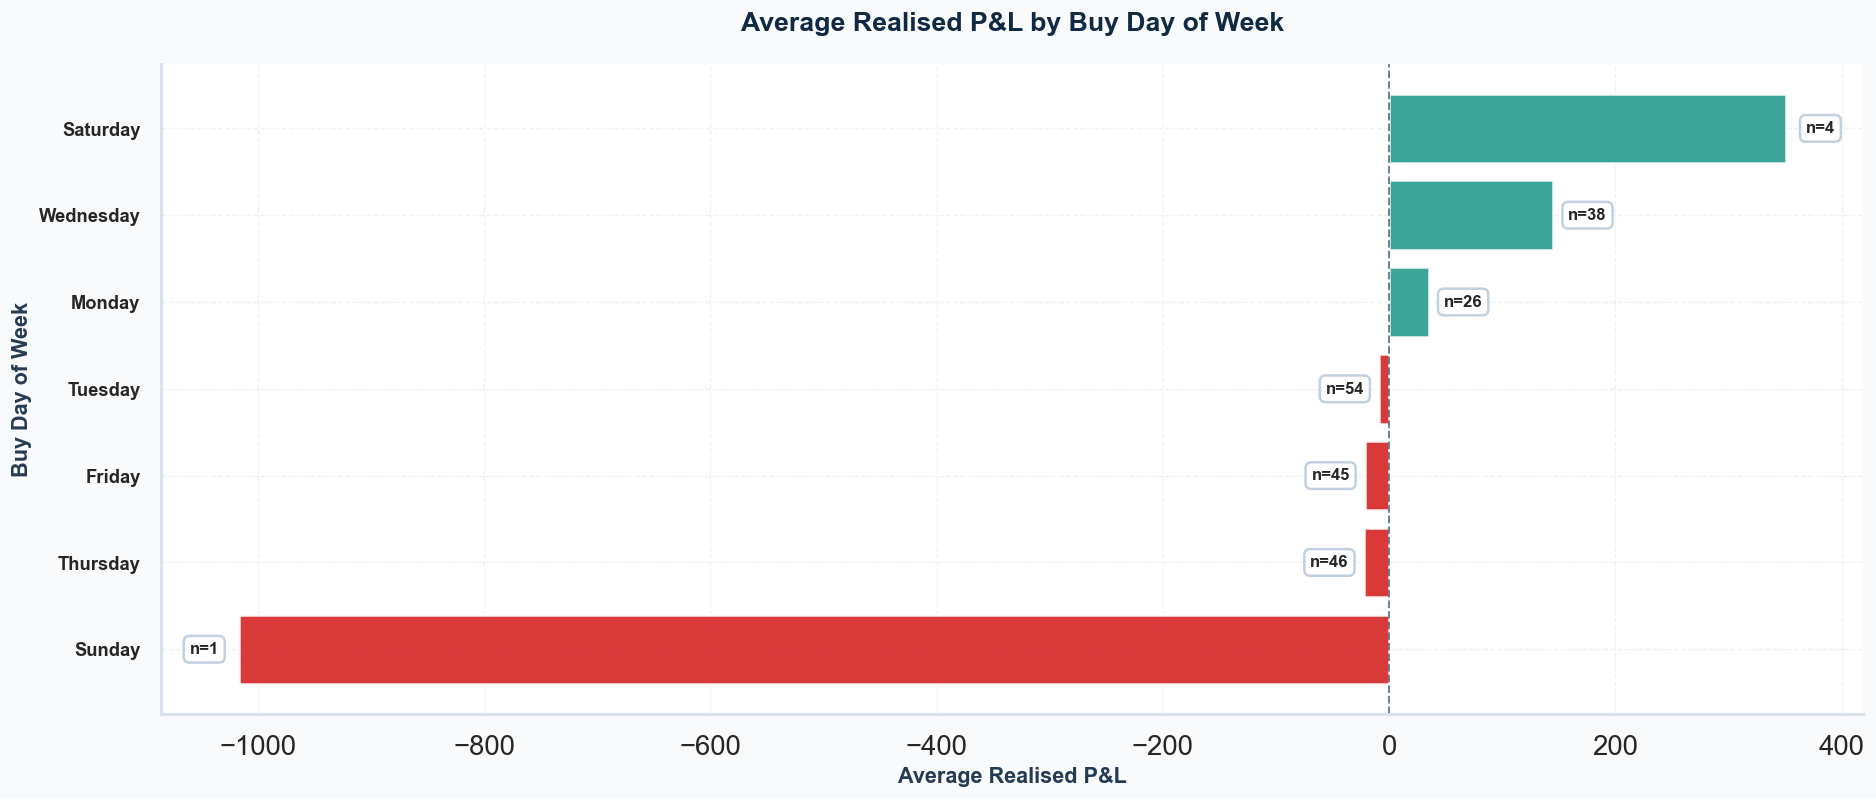

Saved plot: Figures\14_Average Realised P&L by Sell Month.png


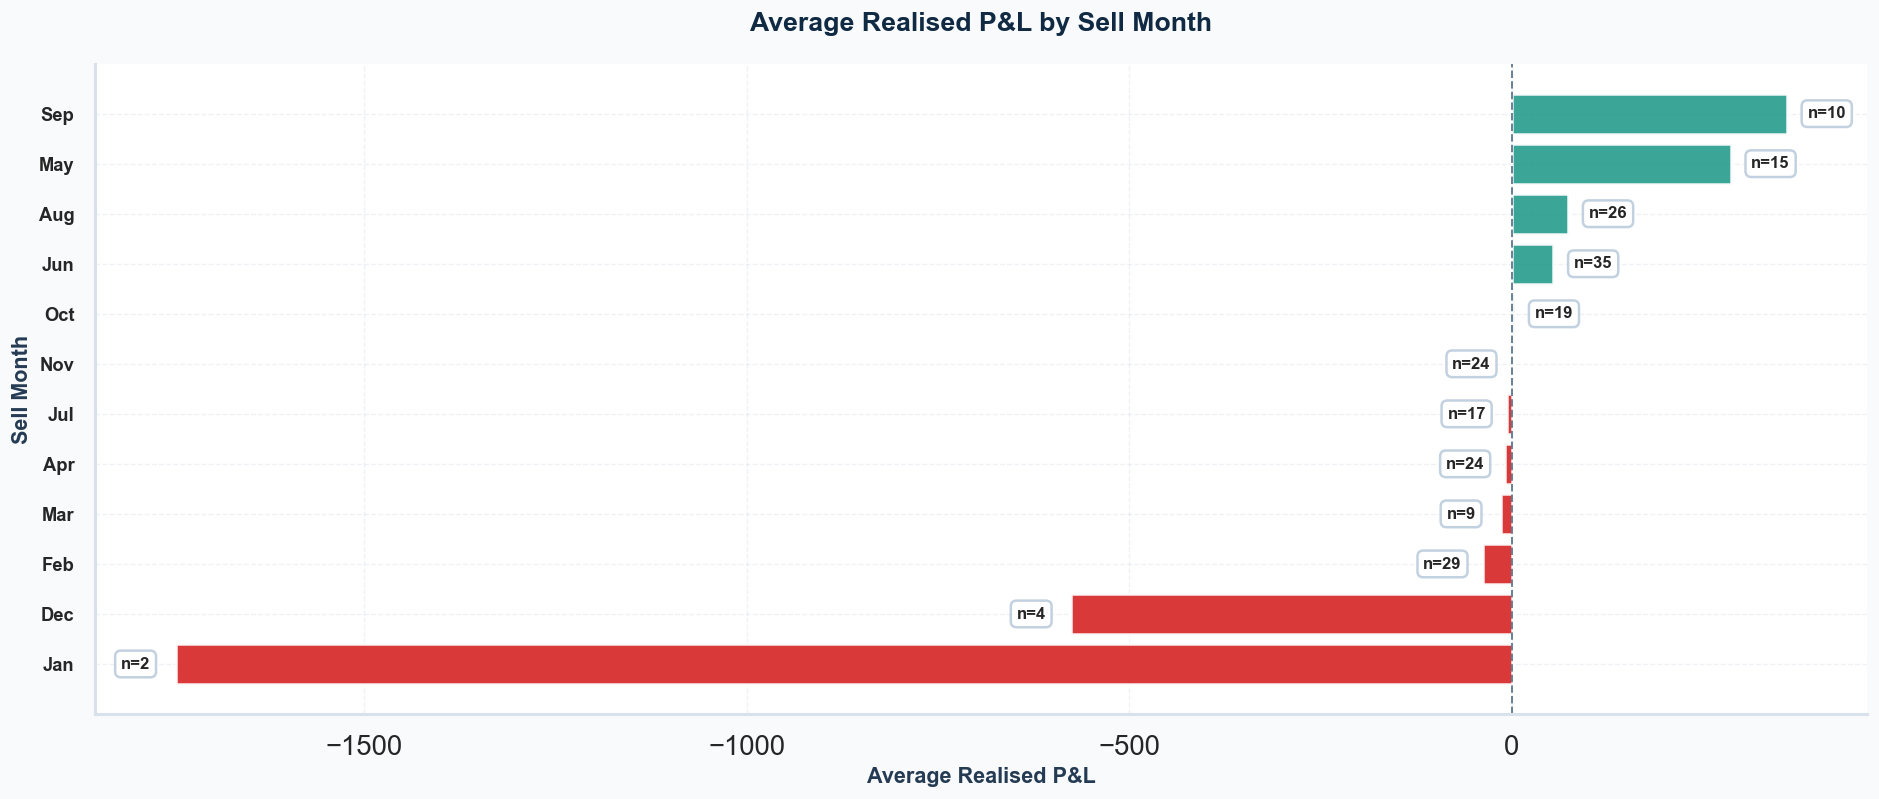

Saved plot: Figures\15_Average Realised P&L by Sell Day of Week.png


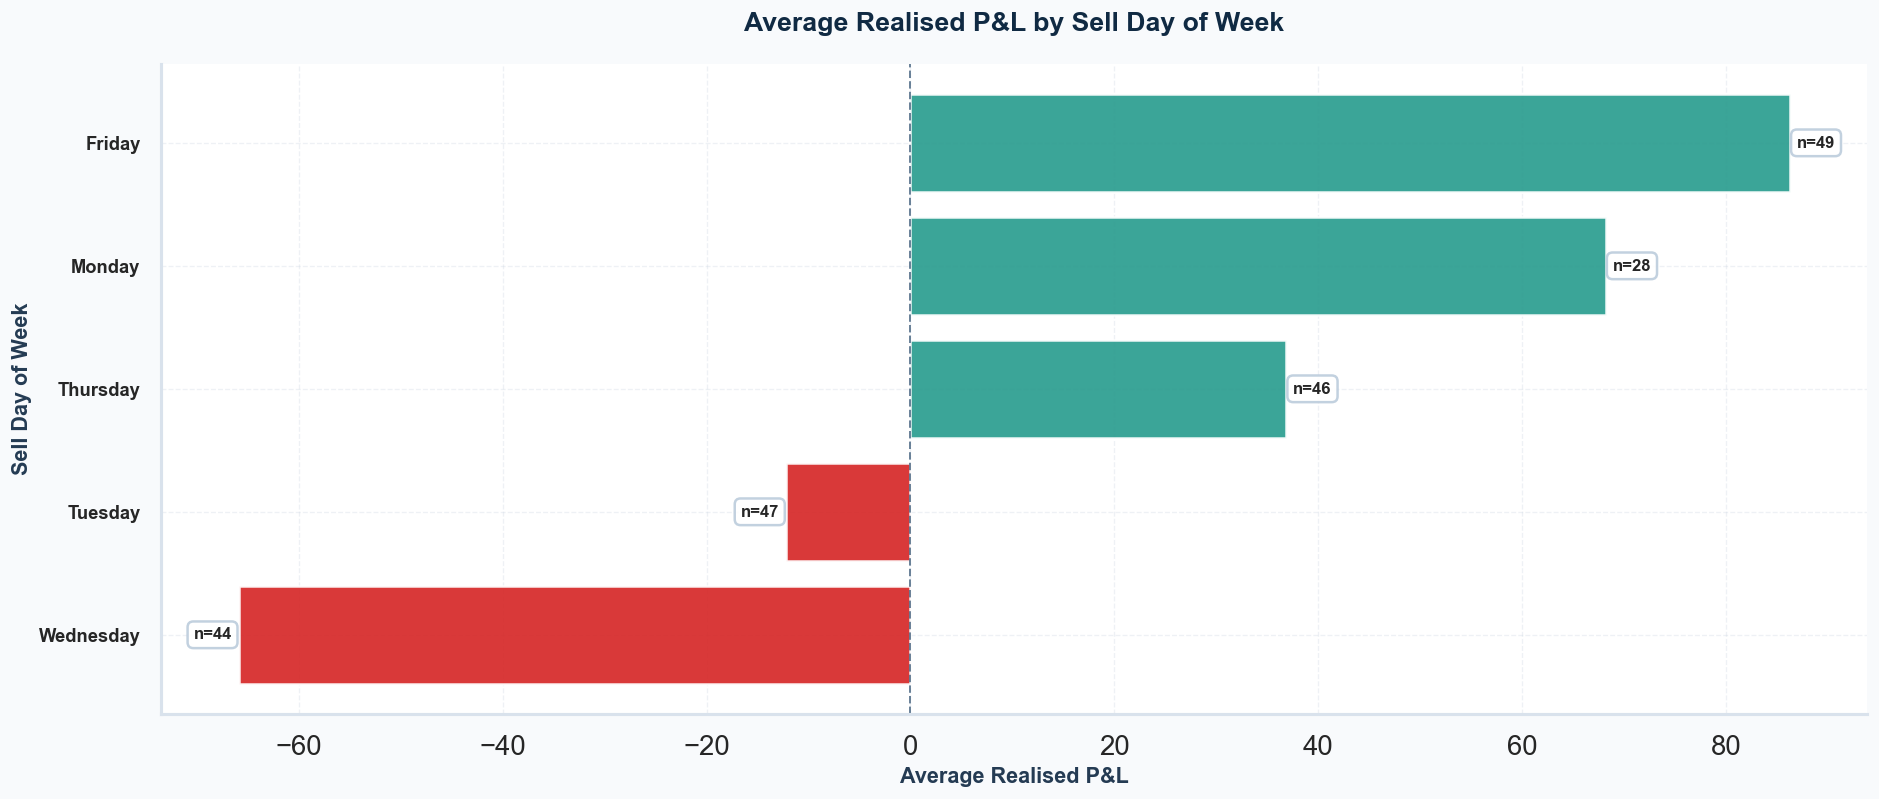

Saved plot: Figures\16_Average Realised P&L by Buy Interval.png


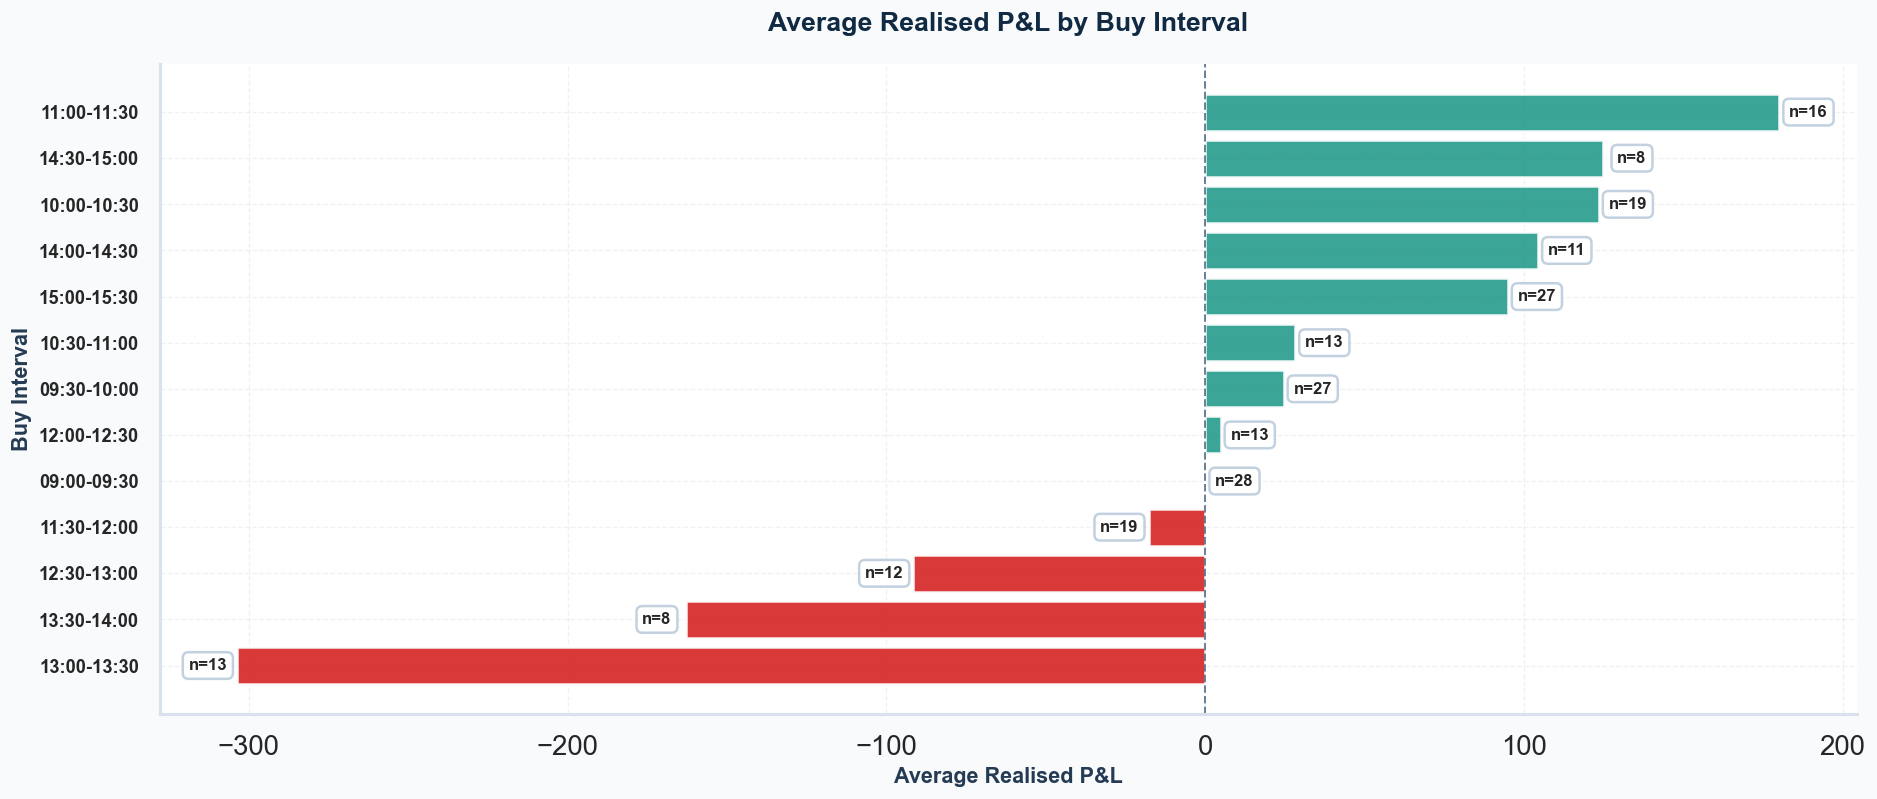

Saved plot: Figures\17_Average Realised P&L by Sell Interval.png


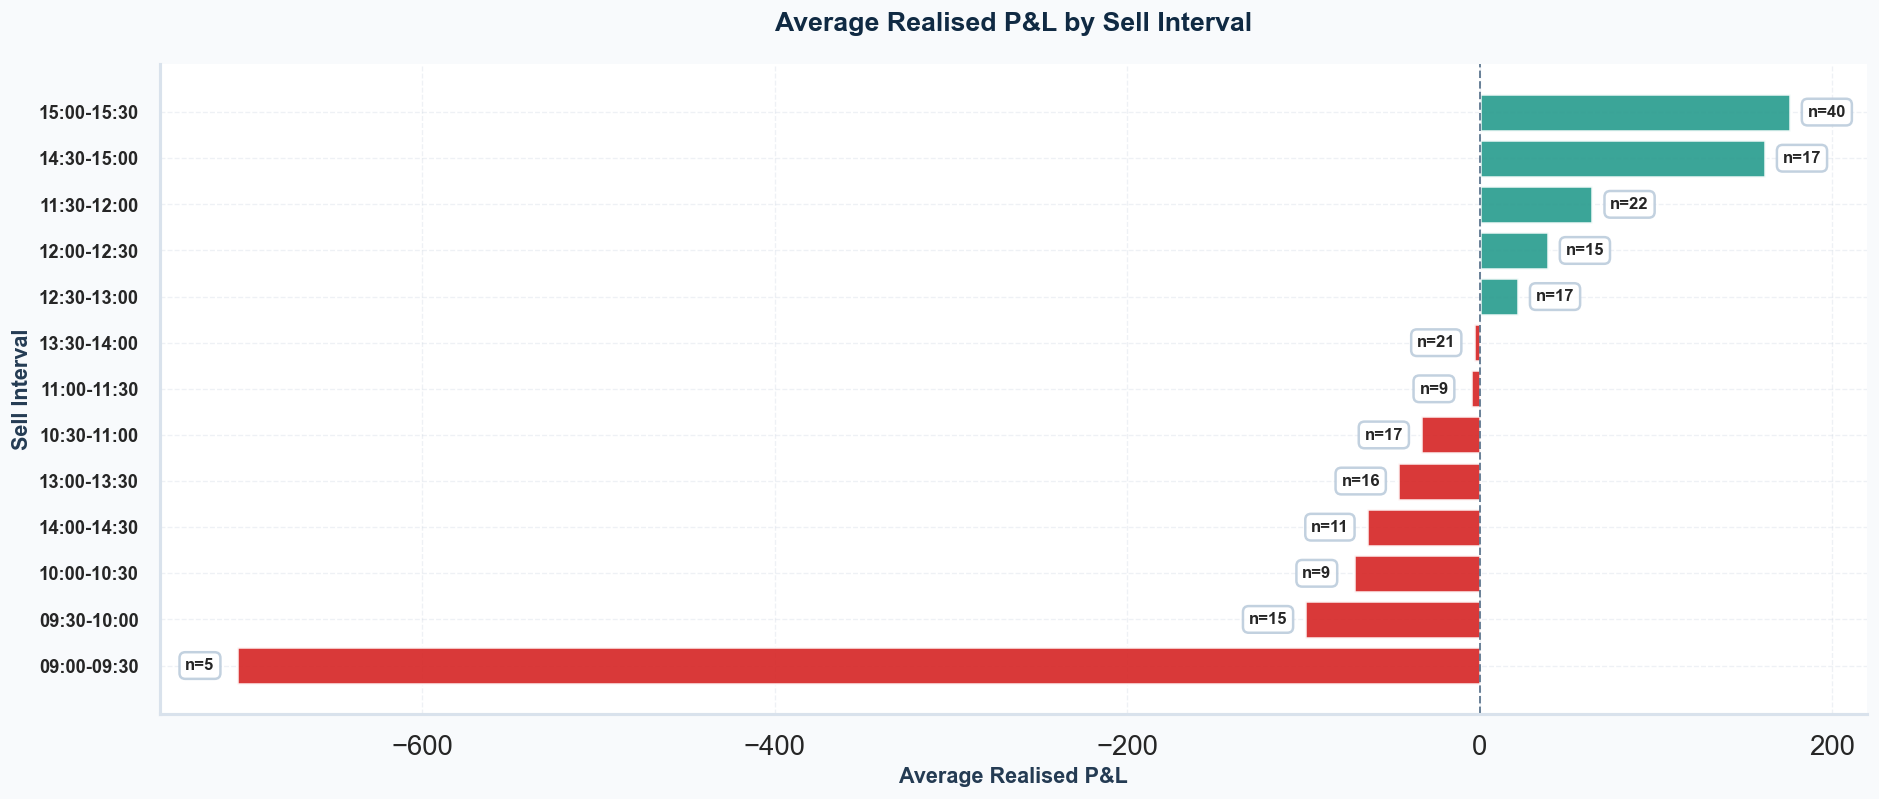

Saved plot: Figures\18_Average Realised P&L by Buy Month-Year.png


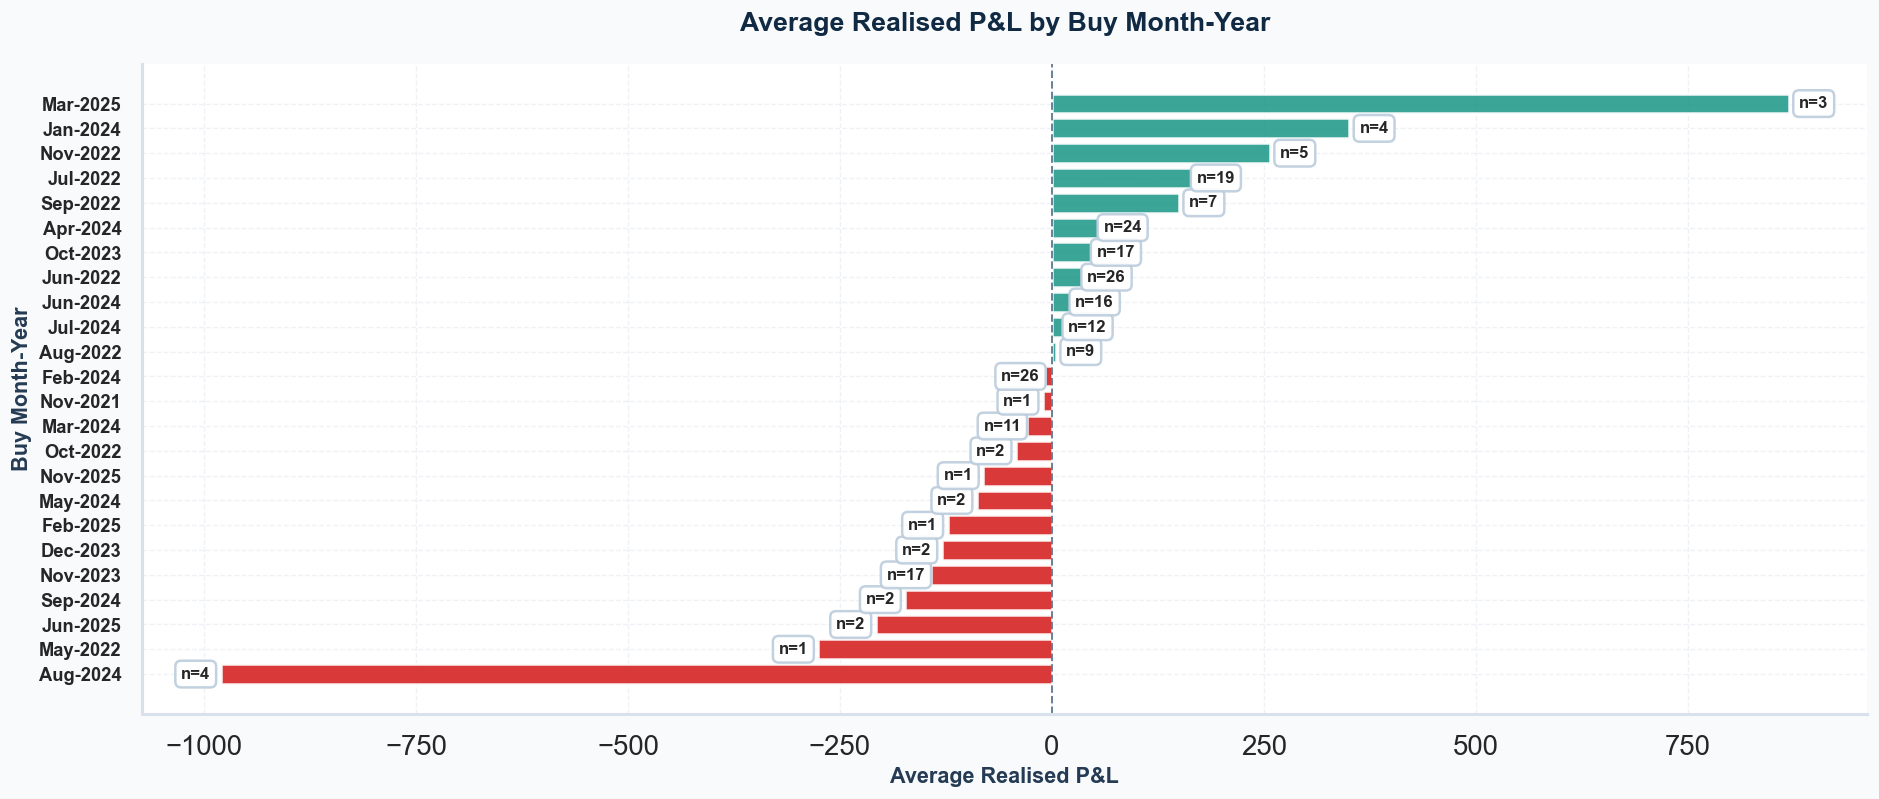

Saved plot: Figures\19_Average Realised P&L by Sell Month-Year.png


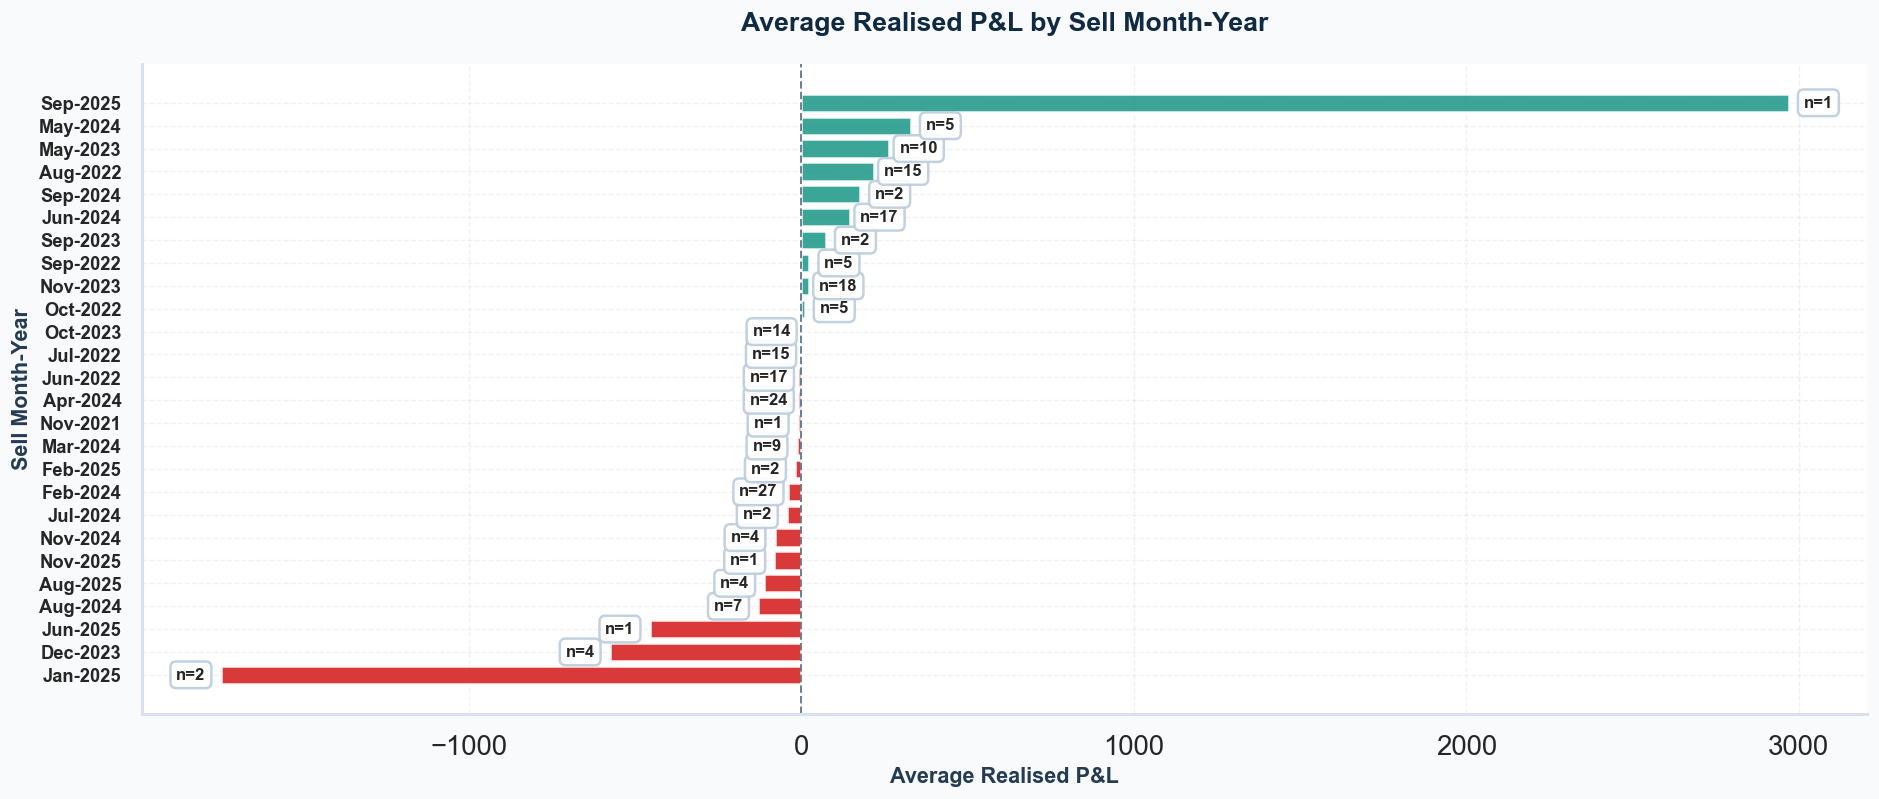

In [790]:
categorical_cols_order = [
    'Remark', 'Buy Time', 'Symbol', 'Sector', 'Industry',
    'Buy Month', 'Buy Day of Week', 'Sell Month', 'Sell Day of Week',
    'Buy Interval', 'Sell Interval', 'Buy Month-Year', 'Sell Month-Year'
]
target = 'Realised P&L'

available_cols = [col for col in categorical_cols_order if col in pnl.columns]

if target not in pnl.columns:
    print("Target column 'Realised P&L' not found - skipping plots.")
else:
    for col in available_cols:
        plot_df = pnl.copy()
        plot_df[col] = plot_df[col].fillna('Missing')

        if col == 'Buy Time':
            fig, axes = plt.subplots(1, 2, figsize=(22, 7))

            for idx, time_col in enumerate(['Buy Time', 'Sell Time']):
                if time_col not in plot_df.columns:
                    continue

                pnl_time = plot_df.copy()
                pnl_time[f'{time_col}_Hour'] = pd.to_datetime(
                    pnl_time[time_col], format='%H:%M:%S', errors='coerce'
                ).dt.hour
                hourly_data = pnl_time.groupby(f'{time_col}_Hour', dropna=False)[target].agg(['mean', 'count']).reset_index()
                hourly_data = hourly_data.dropna(subset=[f'{time_col}_Hour']).sort_values(f'{time_col}_Hour')

                colors = ['#2a9d8f' if x >= 0 else '#d62828' for x in hourly_data['mean']]
                axes[idx].bar(hourly_data[f'{time_col}_Hour'], hourly_data['mean'],
                              color=colors, alpha=0.92, edgecolor='white', linewidth=1.6)
                axes[idx].set_title(f"Average {target} by {time_col} (Hourly)", fontsize=15, fontweight='bold', pad=15)
                axes[idx].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
                axes[idx].set_ylabel(f'Average {target}', fontsize=12, fontweight='bold')
                axes[idx].axhline(y=0, color='#486581', linestyle='--', linewidth=1.2, alpha=0.8)
                axes[idx].set_xticks(hourly_data[f'{time_col}_Hour'])
                polish_axes(axes[idx])

                y_span = max(abs(hourly_data['mean']).max(), 1)
                for _, row in hourly_data.iterrows():
                    offset = y_span * 0.06 if row['mean'] >= 0 else -y_span * 0.06
                    axes[idx].text(
                        row[f'{time_col}_Hour'], row['mean'] + offset, f"n={int(row['count'])}",
                        ha='center', va='center', fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#bcccdc', alpha=0.9)
                    )

            fig.suptitle("Average Realised P&L by Buy and Sell Times", fontsize=18, fontweight='bold', y=1.02)
            plt.tight_layout()
            save_plot("Avg Realised PnL by B and S Times", fig)
            plt.show()
            continue

        elif col == 'Symbol':
            fig, ax = plt.subplots(figsize=(16, 9))
            stats = plot_df.groupby(col, dropna=False)[target].agg(['mean', 'count']).reset_index()
            stats = stats.sort_values('mean', ascending=True)

            colors = ['#d62828' if x < 0 else '#2a9d8f' for x in stats['mean']]
            ax.barh(range(len(stats)), stats['mean'], color=colors, alpha=0.92, edgecolor='white', linewidth=1.5)
            ax.set_yticks(range(len(stats)))
            ax.set_yticklabels(stats[col], fontsize=11, fontweight='bold')
            ax.set_title(f'Average {target} by {col}', fontsize=16, fontweight='bold', pad=20)
            ax.set_xlabel(f'Average {target}', fontsize=13, fontweight='bold')
            ax.set_ylabel(col, fontsize=13, fontweight='bold')
            ax.axvline(x=0, color='#486581', linestyle='--', linewidth=1.2, alpha=0.8)
            polish_axes(ax)

            x_span = max(abs(stats['mean']).max(), 1)
            for i, (_, row) in enumerate(stats.iterrows()):
                offset = x_span * 0.03 if row['mean'] >= 0 else -x_span * 0.03
                ax.text(
                    row['mean'] + offset, i, f"n={int(row['count'])}",
                    va='center', ha='center', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#bcccdc', alpha=0.9)
                )

            plt.tight_layout()
            save_plot("Avg Realised PnL by Symbols", fig)
            plt.show()

        elif col in ['Sector', 'Industry']:
            fig, axes = plt.subplots(1, 2, figsize=(24, 9))
            stats = plot_df.groupby(col, dropna=False)[target].agg(['mean', 'sum', 'count']).reset_index()
            stats = stats.sort_values('mean', ascending=True)

            colors_mean = ['#2a9d8f' if x >= 0 else '#d62828' for x in stats['mean']]
            axes[0].barh(range(len(stats)), stats['mean'], color=colors_mean, alpha=0.92, edgecolor='white', linewidth=1.5)
            axes[0].set_yticks(range(len(stats)))
            axes[0].set_yticklabels(stats[col], fontsize=11, fontweight='bold')
            axes[0].set_title(f'Average {target} by {col}', fontsize=15, fontweight='bold', pad=15)
            axes[0].set_xlabel(f'Average {target}', fontsize=12, fontweight='bold')
            axes[0].axvline(x=0, color='#486581', linestyle='--', linewidth=1.2, alpha=0.8)
            polish_axes(axes[0])

            mean_span = max(abs(stats['mean']).max(), 1)
            for i, (_, row) in enumerate(stats.iterrows()):
                offset = mean_span * 0.04 if row['mean'] >= 0 else -mean_span * 0.04
                axes[0].text(
                    row['mean'] + offset, i, f"n={int(row['count'])}",
                    va='center', ha='center', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#bcccdc', alpha=0.9)
                )

            colors_total = ['#2a9d8f' if x >= 0 else '#d62828' for x in stats['sum']]
            axes[1].barh(range(len(stats)), stats['sum'], color=colors_total, alpha=0.92, edgecolor='white', linewidth=1.5)
            axes[1].set_yticks(range(len(stats)))
            axes[1].set_yticklabels(stats[col], fontsize=11, fontweight='bold')
            axes[1].set_title(f'Total {target} by {col}', fontsize=15, fontweight='bold', pad=15)
            axes[1].set_xlabel(f'Total {target}', fontsize=12, fontweight='bold')
            axes[1].axvline(x=0, color='#486581', linestyle='--', linewidth=1.2, alpha=0.8)
            polish_axes(axes[1])

            total_span = max(abs(stats['sum']).max(), 1)
            for i, (_, row) in enumerate(stats.iterrows()):
                offset = total_span * 0.03 if row['sum'] >= 0 else -total_span * 0.03
                axes[1].text(
                    row['sum'] + offset, i, f"n={int(row['count'])}",
                    va='center', ha='center', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#bcccdc', alpha=0.9)
                )

            plt.tight_layout()
            save_name = 'Avg and Total Realised PnL by Sectors' if col == 'Sector' else 'Avg and Total Realised PnL by Industries'
            save_plot(save_name, fig)
            plt.show()

        elif col == 'Remark':
            fig, ax = plt.subplots(figsize=(9, 7))
            stats = plot_df.groupby(col, dropna=False)[target].agg(['mean', 'count']).reset_index()
            stats = stats.sort_values('mean', ascending=False)

            colors = ['#2a9d8f' if x >= 0 else '#d62828' for x in stats['mean']]
            ax.bar(range(len(stats)), stats['mean'], color=colors, alpha=0.92, edgecolor='white', linewidth=1.5)
            ax.set_xticks(range(len(stats)))
            ax.set_xticklabels(stats[col], fontsize=10, rotation=45, ha='right')
            ax.set_title(f'Average {target} by {col}', fontsize=16, fontweight='bold', pad=20)
            ax.set_ylabel(f'Average {target}', fontsize=13, fontweight='bold')
            ax.set_xlabel(col, fontsize=13, fontweight='bold')
            ax.axhline(y=0, color='#486581', linestyle='--', linewidth=1.2, alpha=0.8)
            polish_axes(ax)

            y_span = max(abs(stats['mean']).max(), 1)
            for i, (_, row) in enumerate(stats.iterrows()):
                offset = y_span * 0.06 if row['mean'] >= 0 else -y_span * 0.06
                ax.text(
                    i, row['mean'] + offset, f"n={int(row['count'])}",
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#bcccdc', alpha=0.9)
                )

            plt.tight_layout()
            save_plot("Avg Realised PnL by Remarks", fig)
            plt.show()

        else:
            fig, ax = plt.subplots(figsize=(16, 7))
            stats = plot_df.groupby(col, dropna=False)[target].agg(['mean', 'count']).reset_index()
            stats = stats.sort_values('mean', ascending=True)

            colors = ['#d62828' if x < 0 else '#2a9d8f' for x in stats['mean']]
            ax.barh(range(len(stats)), stats['mean'], color=colors, alpha=0.92, edgecolor='white', linewidth=1.5)
            ax.set_yticks(range(len(stats)))
            ax.set_yticklabels(stats[col], fontsize=11, fontweight='bold')
            ax.set_title(f'Average {target} by {col}', fontsize=16, fontweight='bold', pad=20)
            ax.set_xlabel(f'Average {target}', fontsize=13, fontweight='bold')
            ax.set_ylabel(col, fontsize=13, fontweight='bold')
            ax.axvline(x=0, color='#486581', linestyle='--', linewidth=1.2, alpha=0.8)
            polish_axes(ax)

            x_span = max(abs(stats['mean']).max(), 1)
            for i, (_, row) in enumerate(stats.iterrows()):
                offset = x_span * 0.03 if row['mean'] >= 0 else -x_span * 0.03
                ax.text(
                    row['mean'] + offset, i, f"n={int(row['count'])}",
                    va='center', ha='center', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#bcccdc', alpha=0.9)
                )

            plt.tight_layout()
            save_plot(f"Average Realised P&L by {col}", fig)
            plt.show()


-----------Plots between Categorical vs Categorical features

Saved plot: Figures\20_Relationship between Buy Month and Sell Month.png


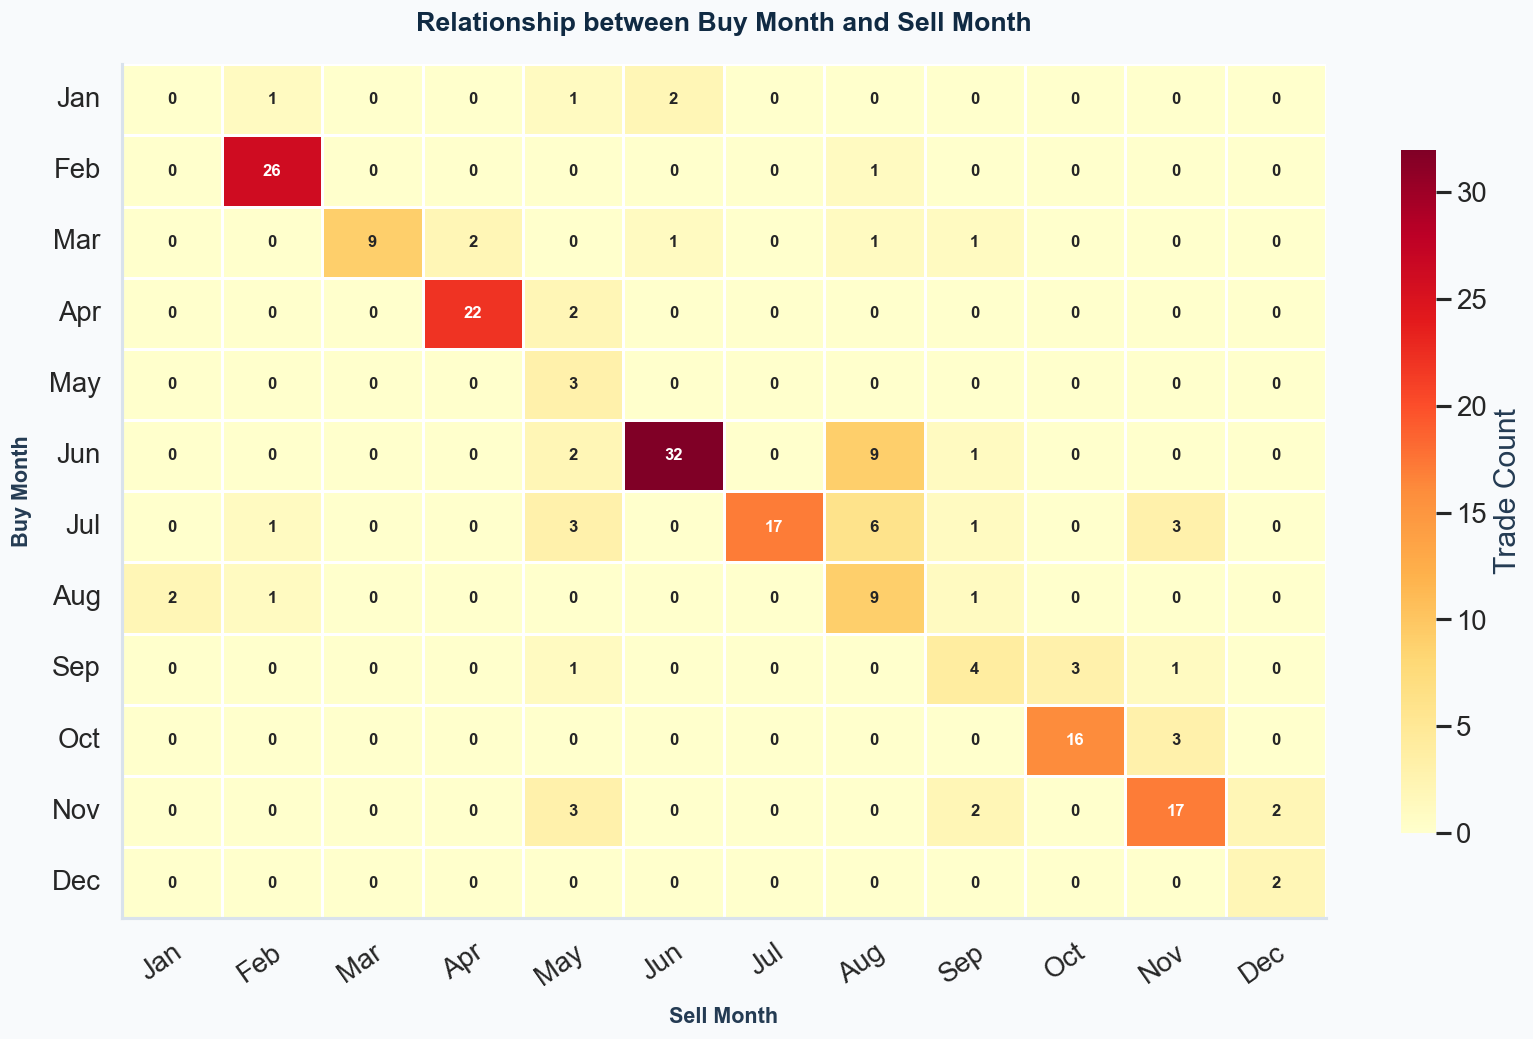

Saved plot: Figures\21_Relationship between Buy Month and Sector.png


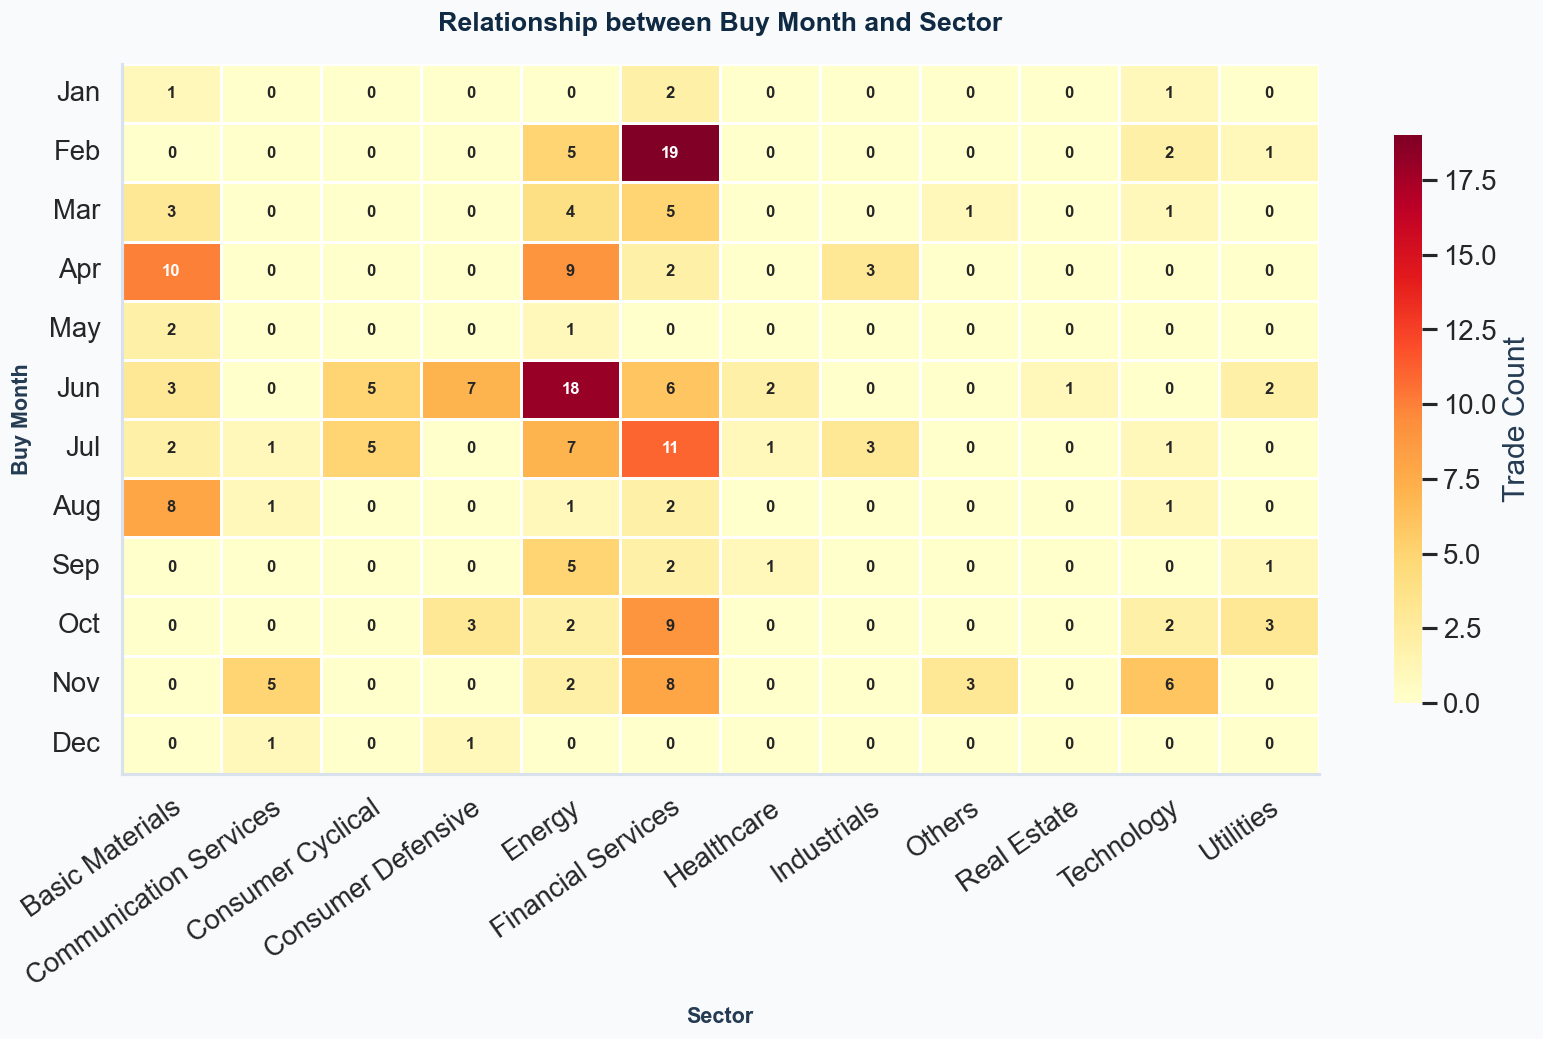

Saved plot: Figures\22_Relationship between Sell Month and Sector.png


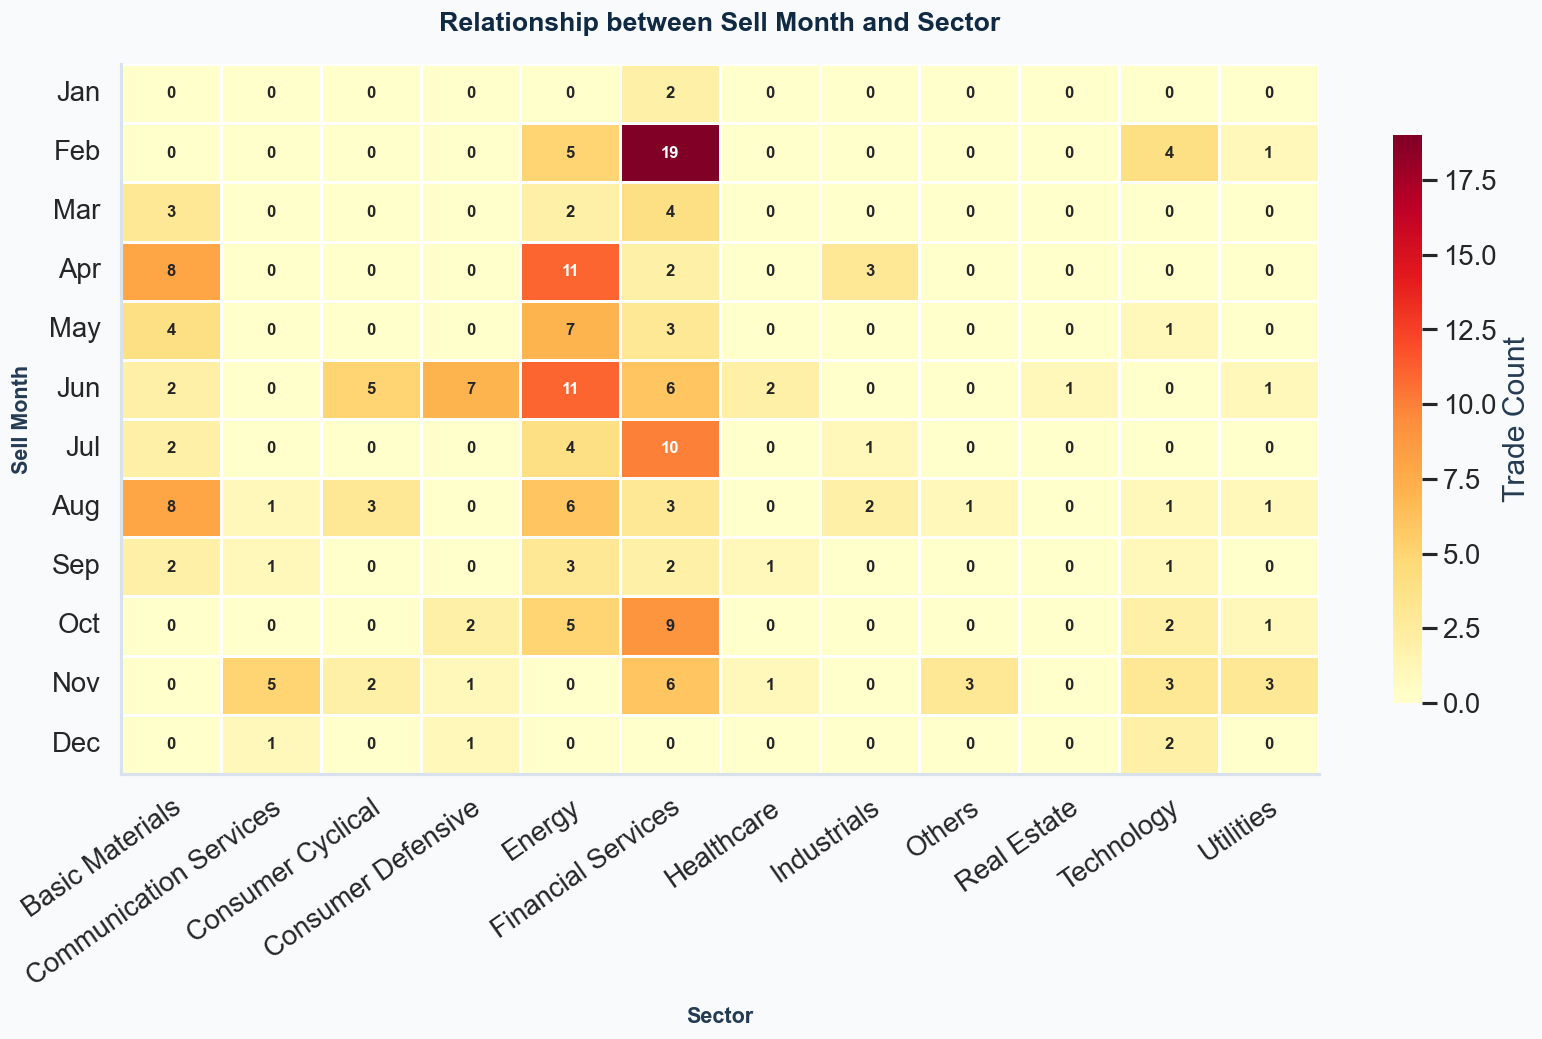

Saved plot: Figures\23_Relationship between Remark and Sector.png


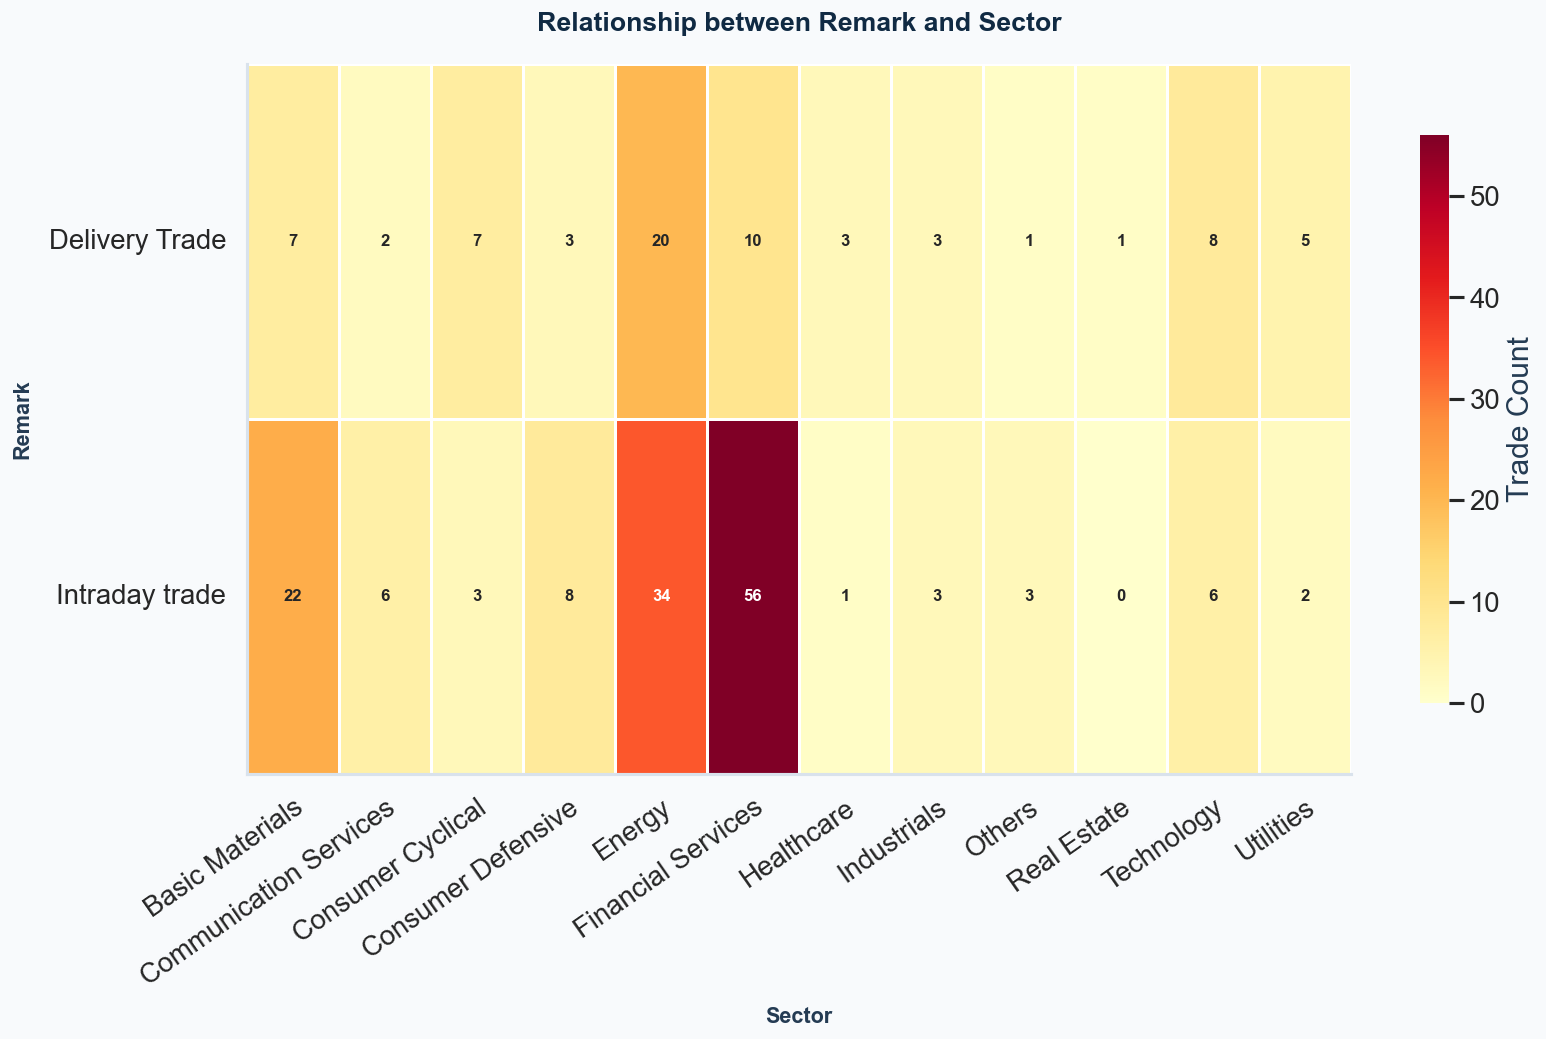

Saved plot: Figures\24_Relationship between Remark and Industry.png


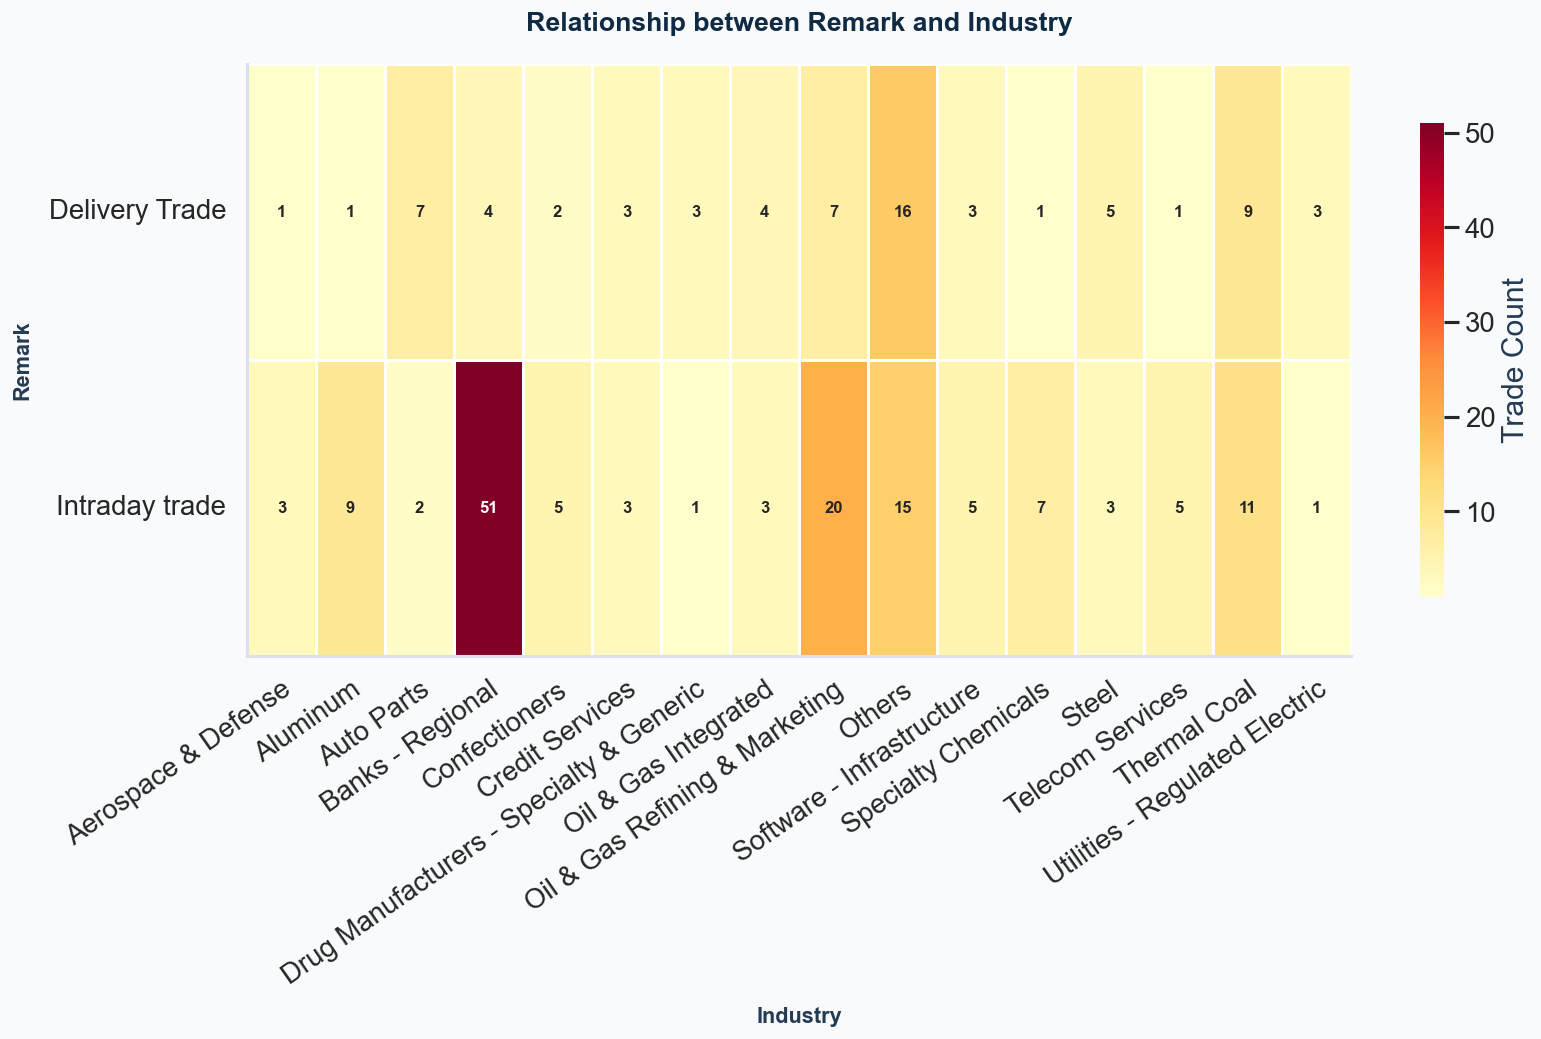

Saved plot: Figures\25_Relationship between Buy Month and Remark.png


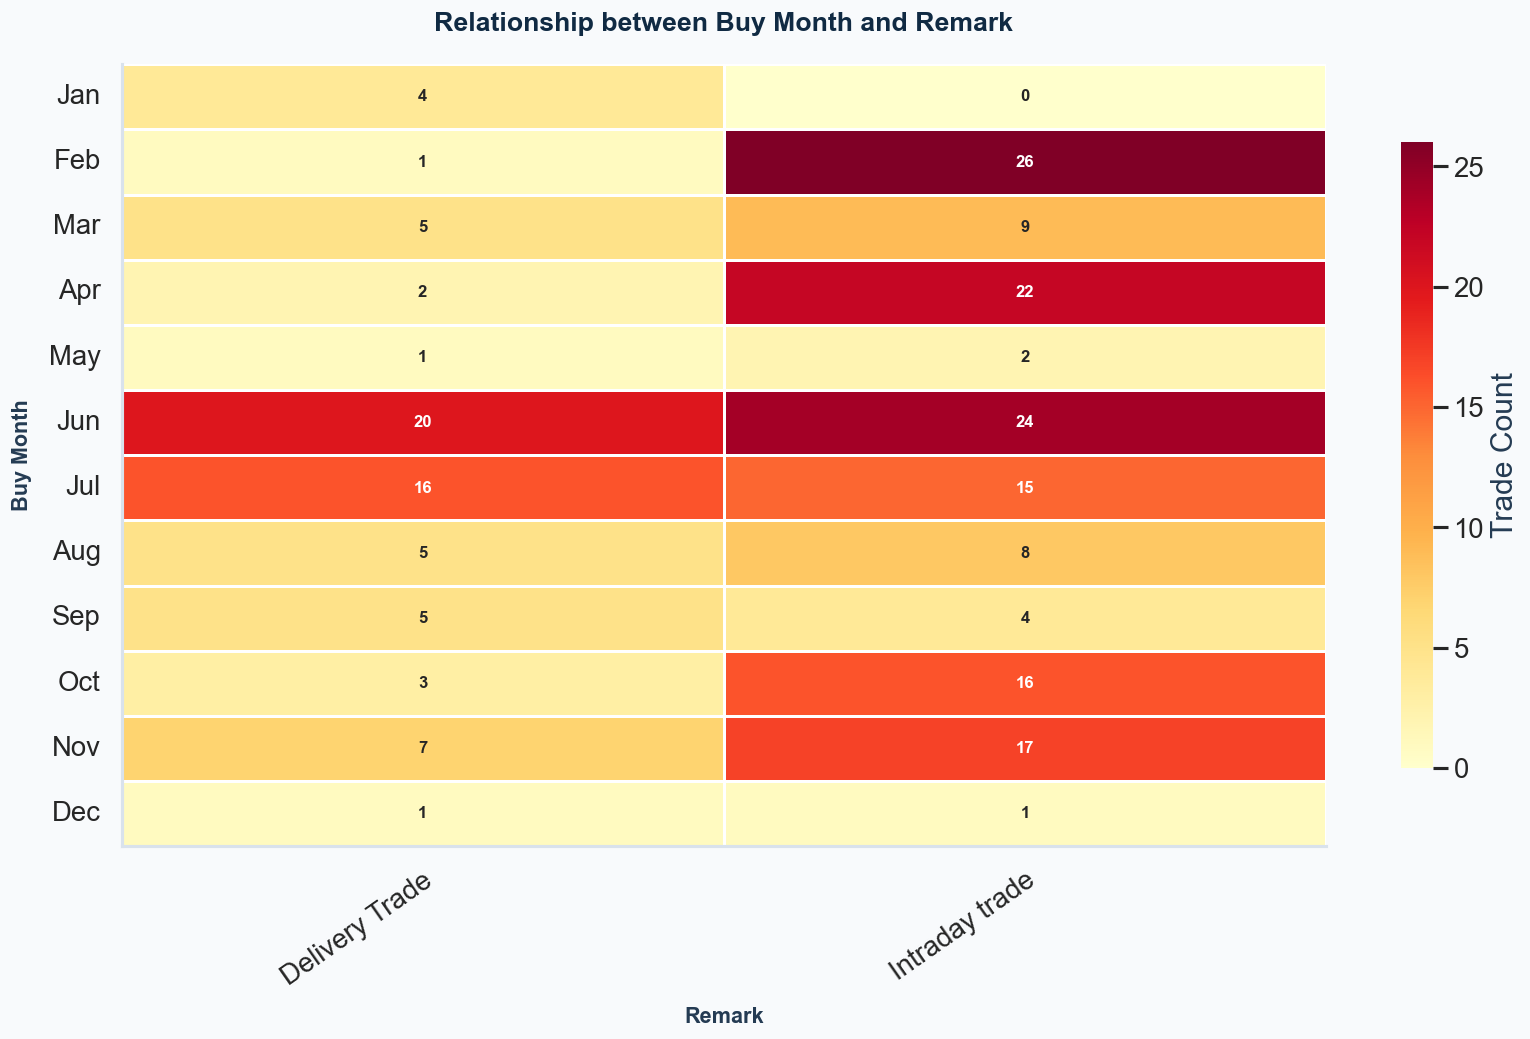

Saved plot: Figures\26_Relationship between Sell Month and Remark.png


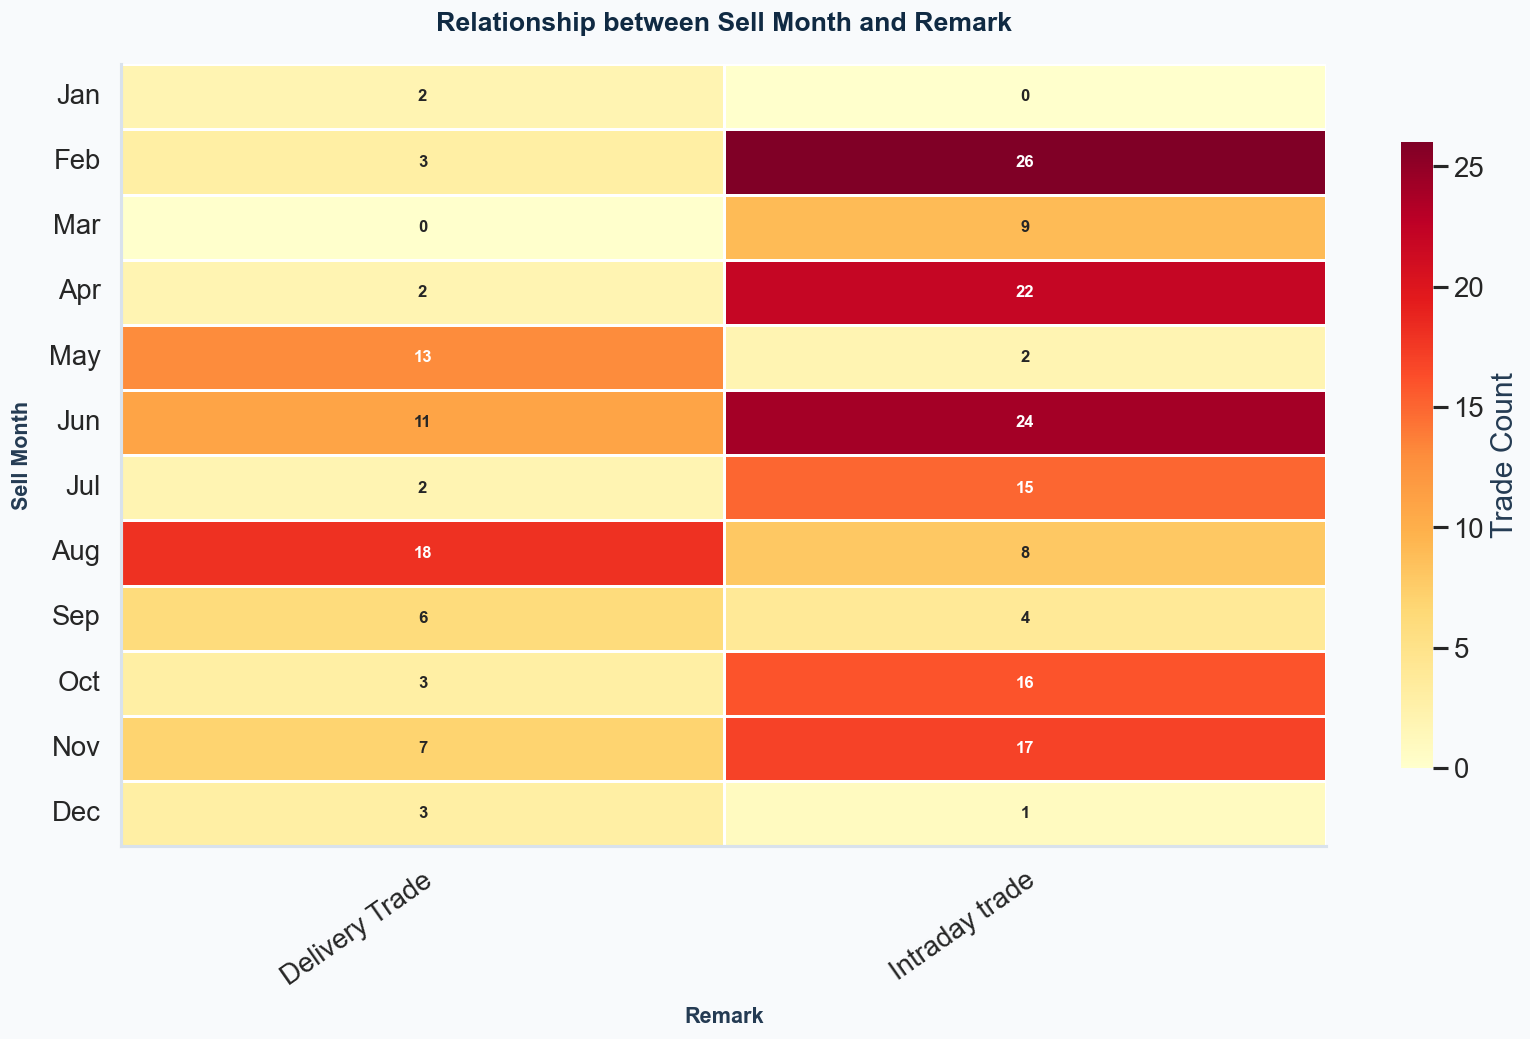

In [791]:
important_pairs = [
    ('Buy Month', 'Sell Month'),
    ('Buy Month', 'Sector'),
    ('Sell Month', 'Sector'),
    ('Remark', 'Sector'),
    ('Remark', 'Industry'),
    ('Buy Month', 'Remark'),
    ('Sell Month', 'Remark')
]

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for col1, col2 in important_pairs:
    if col1 in pnl.columns and col2 in pnl.columns:
        if pnl[col1].nunique() <= 20 and pnl[col2].nunique() <= 20:
            if col1 in ['Buy Month', 'Sell Month']:
                pnl_temp = pnl[pnl[col1].isin(month_order)].copy()
                pnl_temp[col1] = pd.Categorical(pnl_temp[col1], categories=month_order, ordered=True)
            else:
                pnl_temp = pnl.copy()
                pnl_temp[col1] = pnl_temp[col1].fillna('Missing')

            if col2 in ['Buy Month', 'Sell Month']:
                pnl_temp = pnl_temp[pnl_temp[col2].isin(month_order)].copy()
                pnl_temp[col2] = pd.Categorical(pnl_temp[col2], categories=month_order, ordered=True)
            else:
                pnl_temp[col2] = pnl_temp[col2].fillna('Missing')

            cross_tab = pd.crosstab(pnl_temp[col1], pnl_temp[col2])
            fig, ax = plt.subplots(figsize=(14, 9))

            sns.heatmap(
                cross_tab,
                cmap='YlOrRd',
                annot=True,
                fmt='d',
                linewidths=1.5,
                linecolor='white',
                cbar_kws={'label': 'Trade Count', 'shrink': 0.8},
                annot_kws={'fontsize': 10, 'fontweight': 'bold'},
                ax=ax
            )

            title = f"Relationship between {col1} and {col2}"
            ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
            ax.set_xlabel(col2, fontsize=13, fontweight='bold', labelpad=10)
            ax.set_ylabel(col1, fontsize=13, fontweight='bold', labelpad=10)
            polish_axes(ax, rotate_x=35)
            plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')

            plt.tight_layout()
            save_plot(title, fig)
            plt.show()


--------- These plots...

we can also use the Pandas Profiller to apply the EDA to the User Trade History dataset

In [792]:
from ydata_profiling import ProfileReport

profile = ProfileReport(pnl, title="User Trade History Analysis")
profile.to_file("User Trade History Analysis.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 34/34 [00:00<?, ?it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [793]:
pnl.info()
print("\nValue Counts for Each Column:\n")

for col in pnl.columns:
    print(f"--- {col} ---")
    print(pnl[col].value_counts(dropna=False))  # include NaN counts
    print("\n")

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 224
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Stock name         214 non-null    object 
 1   ISIN               214 non-null    object 
 2   Quantity           214 non-null    int64  
 3   Buy date           214 non-null    object 
 4   Buy price          214 non-null    float64
 5   Buy value          214 non-null    float64
 6   Sell date          214 non-null    object 
 7   Sell price         214 non-null    float64
 8   Sell value         214 non-null    float64
 9   Realised P&L       214 non-null    float64
 10  Remark             214 non-null    object 
 11  Buy Time           214 non-null    object 
 12  Sell Time          214 non-null    object 
 13  Symbol             214 non-null    object 
 14  Sector             214 non-null    object 
 15  Industry           214 non-null    object 
 16  Buy Year           214 non-null

# Feature Engineering

1. Feature Construction (Manually)

Since the realised profit and loss is not calculating the charges, taxes and brokerages paid by the user to the Broker and Exchange so we will be calculating them. 

In [794]:
# --- Base Values ---
buy_val = pnl['Buy value']
sell_val = pnl['Sell value']
turnover = buy_val + sell_val  # total trade value

# --- Brokerage (0.05% or ₹20 per executed order whichever is lower, both sides combined) ---
pnl['Brokerage'] = (turnover * 0.0005).clip(upper=40)  # Max ₹20 per side (40 total for buy+sell)

# --- Exchange Transaction Charges (NSE EQ: 0.00345%, BSE EQ: ~0.00297%) ---
pnl['Exchange Charges'] = turnover * 0.0000297

# --- SEBI Fees (₹10 per crore) ---
pnl['SEBI Charges'] = turnover * 0.000001

# --- IPF (Investor Protection Fund) ---
pnl['Investor Protection Fund'] = turnover * 0.000001

# --- Initialize other columns ---
pnl['STT'] = 0.0
pnl['Stamp Duty'] = 0.0
pnl['Demat Charges'] = 0.0

# --- Intraday Trades ---
mask_intraday = pnl['Remark'].str.contains('Intraday', case=False, na=False)
pnl.loc[mask_intraday, 'STT'] = sell_val * 0.00025
pnl.loc[mask_intraday, 'Stamp Duty'] = buy_val * 0.00003
pnl.loc[mask_intraday, 'Demat Charges'] = 0.0

# --- Delivery Trades ---
mask_delivery = ~mask_intraday & ~pnl['Remark'].str.contains('IPO', case=False, na=False)
pnl.loc[mask_delivery, 'STT'] = sell_val * 0.001
pnl.loc[mask_delivery, 'Stamp Duty'] = buy_val * 0.00015
pnl.loc[mask_delivery, 'Demat Charges'] = 13.5 * 1.18  # apply GST directly (13.5 + 18%)

# --- IPO Trades ---
mask_ipo = pnl['Remark'].str.contains('IPO', case=False, na=False)
pnl.loc[mask_ipo, 'STT'] = sell_val * 0.001
pnl.loc[mask_ipo, 'Stamp Duty'] = 0.0
pnl.loc[mask_ipo, 'Exchange Charges'] = sell_val * 0.0000297
pnl.loc[mask_ipo, 'SEBI Charges'] = sell_val * 0.000001
pnl.loc[mask_ipo, 'Investor Protection Fund'] = sell_val * 0.000001
pnl.loc[mask_ipo, 'Demat Charges'] = 13.5 * 1.18

# --- GST (18%) ---
# Apply only on Brokerage + Exchange Charges (per GST Act)
pnl['GST'] = (pnl['Brokerage'] + pnl['Exchange Charges']) * 0.18

# --- Total Charges (Sum Everything) ---
pnl['Total Charges'] = (
    pnl['Brokerage'] +
    pnl['Exchange Charges'] +
    pnl['SEBI Charges'] +
    pnl['Investor Protection Fund'] +
    pnl['STT'] +
    pnl['Stamp Duty'] +
    pnl['Demat Charges'] +
    pnl['GST']
).round(2)

pnl['Total Charges'].sum().round(2)

np.float64(3416.16)

Now, let's find the Gross and Net pnl and pnl % to better understand the profits and losses. This will give the idea of overall profits user generates. 

In [795]:
# Calculating the Gross and Net pnl and pnl %
pnl['Gross Realised P&L'] = pnl['Sell value'] - pnl['Buy value']
pnl['Gross Realised PnL %'] = (pnl['Gross Realised P&L'] / pnl['Buy value']) * 100
pnl['Net Realised P&L'] = pnl['Gross Realised P&L'] - pnl['Total Charges']
pnl['Net Realised PnL %'] = (pnl['Net Realised P&L'] / pnl['Buy value']) * 100
pnl = pnl.drop(columns= 'Realised P&L')

Now, let's find the holding period to understand the user's preference and find the most profitable holding period for the user.

In [796]:
# Ensure both date columns are proper datetime objects
pnl['Buy date'] = pd.to_datetime(pnl['Buy date'], errors='coerce')
pnl['Sell date'] = pd.to_datetime(pnl['Sell date'], errors='coerce')

# Now safely calculate holding period
pnl['Holding Period (Days)'] = (pnl['Sell date'] - pnl['Buy date']).dt.days

2. Feature Transformation

Merging the Industry and Sector rows which are not appearing frequently

In [797]:
uncommon_industry = pnl['Industry'].value_counts() 
pnl['Industry'] = pnl['Industry'].replace(uncommon_industry[uncommon_industry < 6].index, 'Others')

uncommon_Sector = pnl['Sector'].value_counts() 
pnl['Sector'] = pnl['Sector'].replace(uncommon_Sector[uncommon_Sector <= 5].index, 'Others')

pnl['Industry'].value_counts()
pnl['Sector'].value_counts()

Sector
Financial Services        66
Energy                    54
Basic Materials           29
Technology                14
Consumer Defensive        11
Consumer Cyclical         10
Others                     9
Communication Services     8
Utilities                  7
Industrials                6
Name: count, dtype: int64

Creating additional ratio features (useful for ML insights)  

In [798]:
pnl['PnL per Trade Value'] = pnl['Net Realised P&L'] / (pnl['Buy value'] + pnl['Sell value'])
pnl['Buy/Sell Price Ratio'] = pnl['Buy price'] / pnl['Sell price']

# Replace infinite or NaN values with 0
pnl = pnl.replace([np.inf, -np.inf], np.nan).fillna(0)

3. Feature Selection and Encoding 

In [799]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Step 1: Reinitialize encoders with proper settings
ss = StandardScaler()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Step 2: Remove target and leakage columns
X = pnl[
    [
        'Quantity',
        'Buy price',
        'Remark',
        'Sector',
        'Industry',
        'Buy Month',
        'Buy Day',
        'Buy Day of Week',
        'Sell Month',
        'Sell Day',
        'Sell Day of Week',
        'Buy Time Minutes',
        'Sell Time Minutes',
        'Total Charges',
        'Holding Period (Days)',
        'Buy/Sell Price Ratio'
    ]
]

y = pnl['Net Realised P&L']

# Step 3: Check which columns actually exist in X
print("Available columns in X:")
print(X.columns.tolist())

Available columns in X:
['Quantity', 'Buy price', 'Remark', 'Sector', 'Industry', 'Buy Month', 'Buy Day', 'Buy Day of Week', 'Sell Month', 'Sell Day', 'Sell Day of Week', 'Buy Time Minutes', 'Sell Time Minutes', 'Total Charges', 'Holding Period (Days)', 'Buy/Sell Price Ratio']


Now, let's do the train test split the data to apply the scaling and encoding to the train split and apply that same transformation to the test split. Let's encode and scale the features before applying the ML Models 

In [800]:
from sklearn.model_selection import train_test_split

# Defining the numerical, ordinal and categorical cols
numerical_cols = [
    'Quantity',
    'Buy price',
    'Buy Time Minutes',
    'Sell Time Minutes',
    'Total Charges',
    'Holding Period (Days)',
    'Buy/Sell Price Ratio'
]

ordinal_cols = [
    'Buy Month',
    'Buy Day',
    'Buy Day of Week',
    'Sell Month',
    'Sell Day',
    'Sell Day of Week'
]

categorical_cols = [
    'Remark',
    'Sector',
    'Industry'
]

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Ordinal columns ({len(ordinal_cols)}): {ordinal_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numerical columns (7): ['Quantity', 'Buy price', 'Buy Time Minutes', 'Sell Time Minutes', 'Total Charges', 'Holding Period (Days)', 'Buy/Sell Price Ratio']
Ordinal columns (6): ['Buy Month', 'Buy Day', 'Buy Day of Week', 'Sell Month', 'Sell Day', 'Sell Day of Week']
Categorical columns (3): ['Remark', 'Sector', 'Industry']


In [801]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=17)

trfs = [
    ('ohe', ohe, categorical_cols),
    ('oe', oe, ordinal_cols),
    ('ss', ss, numerical_cols)
]

ct = ColumnTransformer(transformers=trfs, remainder='passthrough', verbose_feature_names_out=False)

X_train_trf = ct.fit_transform(X_train)
X_test_trf = ct.transform(X_test)

X_train_trf = pd.DataFrame(X_train_trf, columns=ct.get_feature_names_out())
X_test_trf = pd.DataFrame(X_test_trf, columns=ct.get_feature_names_out())

# Machine Learning

Now, we will apply the ML models to perform the SHAP Analysis in the dataset and find the hidden patterns

In [802]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap
import joblib

models = {
    'Ridge': Ridge(alpha=0.1),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=177771, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=1000, max_depth=5, random_state=177771),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.28, random_state=177771, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=1000, max_depth=6, learning_rate=0.1, random_state=177771, n_jobs=-1, verbose=-1)
}

results = []
trained_models = {}

print("="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

for name, model in models.items():
    model.fit(X_train_trf, y_train)
    y_pred = model.predict(X_test_trf)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred) / np.where(y_test.values != 0, y_test.values, 1))) * 100
    
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n", results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_r2 = results_df.iloc[0]['R²']

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name} (R² = {best_r2:.4f})")
print(f"{'='*80}")

MODEL TRAINING AND EVALUATION

             Model       RMSE        MAE       R²        MAPE
Gradient Boosting  53.439189  28.852025 0.960569  241.564386
          XGBoost  55.190057  28.929510 0.957943  148.663556
    Random Forest  98.074292  41.873490 0.867192  214.639072
         LightGBM 152.645086  84.928420 0.678280  772.452276
            Lasso 184.653092 133.427993 0.529212 4773.056972
            Ridge 184.773390 133.139511 0.528598 4740.536075

BEST MODEL: Gradient Boosting (R² = 0.9606)


Saved plot: Figures\27_Actual vs Predicted Model Comparison.png


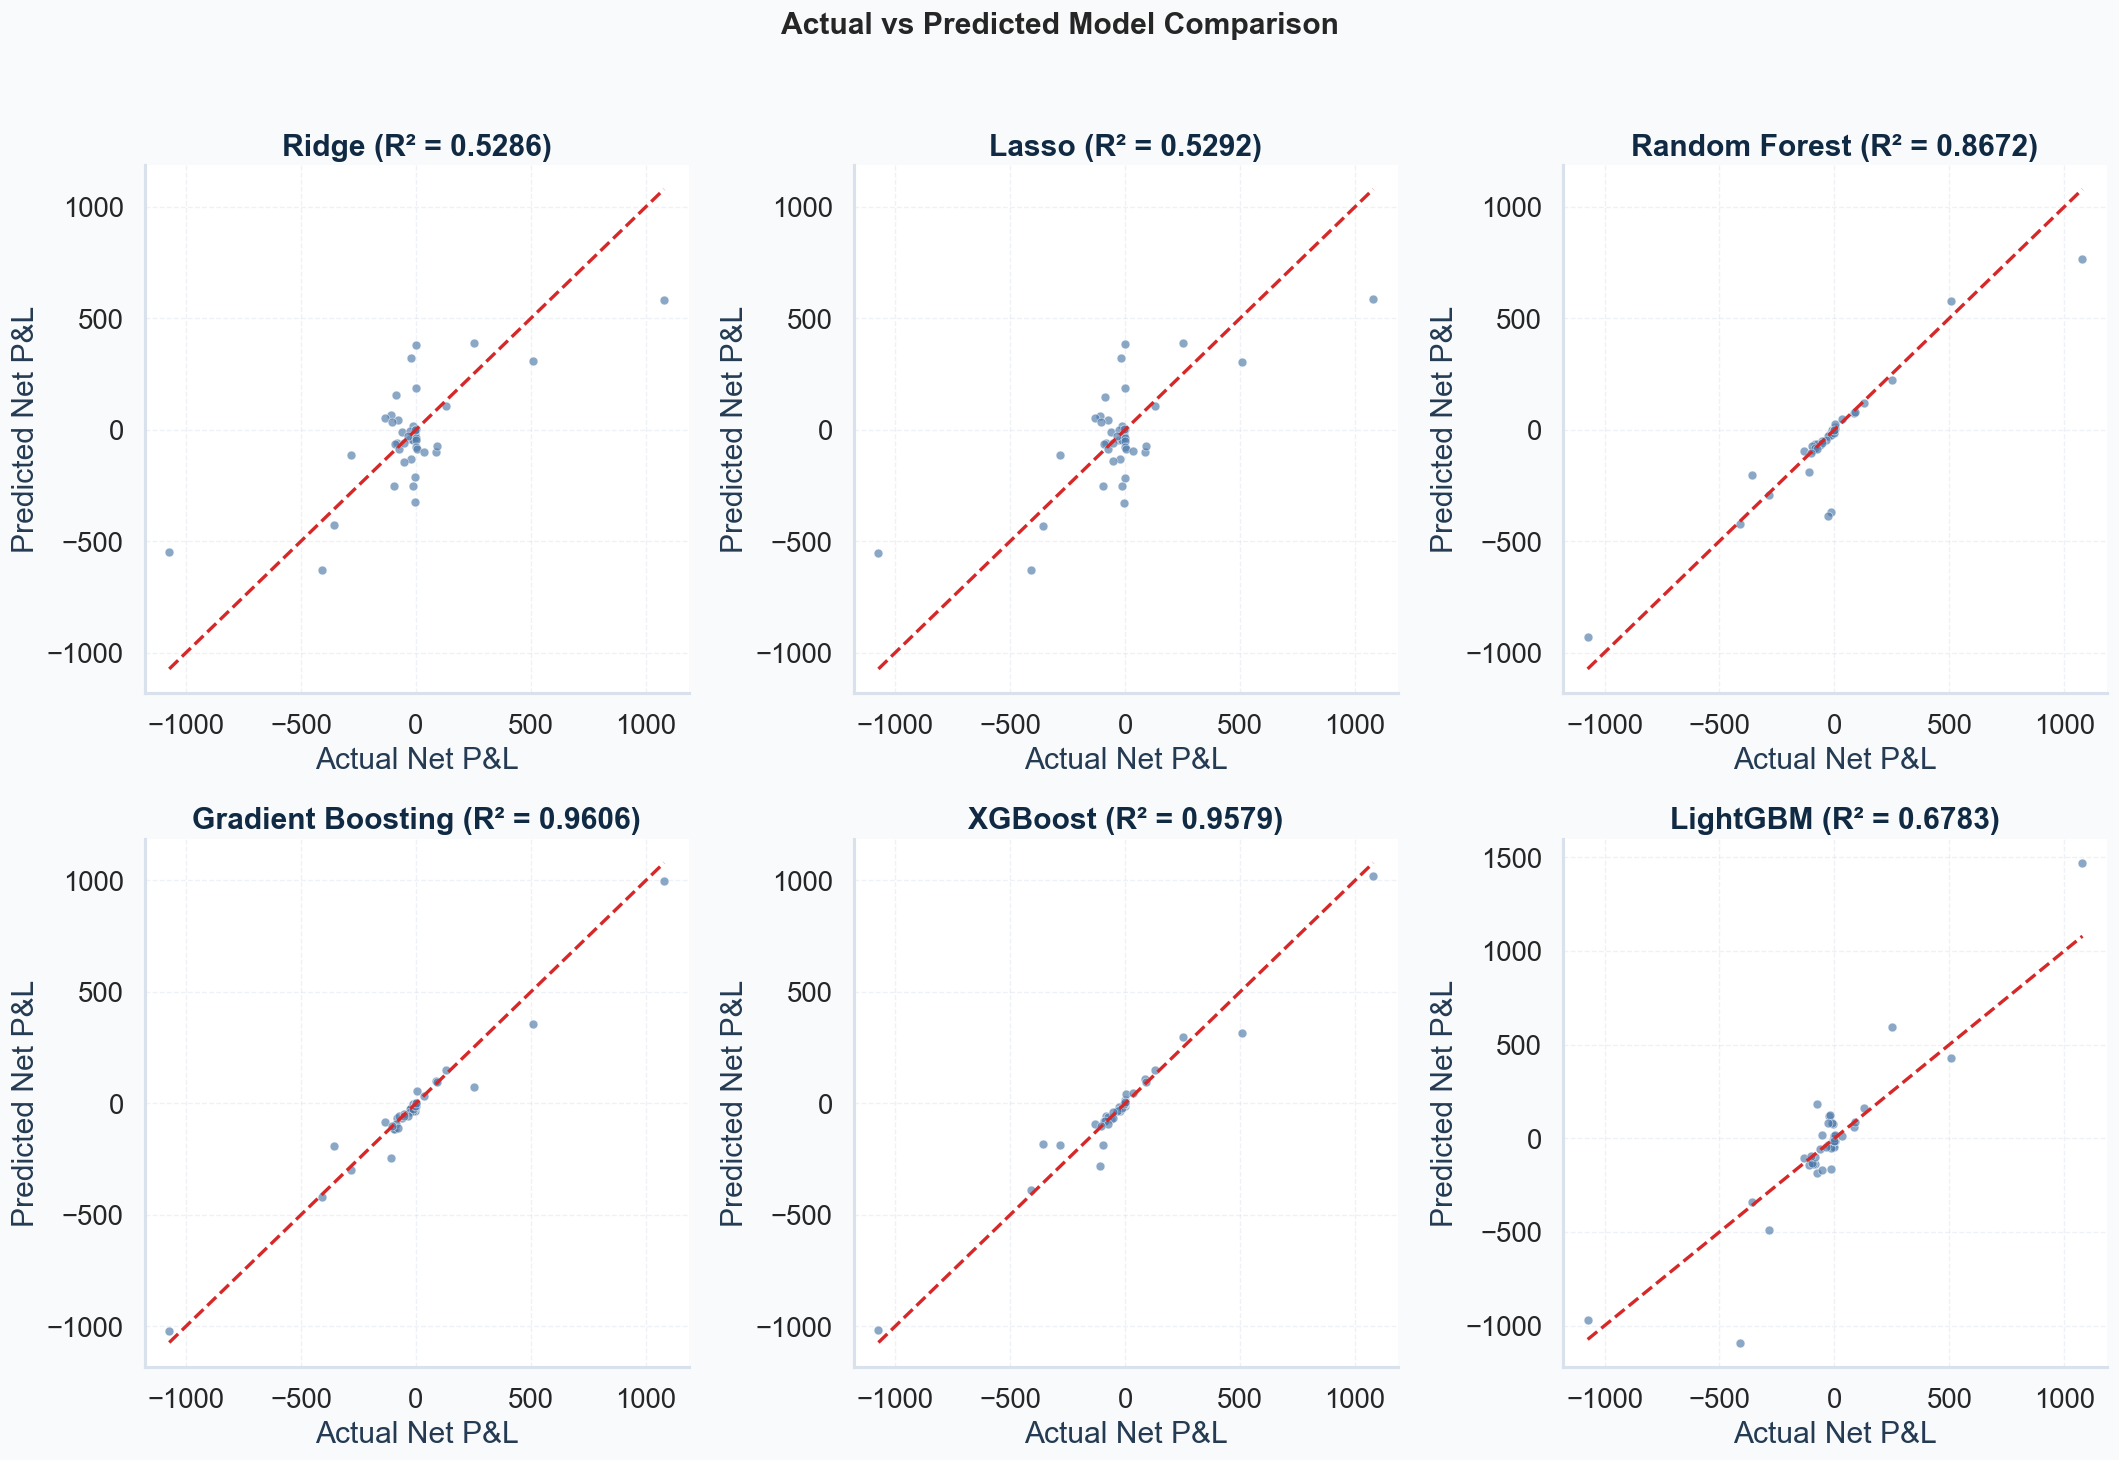

In [803]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_trf)
    r2 = r2_score(y_test, y_pred)

    axes[idx].scatter(y_test, y_pred, alpha=0.65, s=28, color='#4c78a8', edgecolor='white', linewidth=0.4)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#d62828', linestyle='--', lw=2)
    axes[idx].set_xlabel('Actual Net P&L')
    axes[idx].set_ylabel('Predicted Net P&L')
    axes[idx].set_title(f'{name} (R² = {r2:.4f})')
    polish_axes(axes[idx])

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Actual vs Predicted Model Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('Actual vs Predicted Model Comparison', fig)
plt.show()


FEATURE IMPORTANCE - Gradient Boosting

Top 20 Features:
                           Feature  Importance  Importance %
              Buy/Sell Price Ratio    0.618826     61.882609
                     Total Charges    0.323621     32.362105
                 Sell Time Minutes    0.017093      1.709282
                         Buy price    0.012292      1.229215
                          Quantity    0.008027      0.802739
                          Sell Day    0.007509      0.750905
                         Buy Month    0.002713      0.271298
                        Sell Month    0.002327      0.232741
         Industry_Banks - Regional    0.001849      0.184900
                   Buy Day of Week    0.001655      0.165542
                  Sell Day of Week    0.001082      0.108155
             Holding Period (Days)    0.000863      0.086286
                  Buy Time Minutes    0.000754      0.075414
                           Buy Day    0.000443      0.044307
         Sector_Financial S

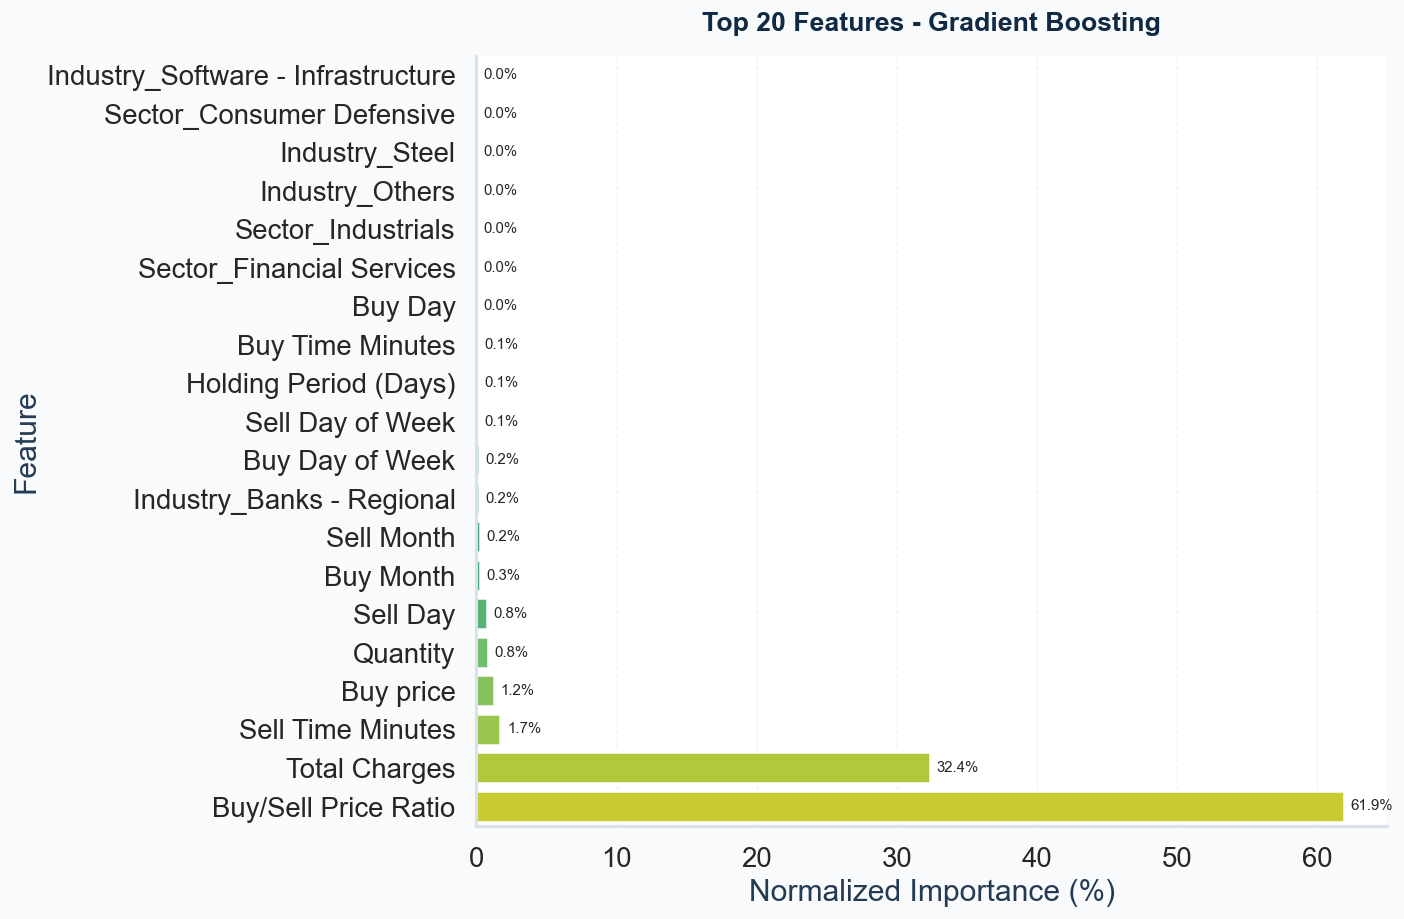

In [804]:
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']
if best_model_name in tree_models:
    print(f"\n{'='*80}")
    print(f"FEATURE IMPORTANCE - {best_model_name}")
    print(f"{'='*80}")

    feature_importance = pd.DataFrame({
        'Feature': X_train_trf.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    feature_importance['Importance %'] = 100 * feature_importance['Importance'] / feature_importance['Importance'].sum()

    print("\nTop 20 Features:")
    print(feature_importance[['Feature', 'Importance', 'Importance %']].head(20).to_string(index=False))

    top_n = 20
    plot_df = feature_importance.head(top_n).sort_values('Importance %', ascending=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=plot_df, x='Importance %', y='Feature', hue='Feature', dodge=False,
                palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Top {top_n} Features - {best_model_name}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Normalized Importance (%)')
    ax.set_ylabel('Feature')
    polish_axes(ax)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9)

    plt.tight_layout()
    save_plot(f'Feature Importance - {best_model_name}', fig)
    plt.show()



SHAP ANALYSIS

Top 20 Features by SHAP Importance:
                           Feature  Mean |SHAP|  Contribution Share (%)
              Buy/Sell Price Ratio   120.707496               65.139644
                     Total Charges    25.616306               13.823806
                          Sell Day     8.257011                4.455885
                 Sell Time Minutes     8.146806                4.396413
                         Buy price     5.559023                2.999920
                  Buy Time Minutes     4.396626                2.372634
                          Quantity     3.159723                1.705140
                   Buy Day of Week     1.570587                0.847565
             Holding Period (Days)     1.214056                0.655164
         Sector_Financial Services     0.928599                0.501117
                           Buy Day     0.893321                0.482079
                         Buy Month     0.841869                0.454313
            

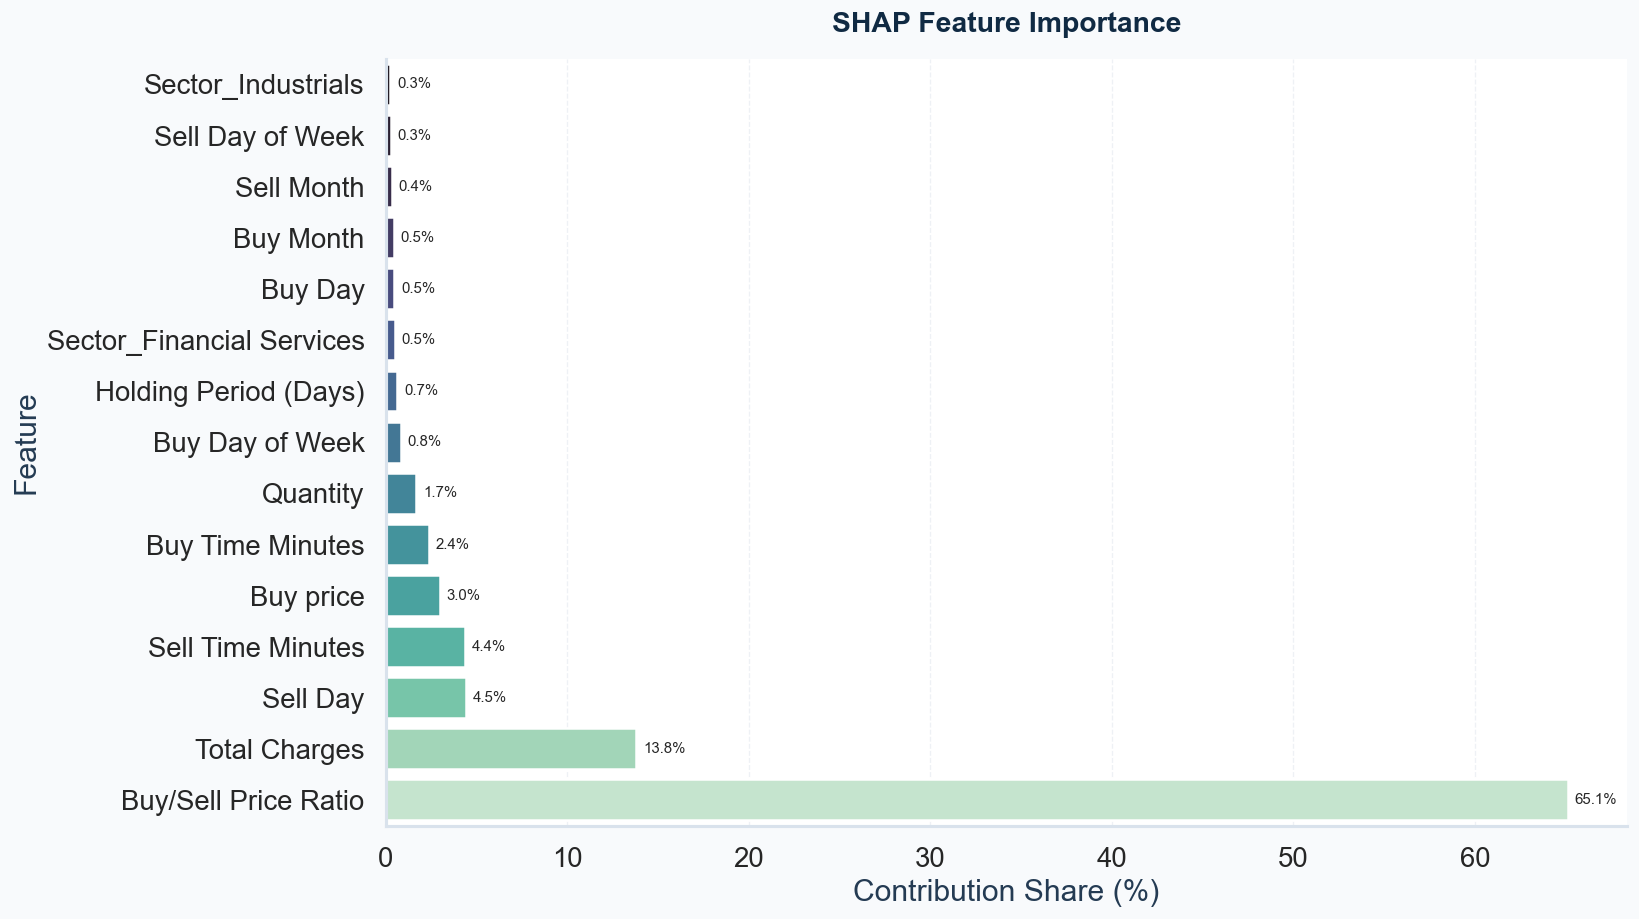

Saved plot: Figures\30_SHAP Impact Distribution.png


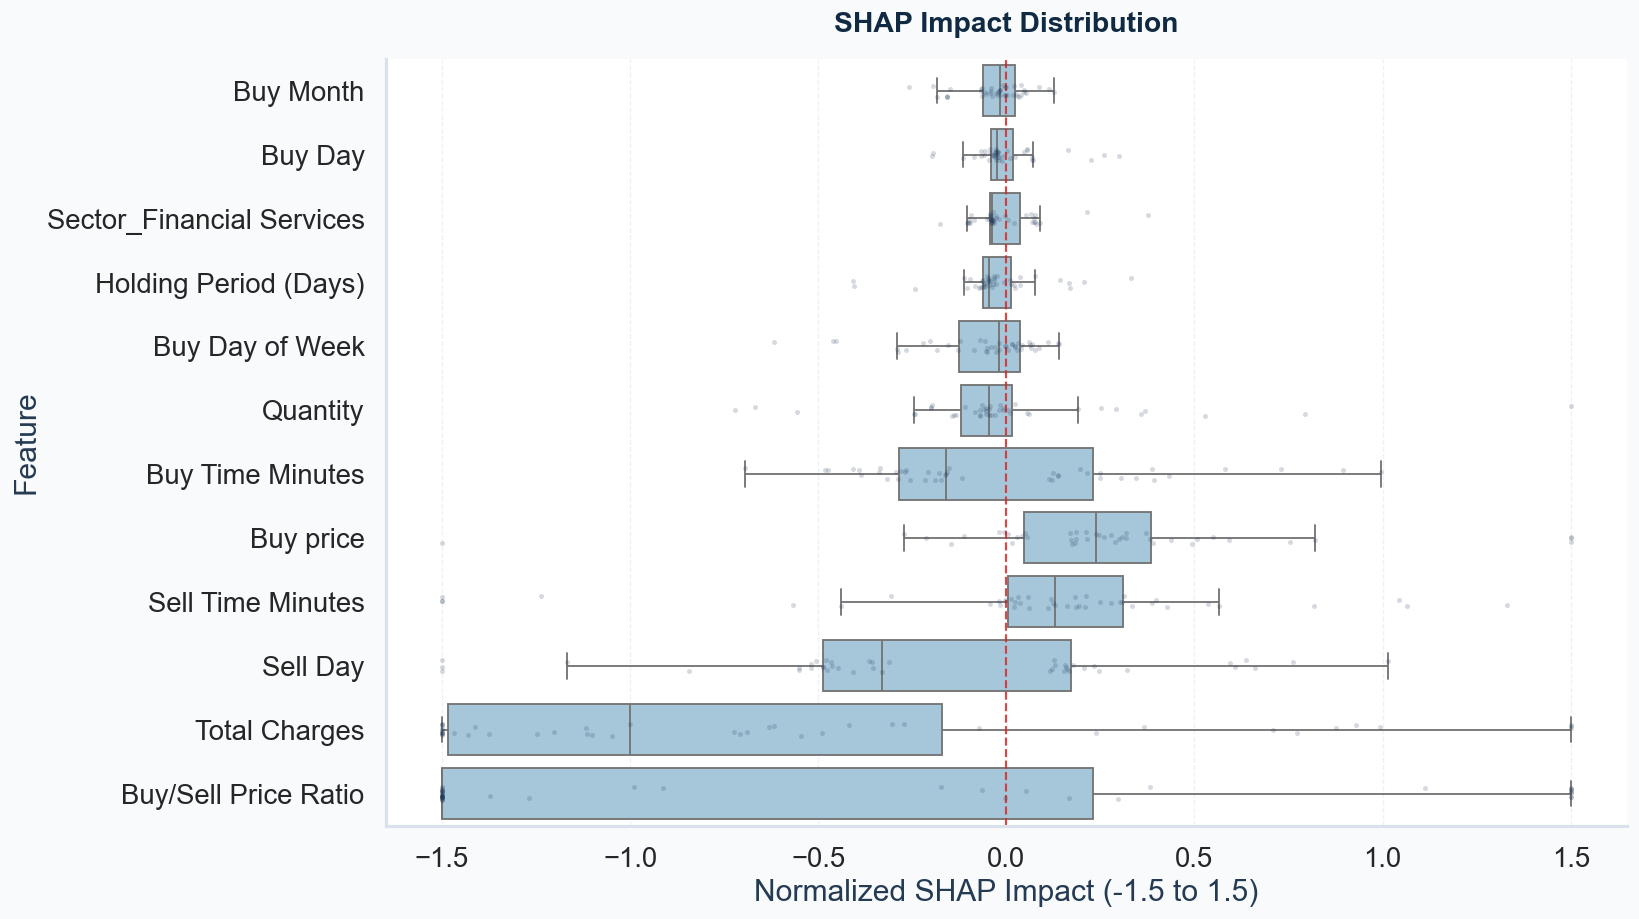

Saved plot: Figures\31_SHAP Dependence Plots.png


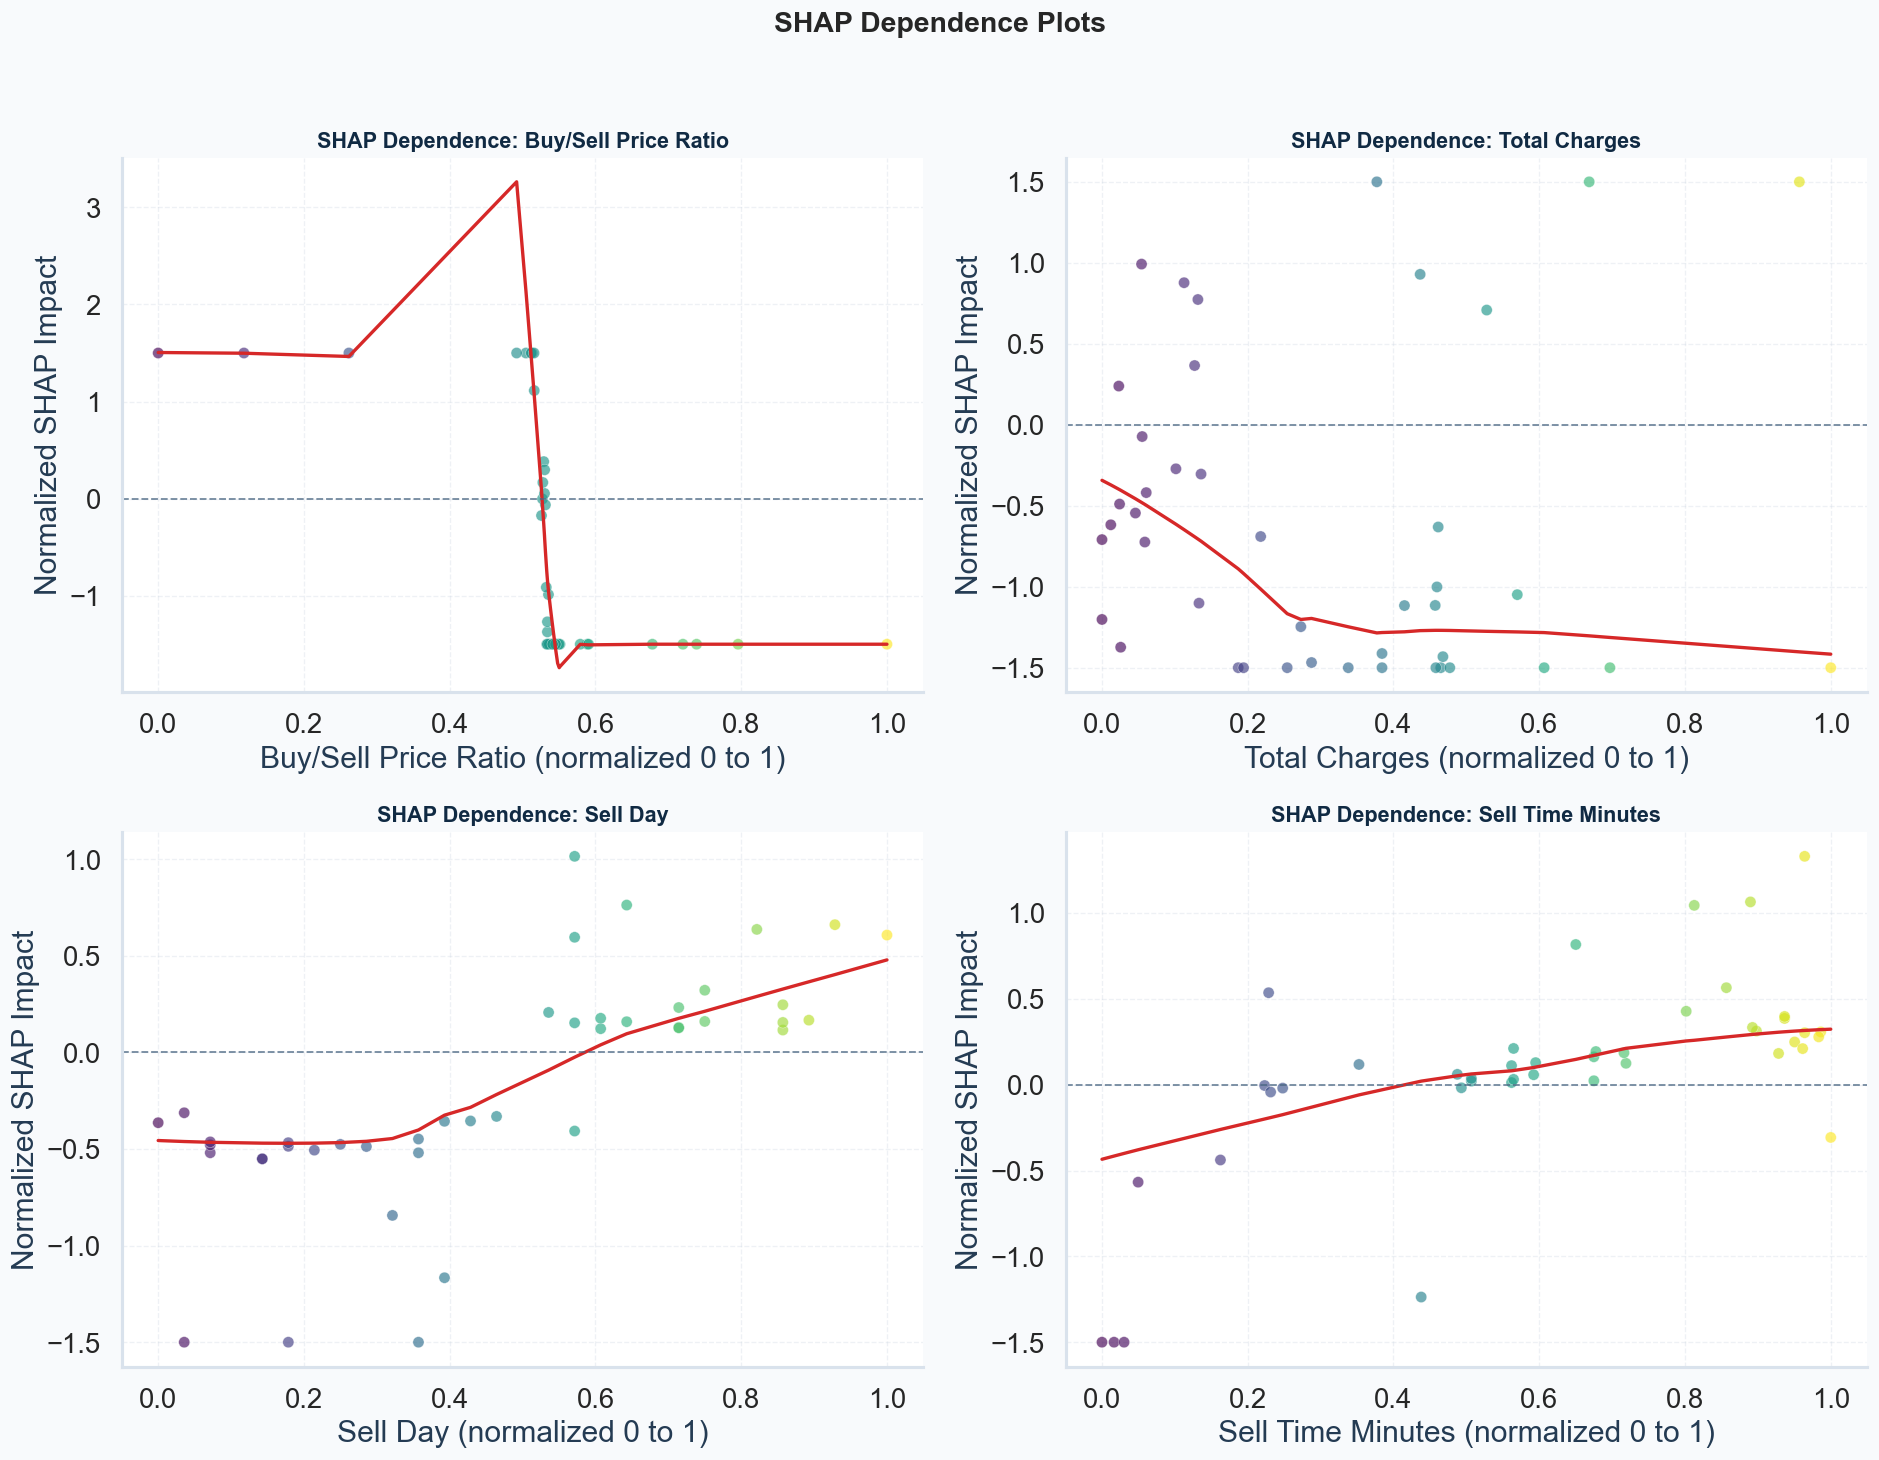

Saved plot: Figures\32_SHAP Prediction Breakdown.png


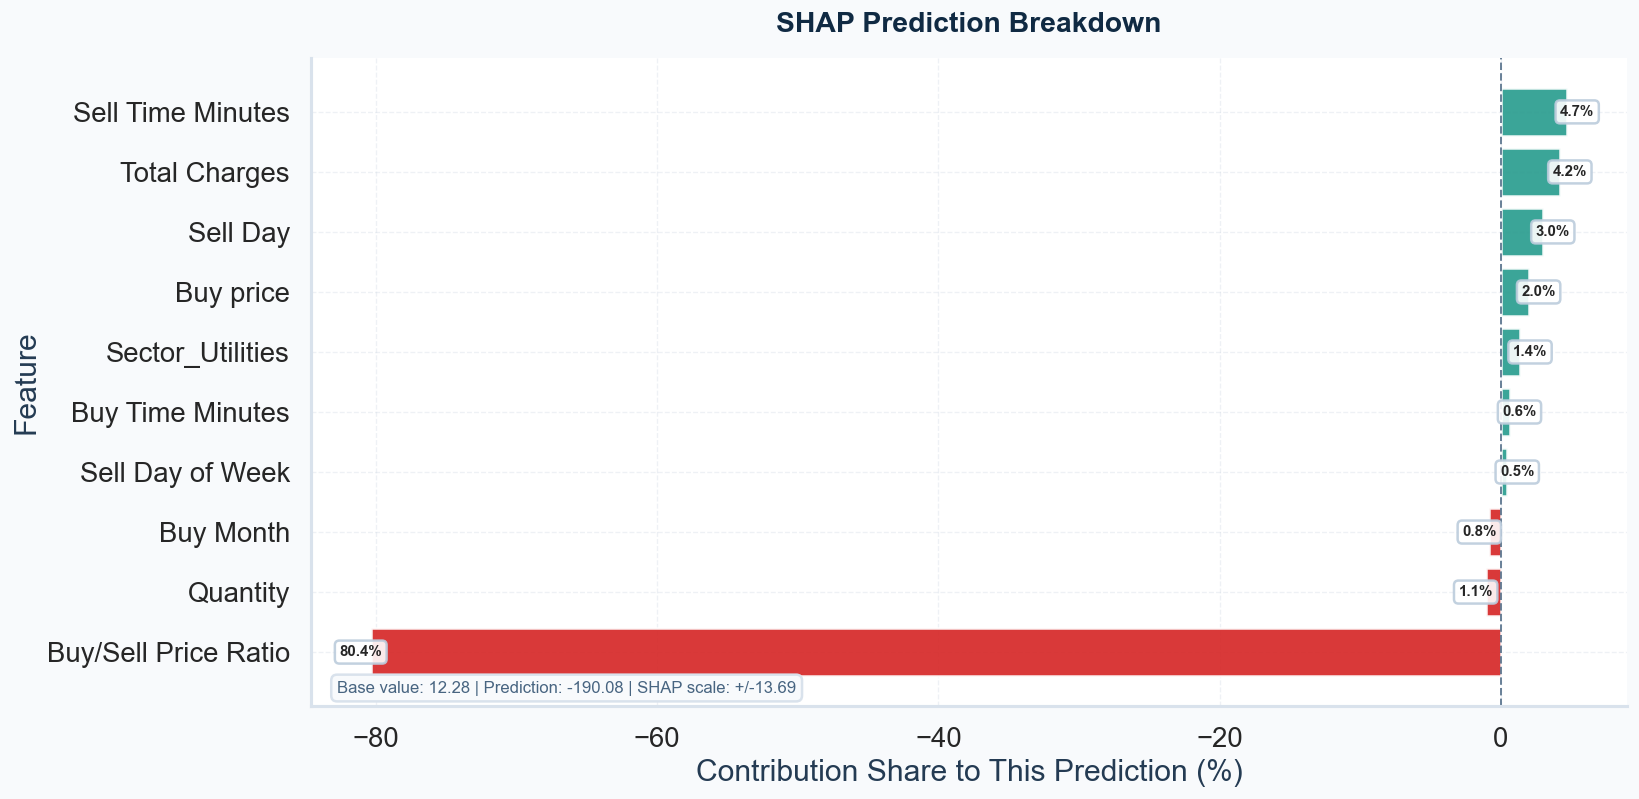

In [805]:
print(f"\n{'='*80}")
print("SHAP ANALYSIS")
print(f"{'='*80}")

if best_model_name in tree_models:
    explainer = shap.TreeExplainer(best_model)
    sample_size = min(100, len(X_test_trf))
    X_sample = X_test_trf.sample(n=sample_size, random_state=42)
    shap_values = explainer.shap_values(X_sample)
else:
    background = shap.sample(X_train_trf, 100)
    explainer = shap.KernelExplainer(best_model.predict, background)
    sample_size = min(50, len(X_test_trf))
    X_sample = X_test_trf.sample(n=sample_size, random_state=42)
    shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)
base_value = explainer.expected_value[0] if np.ndim(explainer.expected_value) else explainer.expected_value

shap_scale = np.percentile(np.abs(shap_values), 95)
if shap_scale == 0:
    shap_scale = 1.0
shap_values_norm = np.clip(shap_values / shap_scale, -1.5, 1.5)

X_sample_norm = X_sample.copy()
for col in X_sample_norm.columns:
    series = pd.to_numeric(X_sample_norm[col], errors='coerce')
    if series.notna().any():
        col_min = series.min()
        col_max = series.max()
        if pd.notna(col_min) and pd.notna(col_max) and col_max > col_min:
            X_sample_norm[col] = (series - col_min) / (col_max - col_min)
        else:
            X_sample_norm[col] = 0.5
    else:
        X_sample_norm[col] = 0.0
X_sample_norm = X_sample_norm.fillna(0.0)

shap_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0),
    'Mean |Normalized SHAP|': np.abs(shap_values_norm).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)
shap_importance['Contribution Share (%)'] = 100 * shap_importance['Mean |SHAP|'] / shap_importance['Mean |SHAP|'].sum()

print("\nTop 20 Features by SHAP Importance:")
print(shap_importance[['Feature', 'Mean |SHAP|', 'Contribution Share (%)']].head(20).to_string(index=False))

# 1. Clear normalized importance chart
plot_df = shap_importance.head(15).sort_values('Contribution Share (%)', ascending=True)
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(data=plot_df, x='Contribution Share (%)', y='Feature', hue='Feature', dodge=False,
            palette='mako', legend=False, ax=ax)
ax.set_title('SHAP Feature Importance', fontsize=17, fontweight='bold', pad=16)
ax.set_xlabel('Contribution Share (%)')
ax.set_ylabel('Feature')
polish_axes(ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9)
plt.tight_layout()
save_plot('SHAP Feature Importance', fig)
plt.show()

# 2. Normalized impact distribution
impact_features = shap_importance.head(12)['Feature'].tolist()
impact_frame = pd.DataFrame(shap_values_norm, columns=X_sample.columns)[impact_features]
impact_long = impact_frame.melt(var_name='Feature', value_name='Normalized SHAP Impact')
feature_order = shap_importance.head(12)['Feature'][::-1]
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=impact_long, x='Normalized SHAP Impact', y='Feature', order=feature_order,
            color='#9ecae1', linewidth=1.1, fliersize=0, ax=ax)
sns.stripplot(data=impact_long.sample(min(len(impact_long), 1200), random_state=42),
              x='Normalized SHAP Impact', y='Feature', order=feature_order,
              color='#1d3557', size=3, alpha=0.18, ax=ax)
ax.axvline(0, color='#d62828', linestyle='--', linewidth=1.3, alpha=0.85)
ax.set_title('SHAP Impact Distribution', fontsize=17, fontweight='bold', pad=16)
ax.set_xlabel('Normalized SHAP Impact (-1.5 to 1.5)')
ax.set_ylabel('Feature')
polish_axes(ax)
plt.tight_layout()
save_plot('SHAP Impact Distribution', fig)
plt.show()

# 3. Normalized dependence plots for top features
selected_features = shap_importance.head(4)['Feature'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(selected_features):
    feature_idx = list(X_sample.columns).index(feature)
    x_vals = X_sample_norm[feature].to_numpy()
    y_vals = shap_values_norm[:, feature_idx]
    axes[idx].scatter(x_vals, y_vals, c=x_vals, cmap='viridis', s=45, alpha=0.65, edgecolor='white', linewidth=0.3)
    sns.regplot(x=x_vals, y=y_vals, scatter=False, lowess=True, ax=axes[idx], color='#d62828', line_kws={'linewidth': 2})
    axes[idx].axhline(0, color='#486581', linestyle='--', linewidth=1.1, alpha=0.75)
    axes[idx].set_title(f'SHAP Dependence: {feature}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel(f'{feature} (normalized 0 to 1)')
    axes[idx].set_ylabel('Normalized SHAP Impact')
    polish_axes(axes[idx])

for j in range(len(selected_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('SHAP Dependence Plots', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('SHAP Dependence Plots', fig)
plt.show()

# 4. Clear single-prediction breakdown
sample_idx = 0
sample_shap = shap_values[sample_idx]
sample_abs = np.abs(sample_shap)
abs_total = sample_abs.sum() if sample_abs.sum() != 0 else 1.0
top_idx = np.argsort(sample_abs)[-10:][::-1]
sample_breakdown = pd.DataFrame({
    'Feature': X_sample.columns[top_idx],
    'Signed Contribution (%)': np.sign(sample_shap[top_idx]) * (sample_abs[top_idx] / abs_total * 100),
    'Absolute Contribution (%)': sample_abs[top_idx] / abs_total * 100
}).sort_values('Signed Contribution (%)')

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#d62828' if x < 0 else '#2a9d8f' for x in sample_breakdown['Signed Contribution (%)']]
ax.barh(sample_breakdown['Feature'], sample_breakdown['Signed Contribution (%)'],
        color=colors, alpha=0.92, edgecolor='white', linewidth=1.5)
ax.axvline(0, color='#486581', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_title('SHAP Prediction Breakdown', fontsize=17, fontweight='bold', pad=16)
ax.set_xlabel('Contribution Share to This Prediction (%)')
ax.set_ylabel('Feature')
polish_axes(ax)

for i, (_, row) in enumerate(sample_breakdown.iterrows()):
    offset = 0.7 if row['Signed Contribution (%)'] >= 0 else -0.7
    ax.text(
        row['Signed Contribution (%)'] + offset, i,
        f"{row['Absolute Contribution (%)']:.1f}%",
        va='center', ha='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bcccdc', alpha=0.9)
    )

prediction_value = base_value + sample_shap.sum()
ax.text(
    0.02, 0.02,
    f"Base value: {base_value:.2f} | Prediction: {prediction_value:.2f} | SHAP scale: +/-{shap_scale:.2f}",
    transform=ax.transAxes, fontsize=10, color='#486581',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#f8fafc', edgecolor='#d9e2ec')
)

plt.tight_layout()
save_plot('SHAP Prediction Breakdown', fig)
plt.show()


In [806]:
# Insights generator: plug this in and run after you have
# shap_importance (DataFrame), shap_values (shap.Explanation or np.array), X_sample (DataFrame)

def generate_detailed_insights(shap_importance, shap_values, X_sample, top_n=15):
   
    # Normalize shap_values to numeric array
    if hasattr(shap_values, "values"):
        shap_array = np.array(shap_values.values)
    else:
        shap_array = np.array(shap_values)
    # Safety checks
    assert shap_array.shape[1] == X_sample.shape[1], "Feature count mismatch between shap_values and X_sample"

    # Select top features
    top_df = shap_importance.head(top_n).reset_index(drop=True)

    sep = "=" * 80
    print(f"\n{sep}")
    print("📊 WHAT THE MODEL ACTUALLY LEARNED (IN PLAIN ENGLISH)")
    print(sep + "\n")

    print("🔍 ANALYZING YOUR TRADING PATTERNS...\n")

    def safe_corr(a, b):
        try:
            if np.std(a) == 0 or np.std(b) == 0:
                return 0.0
            c = np.corrcoef(a, b)[0, 1]
            if np.isnan(c):
                return 0.0
            return float(c)
        except Exception:
            return 0.0

    def clean_name(name):
        # make feature display name human friendly
        s = name
        s = s.replace("ohe_", "").replace("oe_", "")
        s = s.replace("_", " ").replace(".", " ").strip()
        return s

    for rank, row in top_df.iterrows():
        feature = row['Feature']
        impact = row['Mean |SHAP|']
        try:
            feat_idx = list(X_sample.columns).index(feature)
        except ValueError:
            # fallback attempt: match by cleaned name
            matches = [i for i, c in enumerate(X_sample.columns) if feature.lower() in c.lower()]
            feat_idx = matches[0] if matches else None

        if feat_idx is None:
            continue

        feature_shap = shap_array[:, feat_idx]
        feature_values = X_sample.iloc[:, feat_idx].values

        avg_pos = feature_shap[feature_shap > 0].mean() if (feature_shap > 0).any() else 0.0
        avg_neg = feature_shap[feature_shap < 0].mean() if (feature_shap < 0).any() else 0.0
        corr = safe_corr(feature_values.astype(float, copy=False), feature_shap)

        display_name = clean_name(feature)
        print(f"{rank+1}. {display_name.upper()} (impact score: {impact:.4f})")

        # Core interpretation rules (prioritized)
        lname = display_name.lower()

        # PnL and trade-value related features
        if 'pnl' in lname or 'per trade value' in lname or 'trade value' in lname:
            print(textwrap.indent(
                "• What this means: This feature measures profit scaled to trade size. "
                "High importance here means your returns are strongly tied to how much capital you risk per trade.",
                '   '))
            print(textwrap.indent(f"• Typical effect: Avg positive contribution = ₹{avg_pos:.2f}, avg negative = ₹{abs(avg_neg):.2f}", '   '))
            print(textwrap.indent("• Suggested action: normalize position sizing, compute expected P&L per unit exposure, and avoid very small-profit setups where charges eat gains.", '   '))

        # Time features (Buy/Sell/Hour/Interval)
        elif any(k in lname for k in ['buy time', 'sell time', 'buy hour', 'sell hour', 'interval', 'hour']):
            which = "ENTRY (buy)" if 'buy' in lname else ("EXIT (sell)" if 'sell' in lname else "TIME")
            print(textwrap.indent(f"• What this means: {which} timing influences outcomes. SHAP shows timing changes push predictions up/down.", '   '))
            print(textwrap.indent(f"• Correlation with SHAP: {corr:.3f}", '   '))
            if corr > 0.12:
                print(textwrap.indent("• Pattern: Later times tend to increase expected P&L for these trades. You might be better at letting the market settle before entering/exiting.", '   '))
                print(textwrap.indent("• Action: Shift more entries/exits into the later time buckets where your historical edge exists.", '   '))
            elif corr < -0.12:
                print(textwrap.indent("• Pattern: Earlier times correlate with higher expected P&L — your edge is in the open/first-hour moves.", '   '))
                print(textwrap.indent("• Action: Prioritize first-hour setups and reduce trades in low-edge hours.", '   '))
            else:
                print(textwrap.indent("• Pattern: Mixed effect — timing matters in combination with other features (e.g., sector, charges).", '   '))
                print(textwrap.indent("• Action: Use a rule: only trade at these times if other conditions (sector, charges) are favorable.", '   '))

        # Holding period
        elif 'holding' in lname or 'hold' in lname:
            print(textwrap.indent("• What this means: How long you keep a position changes profit expectation.", '   '))
            print(textwrap.indent(f"• Correlation with SHAP: {corr:.3f}", '   '))
            if corr > 0.18:
                print(textwrap.indent("• Pattern: Longer holds = better profits. You currently cut winners too early.", '   '))
                print(textwrap.indent("• Action: Consider trailing stops and give winning trades more runway.", '   '))
            elif corr < -0.18:
                print(textwrap.indent("• Pattern: Short/quick exits = better profits. You are effectively a scalper.", '   '))
                print(textwrap.indent("• Action: Avoid overnight or multi-day holds unless the edge is strong.", '   '))
            else:
                print(textwrap.indent("• Pattern: No single holding duration dominates — success depends on trade context.", '   '))

        # Charges related
        elif any(k in lname for k in ['charge', 'brokerage', 'stt', 'gst', 'total charges', 'stamp duty', 'demat']):
            print(textwrap.indent("• What this means: Transaction costs are directly reducing your Net P&L.", '   '))
            print(textwrap.indent(f"• Typical drag: avg negative SHAP contribution = ₹{abs(avg_neg):.2f}", '   '))
            print(textwrap.indent("• Pattern: Even otherwise profitable trades often flip to losses after charges.", '   '))
            print(textwrap.indent("• Action: (1) Reduce trade frequency, (2) increase per-trade target to justify cost, (3) consider a lower-cost broker for scalping.", '   '))

        # Price-related
        elif any(k in lname for k in ['buy price', 'sell price', 'price ratio', 'buy/sell price', 'price']):
            print(textwrap.indent("• What this means: Entry/exit price levels strongly affect realized return.", '   '))
            if 'buy' in lname:
                if corr < -0.12:
                    print(textwrap.indent("• Pattern: Lower buy price (buying dips) yields better returns.", '   '))
                    print(textwrap.indent("• Action: Focus on confirmed support zones and use limit entries.", '   '))
                elif corr > 0.12:
                    print(textwrap.indent("• Pattern: Higher buy prices (momentum entries) work better for you.", '   '))
                    print(textwrap.indent("• Action: Use breakout confirmation rules; avoid buying weak pullbacks.", '   '))
                else:
                    print(textwrap.indent("• Pattern: Mixed — combine price signals with momentum/volume filters.", '   '))
            else:
                print(textwrap.indent("• Exit price quality strongly determines P&L — good exits = bigger realized profits.", '   '))
                print(textwrap.indent("• Action: Improve exit rules (targets + trailing stops) and avoid emotional exits.", '   '))

        # Sector / Industry
        elif 'sector' in lname or 'industry' in lname:
            pretty = display_name.replace('sector', '').replace('industry', '').strip()
            print(textwrap.indent(f"• What this means: This categorical feature measures sector/industry-specific performance.", '   '))
            print(textwrap.indent(f"• Avg contribution when positive = ₹{avg_pos:.2f}; when negative = ₹{abs(avg_neg):.2f}", '   '))
            if abs(avg_pos) > abs(avg_neg):
                print(textwrap.indent(f"• Pattern: {pretty} tends to be profitable for you historically.", '   '))
                print(textwrap.indent("• Action: Consider increasing exposure or allocating a focused watchlist for this sector.", '   '))
            else:
                print(textwrap.indent(f"• Pattern: {pretty} underperforms — it often reduces your Net P&L.", '   '))
                print(textwrap.indent("• Action: Reduce position size or avoid this sector unless setup quality is exceptional.", '   '))

        # Quantity
        elif 'quantity' in lname or 'position size' in lname:
            print(textwrap.indent("• What this means: Position size amplifies both profit and loss.", '   '))
            print(textwrap.indent(f"• Correlation with SHAP: {corr:.3f}", '   '))
            if corr > 0.08:
                print(textwrap.indent("• Pattern: Larger sizes historically correlated with better returns — you size up when confident.", '   '))
                print(textwrap.indent("• Action: Keep a disciplined sizing rule (e.g., % of equity or volatility-based sizing).", '   '))
            else:
                print(textwrap.indent("• Pattern: Larger sizes amplify mistakes and often lead to worse outcomes.", '   '))
                print(textwrap.indent("• Action: Cap max position size and scale into positions instead of going all-in.", '   '))

        # Day of week / other
        elif 'day' in lname or 'weekday' in lname:
            print(textwrap.indent("• What this means: The day of week correlates with your edge (emotional cycles, news cadence).", '   '))
            print(textwrap.indent(f"• Avg positive contribution = ₹{avg_pos:.2f}; avg negative = ₹{abs(avg_neg):.2f}", '   '))
            print(textwrap.indent("• Action: Track day-wise P&L and avoid low-edge days.", '   '))

        else:
            # Generic fallback
            print(textwrap.indent("• What this means: This feature significantly influences predicted P&L in your history.", '   '))
            print(textwrap.indent(f"• Avg positive contribution = ₹{avg_pos:.2f}; avg negative = ₹{abs(avg_neg):.2f}", '   '))
            print(textwrap.indent("• Action: Investigate this feature in combination with others to form rules (e.g., time + sector + charges).", '   '))

        print()  # blank line between features

    # -------------------------
    # Aggregated actionable insights
    # -------------------------
    print(sep)
    print("🎯 FINAL ACTIONABLE INSIGHTS (PRIORITIZED)")
    print(sep + "\n")

    insights = []

    # Charges summary
    charges_keys = [f for f in shap_importance['Feature'] if any(k in f.lower() for k in ['charge', 'brokerage', 'stt', 'gst', 'total charges', 'stamp', 'demat'])]
    if charges_keys:
        ch_imp = shap_importance[shap_importance['Feature'].isin(charges_keys)]['Mean |SHAP|'].sum()
        if ch_imp > 0.8 * shap_importance['Mean |SHAP|'].sum() * 0.15:  # heuristic
            insights.append(("Costs are a major drag", [
                "Your average realized profit is being reduced materially by transaction costs.",
                "Prioritize trades where expected gross P&L >> total charges (target net margin).",
                "For scalping, charges must be < X% of expected edge — otherwise skip.",
                "Consider a lower-cost broker or reduce trade frequency."
            ]))

    # Timing summary (use first buy-time-like column if exists)
    buy_time_cols = [c for c in X_sample.columns if 'buy' in c.lower() and ('time' in c.lower() or 'hour' in c.lower() or 'interval' in c.lower())]
    if buy_time_cols:
        idx = X_sample.columns.tolist().index(buy_time_cols[0])
        time_vals = X_sample.iloc[:, idx].values
        time_shap = shap_array[:, idx]
        early_mask = time_vals <= np.percentile(time_vals, 33)
        late_mask = time_vals >= np.percentile(time_vals, 67)
        early_avg = time_shap[early_mask].mean() if early_mask.any() else 0
        late_avg = time_shap[late_mask].mean() if late_mask.any() else 0
        if early_avg > late_avg + abs(early_avg)*0.2:
            insights.append(("Morning edge", [
                "You perform best in the morning window.",
                "Allocate more capital and focus to the first 60–90 minutes of trading.",
                "Avoid late-day trades unless other conditions are ideal."
            ]))
        elif late_avg > early_avg + abs(late_avg)*0.2:
            insights.append(("Afternoon edge", [
                "You perform better later in the session — market settlement benefits you.",
                "Consider filters that reduce early volatility exposure.",
                "Schedule watchlists for setups after 11:00 AM."
            ]))

    # Holding period summary
    hold_cols = [c for c in X_sample.columns if 'holding' in c.lower() or 'hold' in c.lower()]
    if hold_cols:
        idx = X_sample.columns.tolist().index(hold_cols[0])
        hp_corr = safe_corr(X_sample.iloc[:, idx].values.astype(float), shap_array[:, idx])
        if hp_corr > 0.18:
            insights.append(("Be more patient with winners", [
                "Longer holds tend to increase profits — you're likely cutting winners early.",
                "Use trailing stops that scale out over time rather than fixed tight targets.",
                "Backtest a 2x–3x holding horizon to see improvement in realized gains."
            ]))
        elif hp_corr < -0.18:
            insights.append(("Shorter holds suit you", [
                "You are better at short-term scalps; long holds reduce performance.",
                "Avoid overnight positions and favor intraday strategies.",
                "Keep targets tight and exits mechanical."
            ]))

    # Sector summary
    sector_feats = [f for f in shap_importance['Feature'] if 'sector' in f.lower() or 'industry' in f.lower()]
    if sector_feats:
        pos = []
        neg = []
        for f in sector_feats:
            try:
                i = list(X_sample.columns).index(f)
            except ValueError:
                continue
            shp = shap_array[:, i]
            if np.nanmean(shp[shp>0]) > abs(np.nanmean(shp[shp<0])):
                pos.append(f)
            else:
                neg.append(f)
        if neg:
            insights.append(("Sector caution", [
                f"Some sectors (e.g., {', '.join([clean_name(x) for x in neg[:3]])}) have negative historic impact.",
                "Limit exposure or require stricter entry rules in these sectors.",
                "Build sector-specific rules or skip these sectors unless the setup is exceptionally strong."
            ]))
        if pos:
            insights.append(("Sector opportunity", [
                f"Some sectors (e.g., {', '.join([clean_name(x) for x in pos[:3]])}) have historically helped your returns.",
                "Create a watchlist focused on these sectors and optimize position sizing around them."
            ]))

    # Quantity / sizing
    qty_cols = [c for c in X_sample.columns if 'quantity' in c.lower() or 'position' in c.lower() or 'size' in c.lower()]
    if qty_cols:
        idx = list(X_sample.columns).index(qty_cols[0])
        corr_qty = safe_corr(X_sample.iloc[:, idx].values.astype(float), shap_array[:, idx])
        if corr_qty < -0.1:
            insights.append(("Size discipline needed", [
                "Larger sizes amplify losses — enforce max position size limits.",
                "Use volatility-adjusted sizing or fixed percent risk per trade."
            ]))
        else:
            insights.append(("Sizing works", [
                "Your sizing tends to correlate with higher returns — continue disciplined scaling."
            ]))

    # Print prioritized insights
    if insights:
        for title, bullets in insights:
            print(f"🔸 {title.upper()}")
            for b in bullets:
                print("   -", b)
            print()
    else:
        print("📊 Model shows mixed patterns — no single high-confidence recommendation. Consider collecting more data and re-evaluating after fresh trades.\n")

    print(sep)
    print("✅ ANALYSIS COMPLETE — these are concrete, prioritized actions you can apply today.")
    print(sep + "\n")

    # Return structured insights for programmatic use if needed
    structured = {
        "top_features": top_df,
        "aggregated_insights": insights
    }
    return structured

# Example usage:
structured_out = generate_detailed_insights(shap_importance, shap_values, X_sample, top_n=15)


📊 WHAT THE MODEL ACTUALLY LEARNED (IN PLAIN ENGLISH)

🔍 ANALYZING YOUR TRADING PATTERNS...

1. BUY/SELL PRICE RATIO (impact score: 120.7075)
   • What this means: Entry/exit price levels strongly affect realized return.
   • Pattern: Lower buy price (buying dips) yields better returns.
   • Action: Focus on confirmed support zones and use limit entries.

2. TOTAL CHARGES (impact score: 25.6163)
   • What this means: Transaction costs are directly reducing your Net P&L.
   • Typical drag: avg negative SHAP contribution = ₹26.27
   • Pattern: Even otherwise profitable trades often flip to losses after charges.
   • Action: (1) Reduce trade frequency, (2) increase per-trade target to justify cost, (3) consider a lower-cost broker for scalping.

3. SELL DAY (impact score: 8.2570)
   • What this means: The day of week correlates with your edge (emotional cycles, news cadence).
   • Avg positive contribution = ₹4.62; avg negative = ₹11.42
   • Action: Track day-wise P&L and avoid low-edge d

C:\Users\kejri\AppData\Local\Temp\ipykernel_23256\1030001837.py:238: RuntimeWarning: Mean of empty slice
  if np.nanmean(shp[shp>0]) > abs(np.nanmean(shp[shp<0])):


In [807]:
joblib.dump(best_model, f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl')
joblib.dump(ct, 'column_transformer.pkl')

print(f"\n{'='*80}")
print("MODEL DEPLOYMENT READY")
print(f"{'='*80}")
print(f"Best Model: {best_model_name}")
print(f"R² Score: {best_r2:.4f}")
print(f"Files Saved:")
print(f"  - best_model_{best_model_name.replace(' ', '_').lower()}.pkl")
print(f"  - column_transformer.pkl")
print(f"{'='*80}")


MODEL DEPLOYMENT READY
Best Model: Gradient Boosting
R² Score: 0.9606
Files Saved:
  - best_model_gradient_boosting.pkl
  - column_transformer.pkl
